In [1]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-03-09/"
slurm_job = 16267679

result_dir = result_dir + date + str(slurm_job) + "/"
# result_dir = result_dir + date + "v/"

batches = [2, 3, 6, 7, 9, 10, 12, 15]

In [2]:
# start at line number 1
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    # If file exists but doesn't have that many lines
    return []

# Part 2 - Without Delay, small variation 

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_35473/1341244421.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_35473/1341244421.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_35473/1341244421.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(16,10))


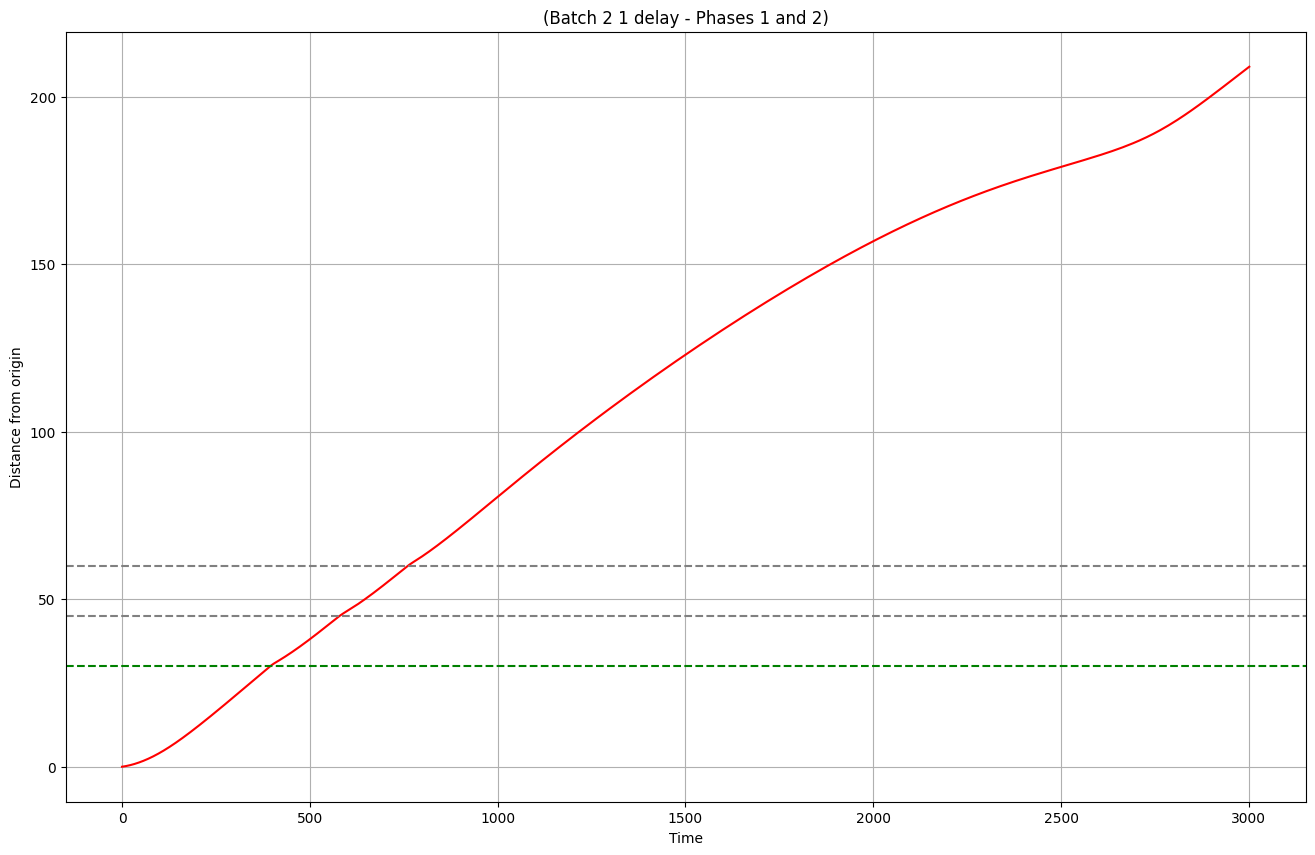

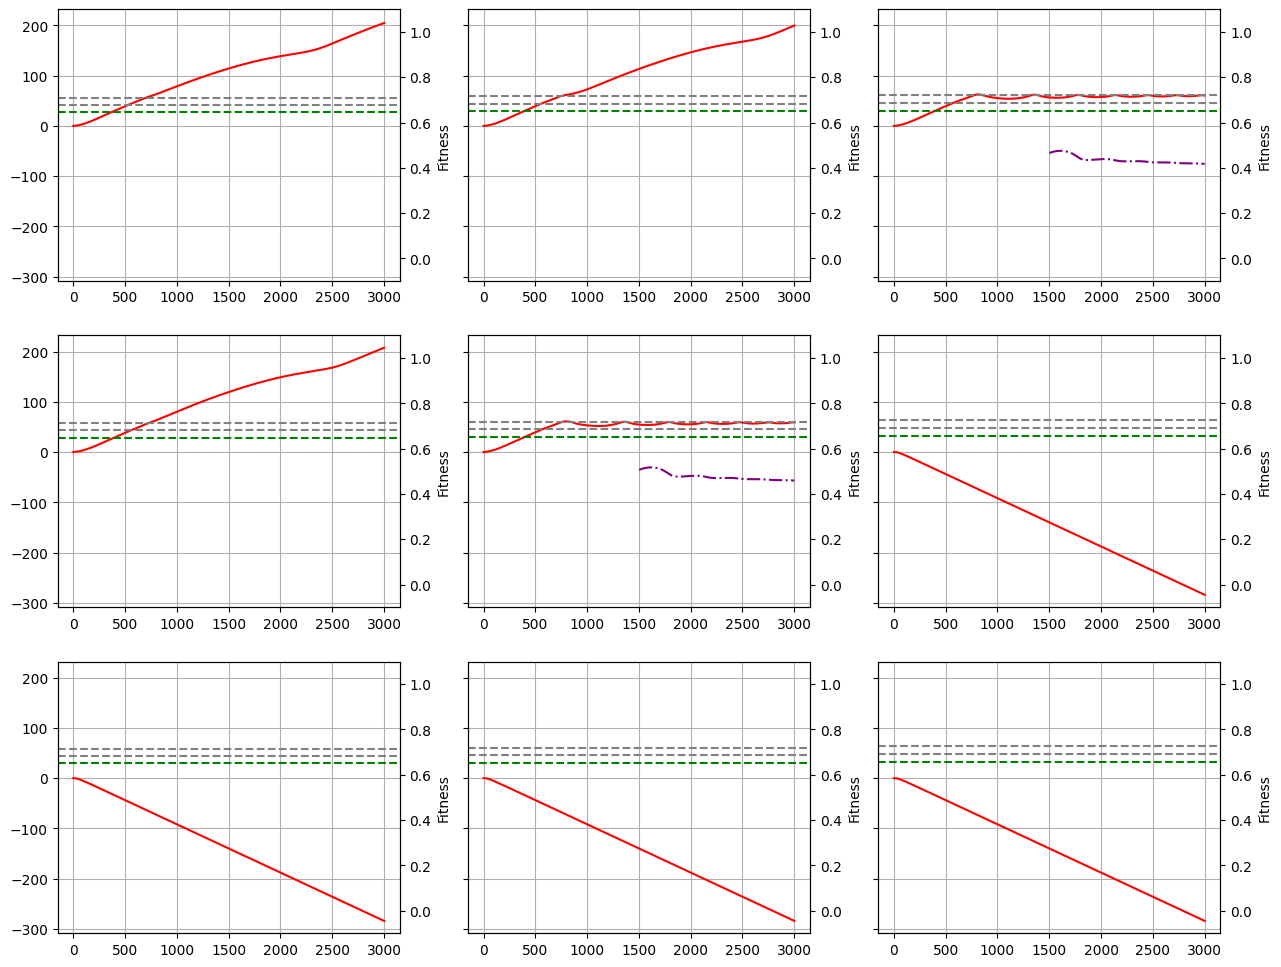

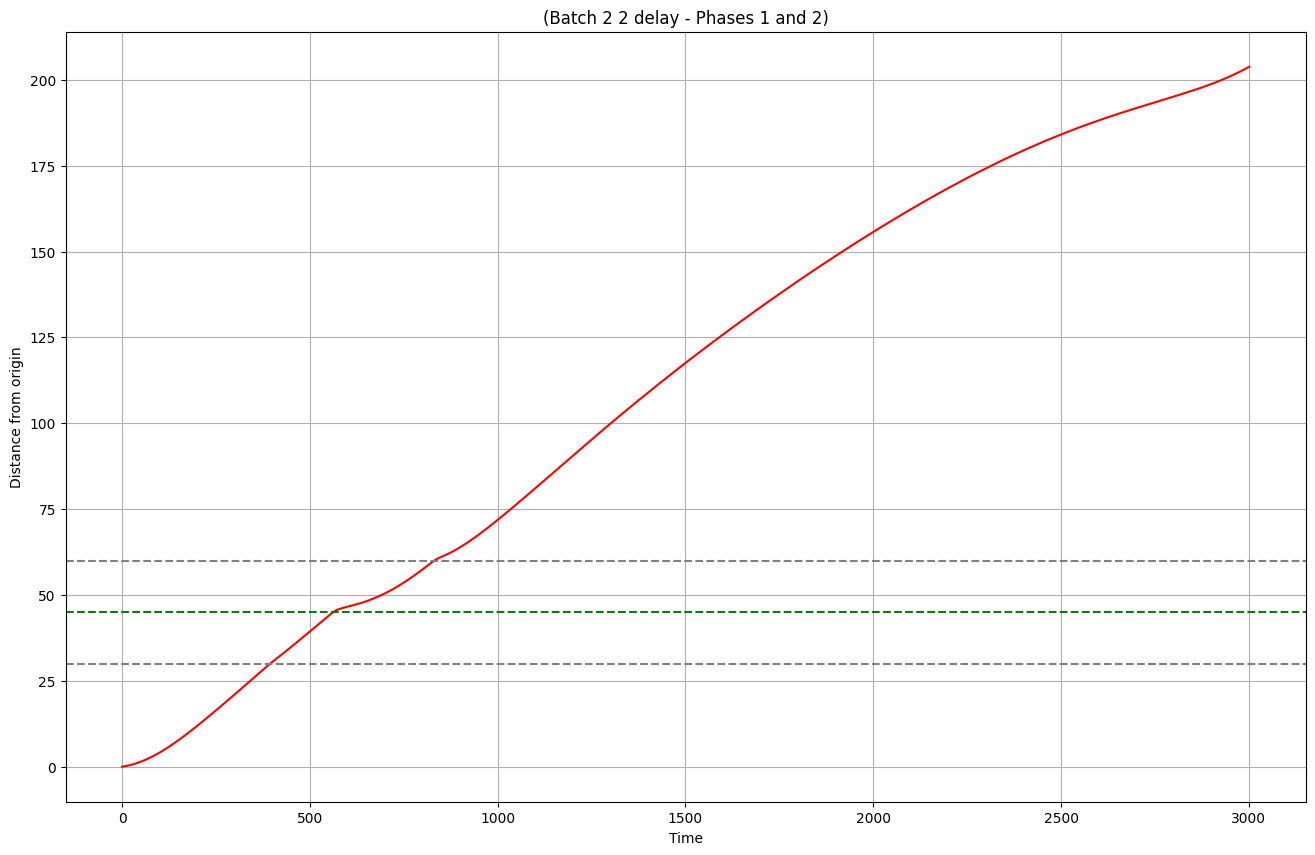

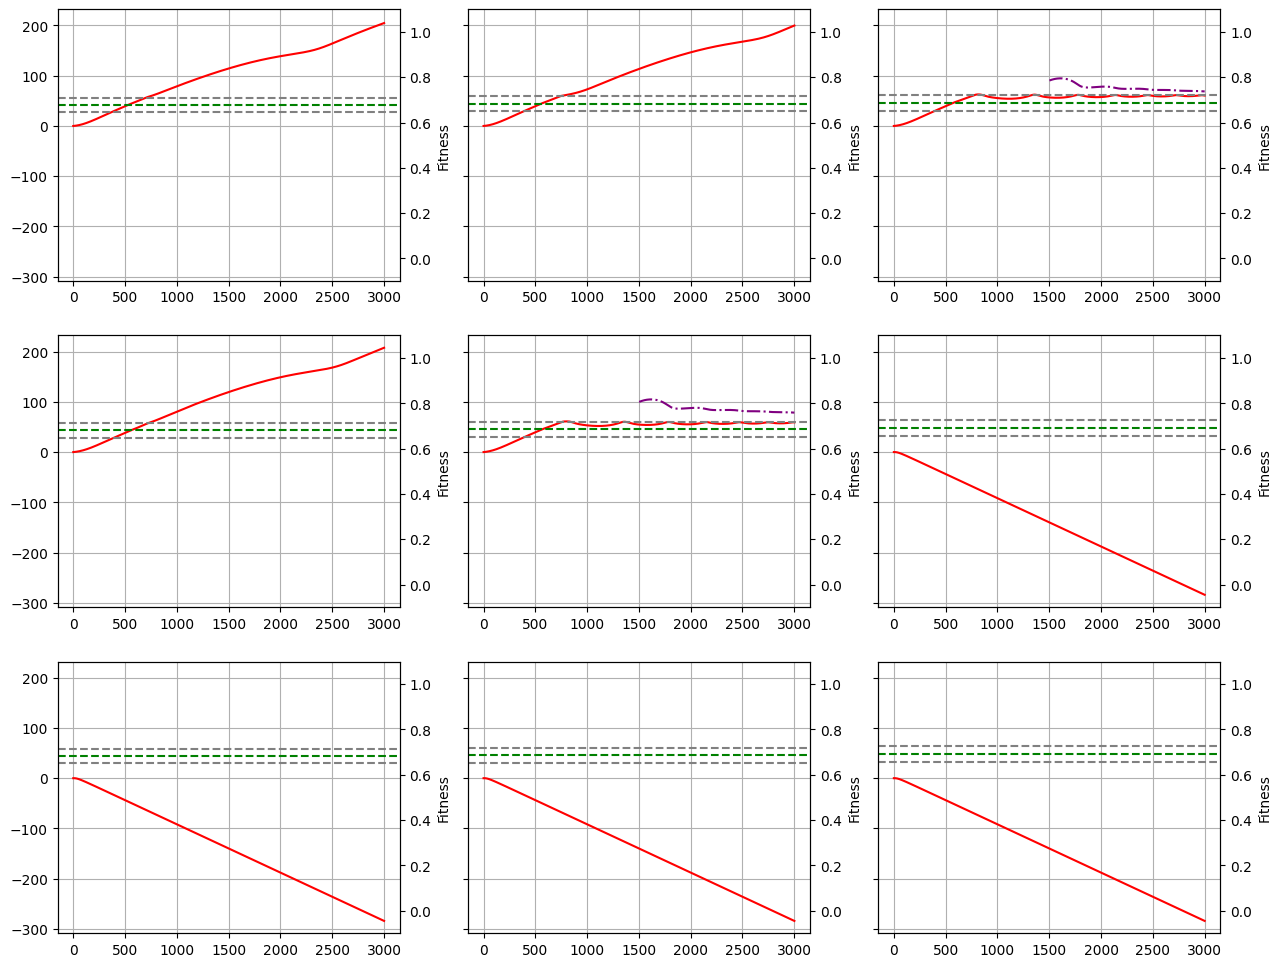

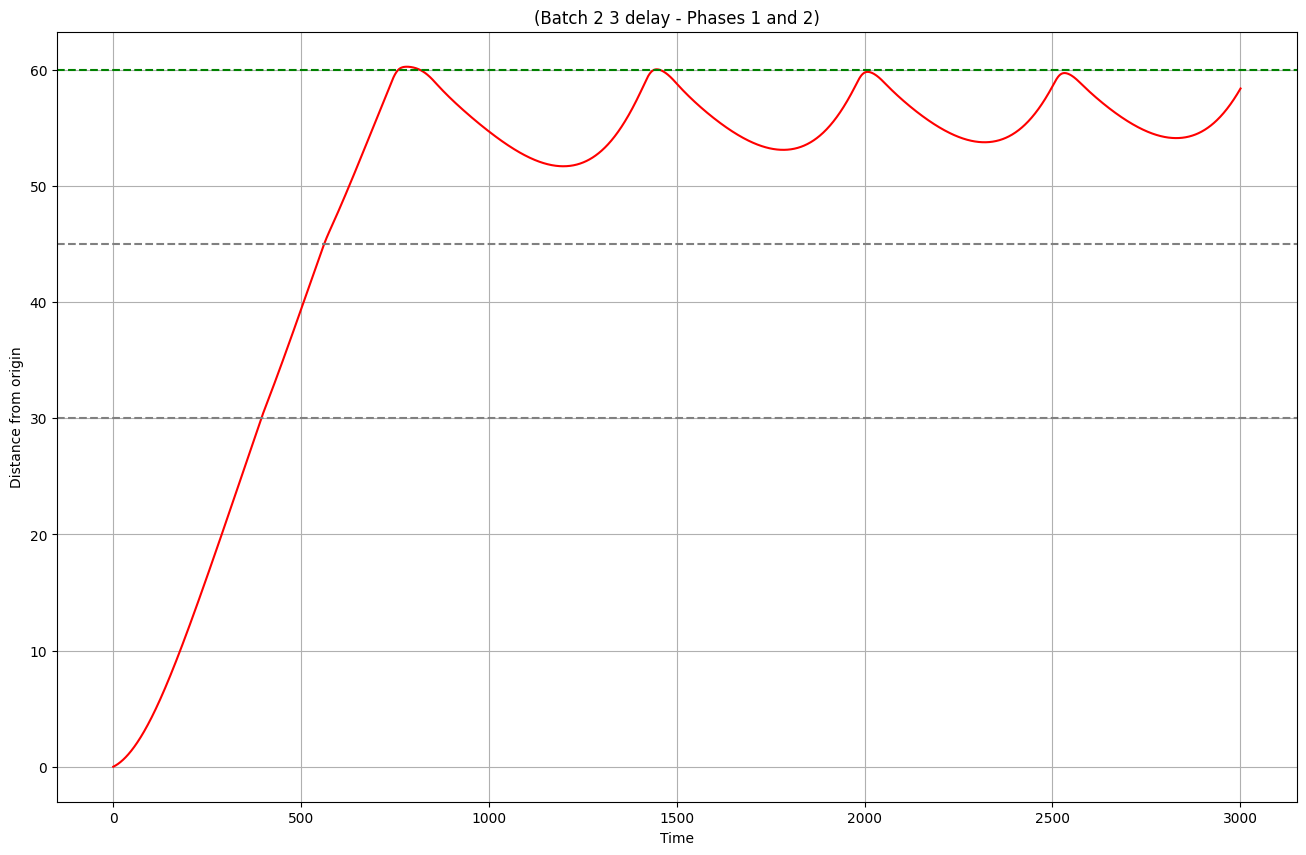

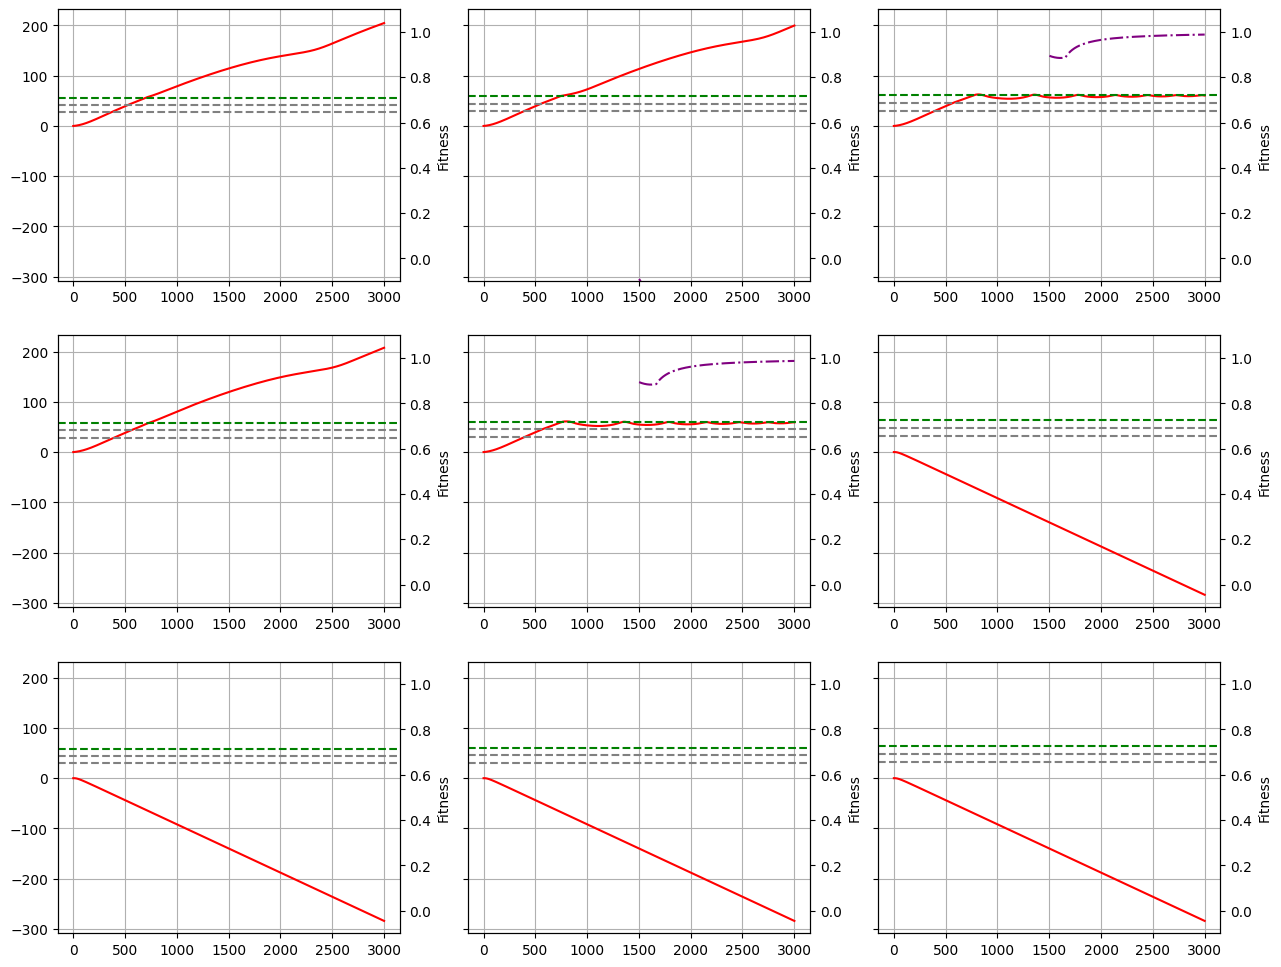

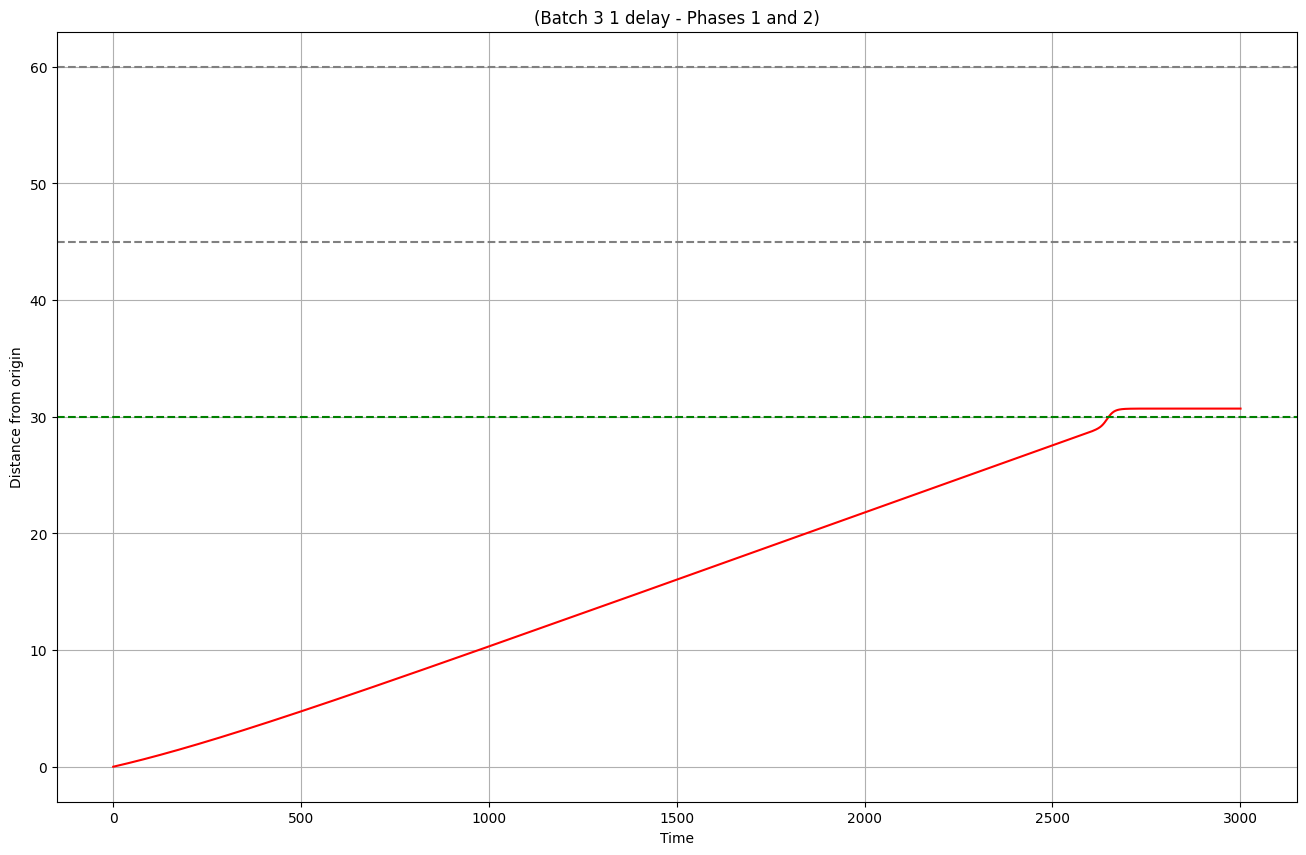

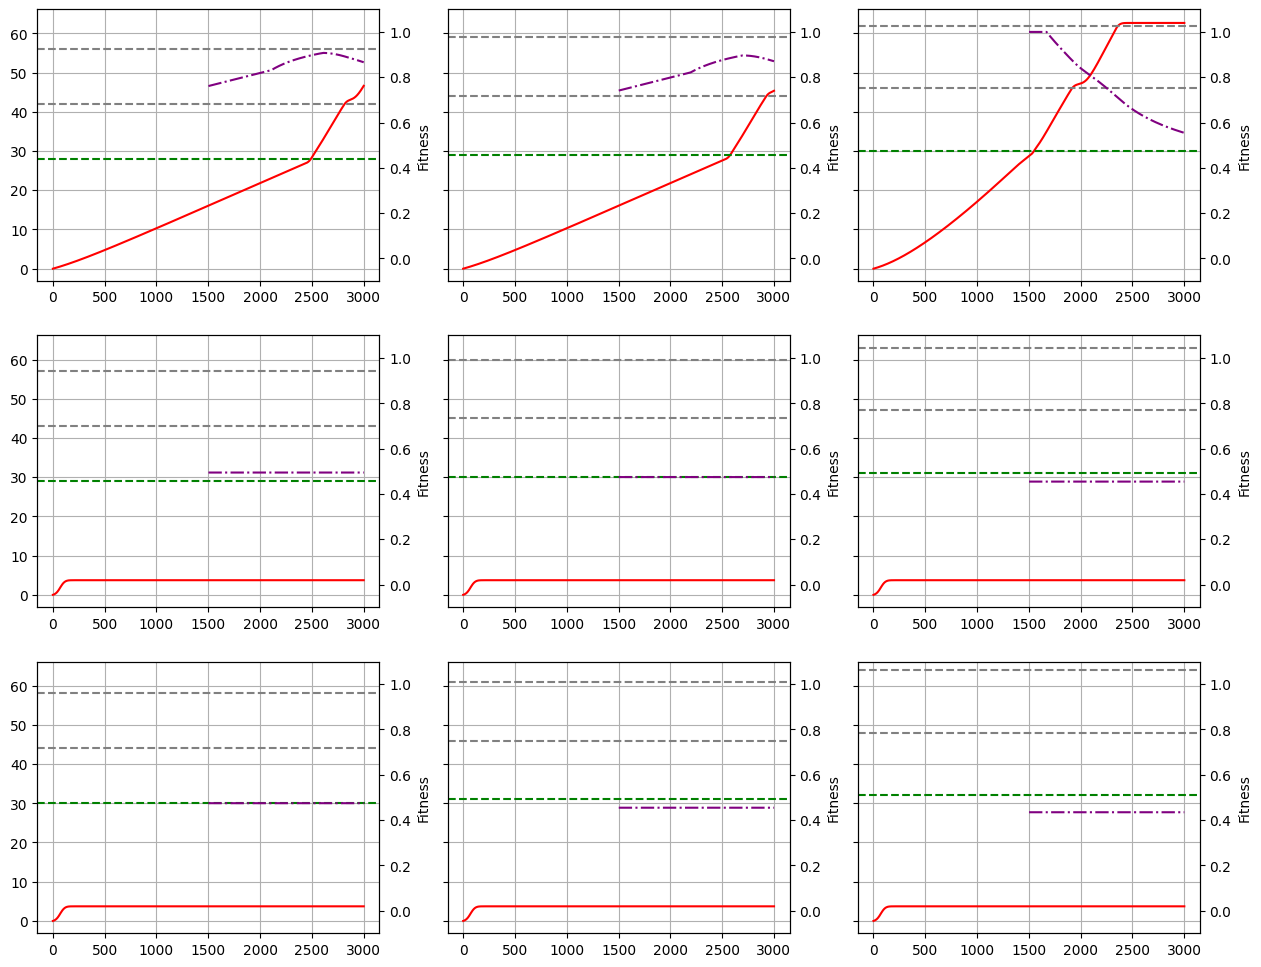

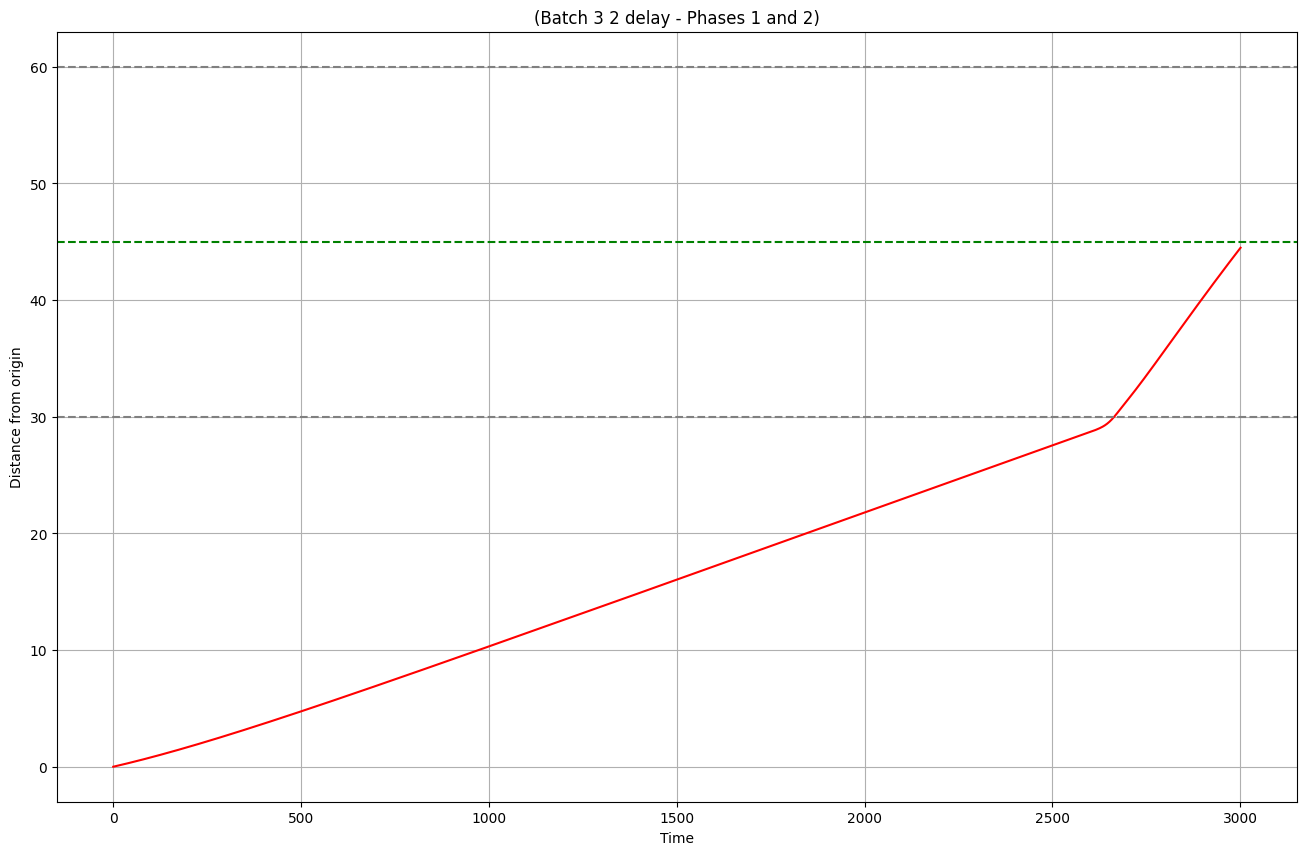

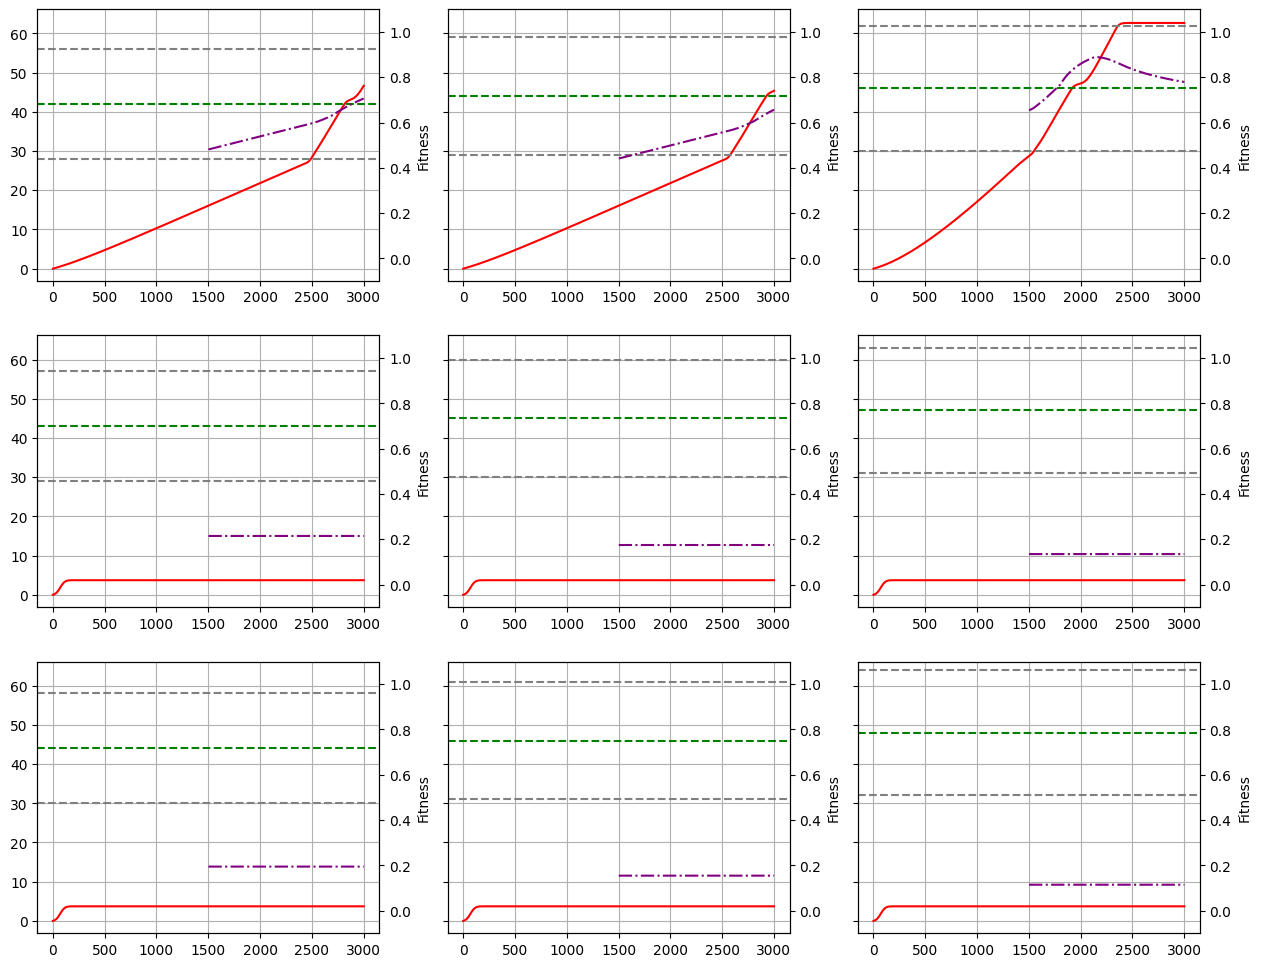

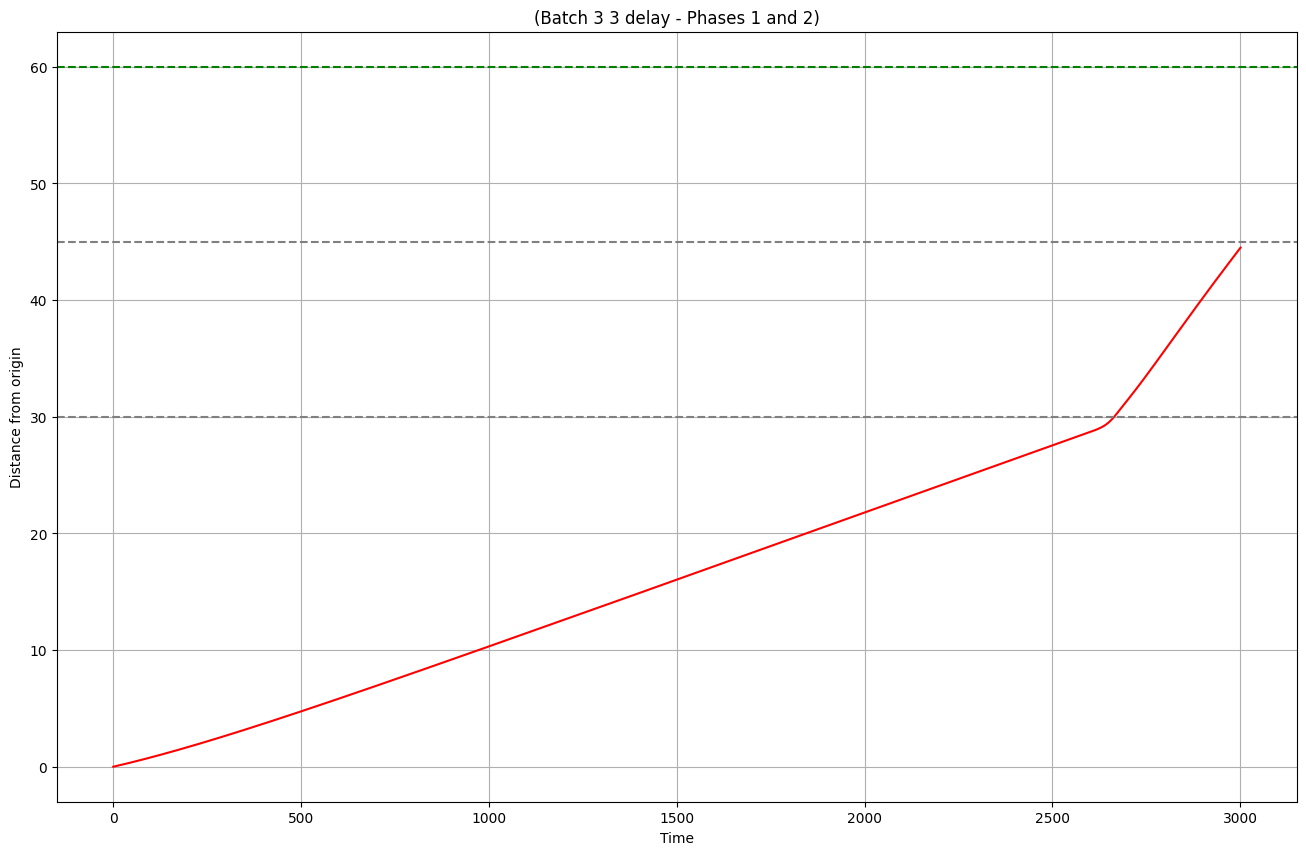

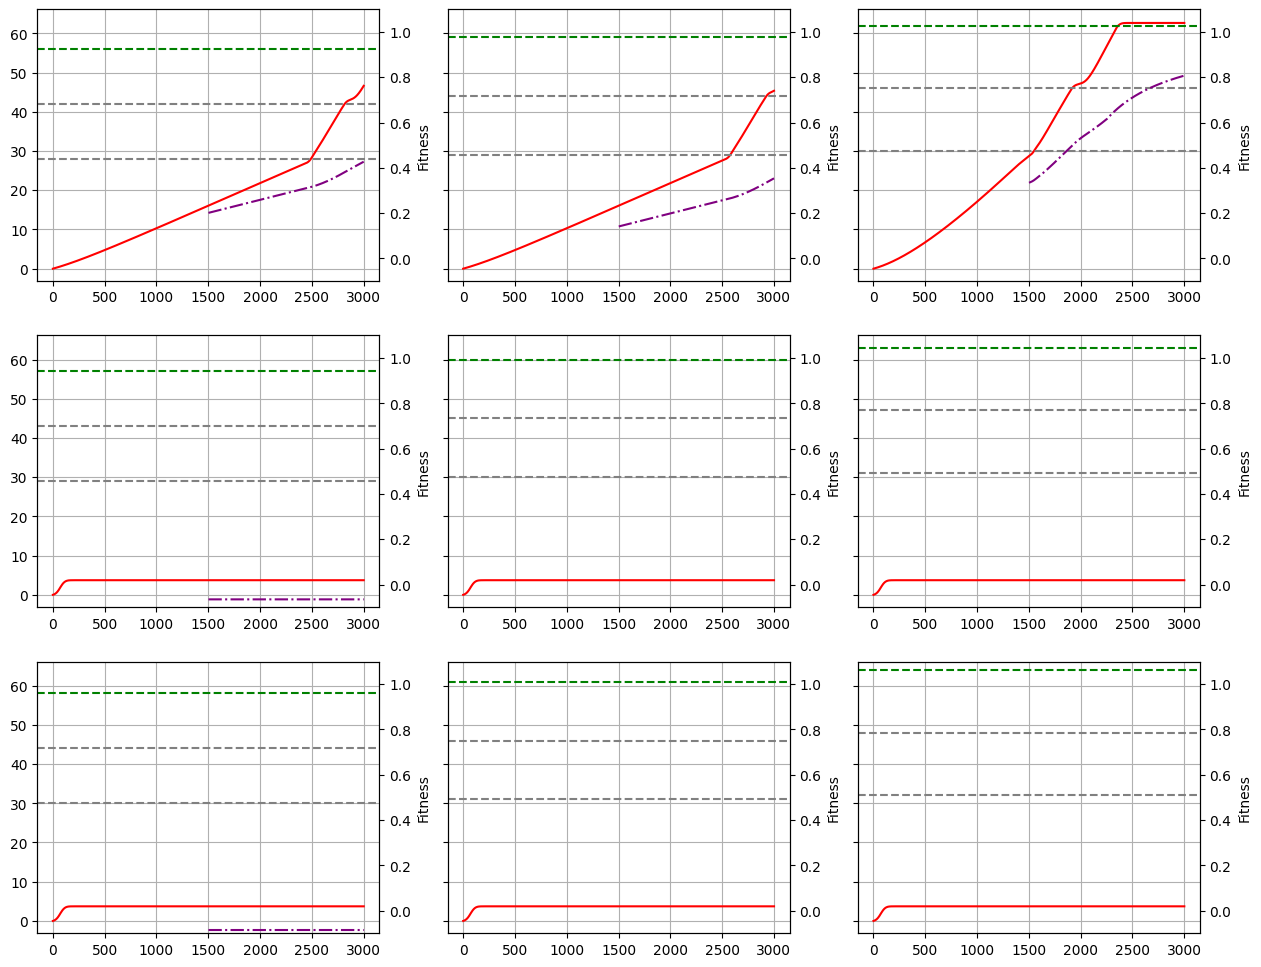

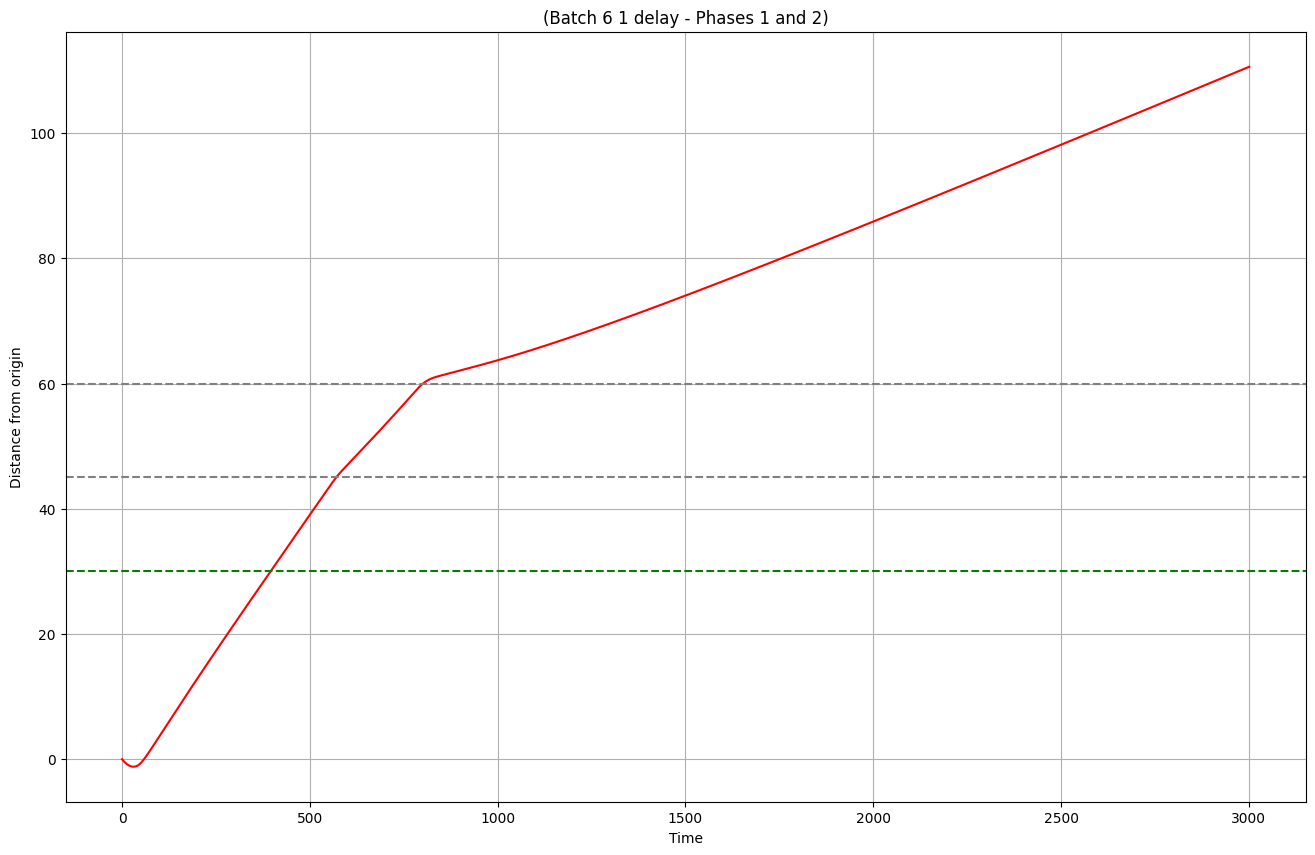

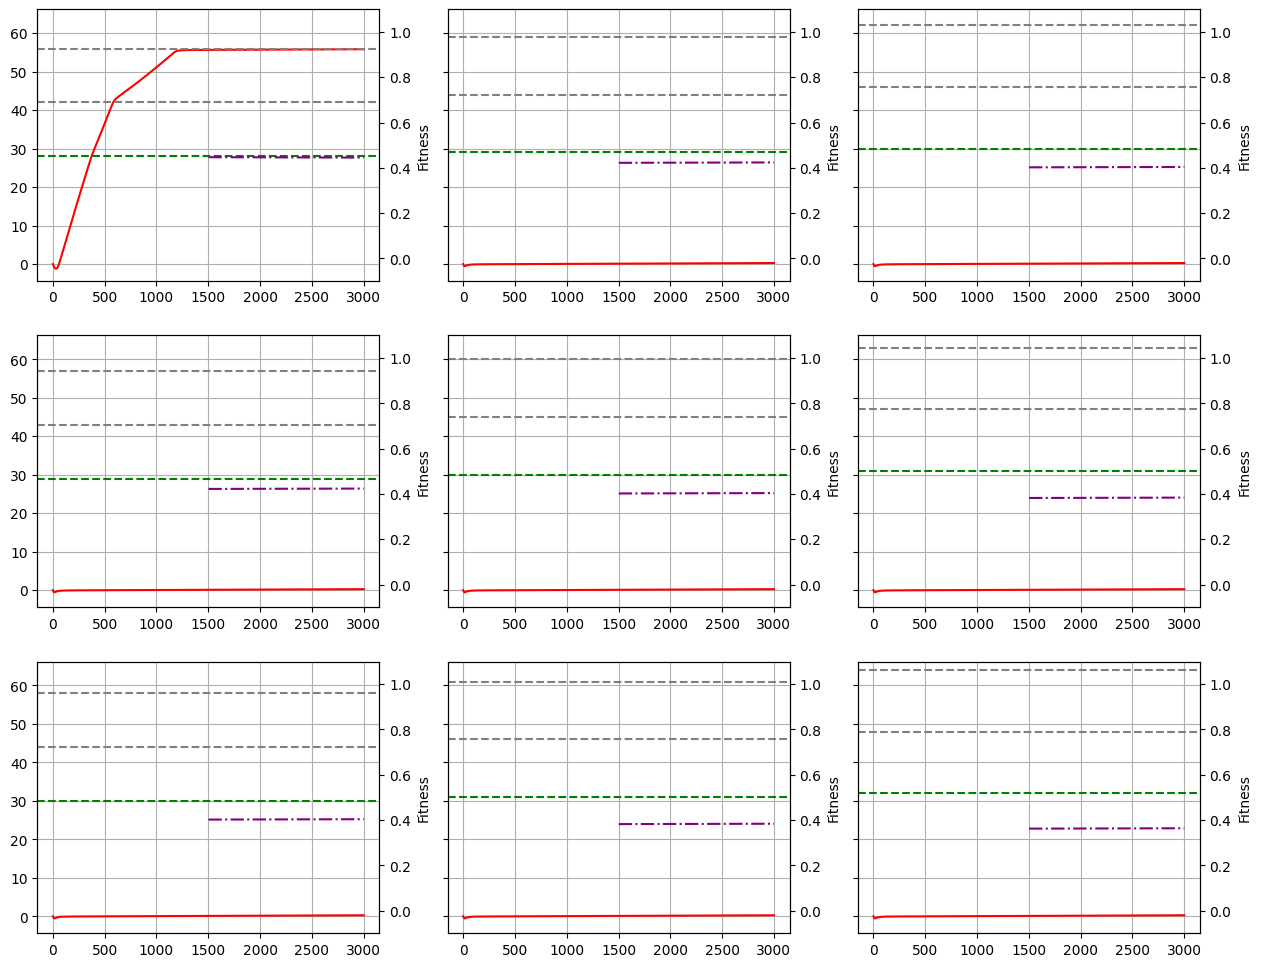

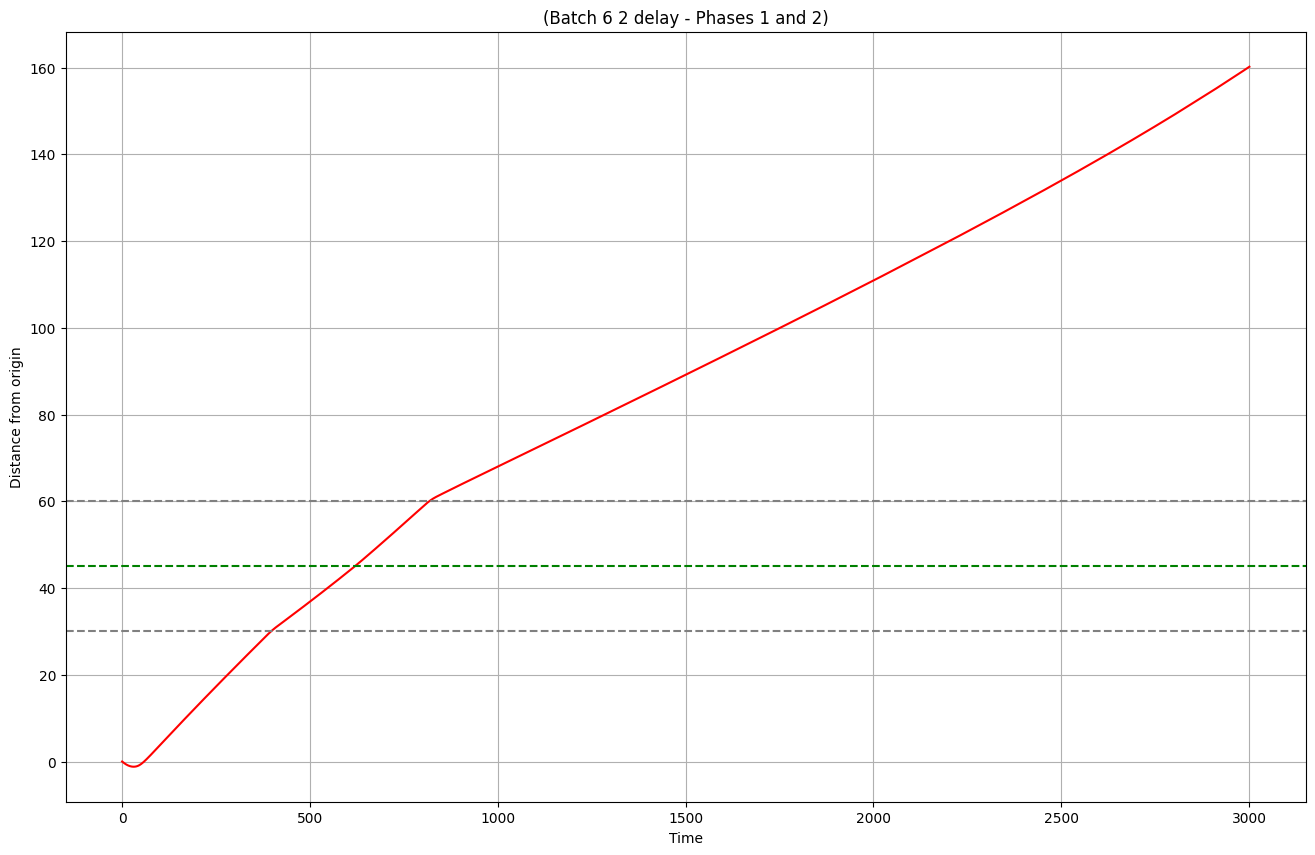

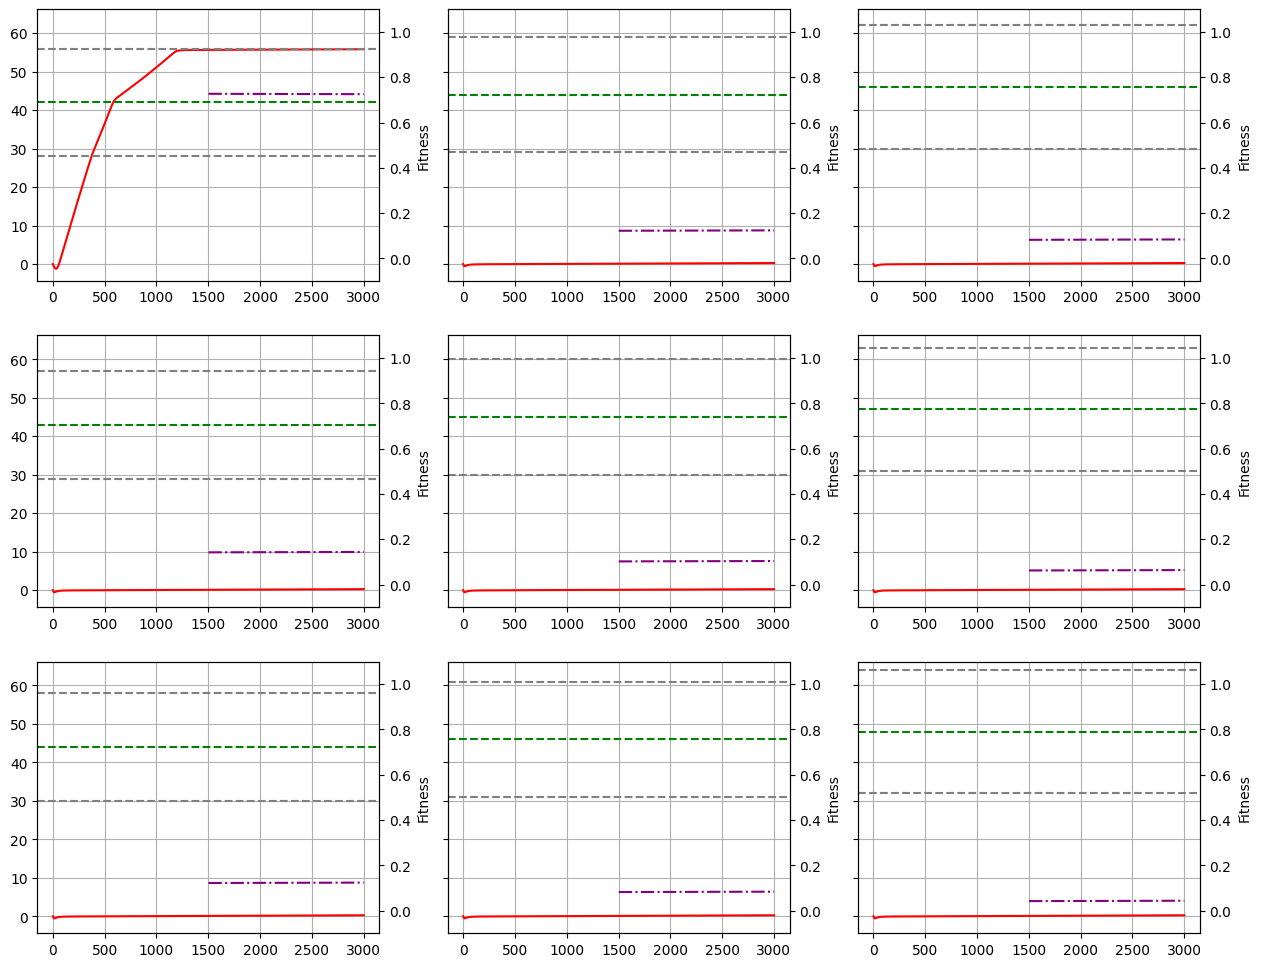

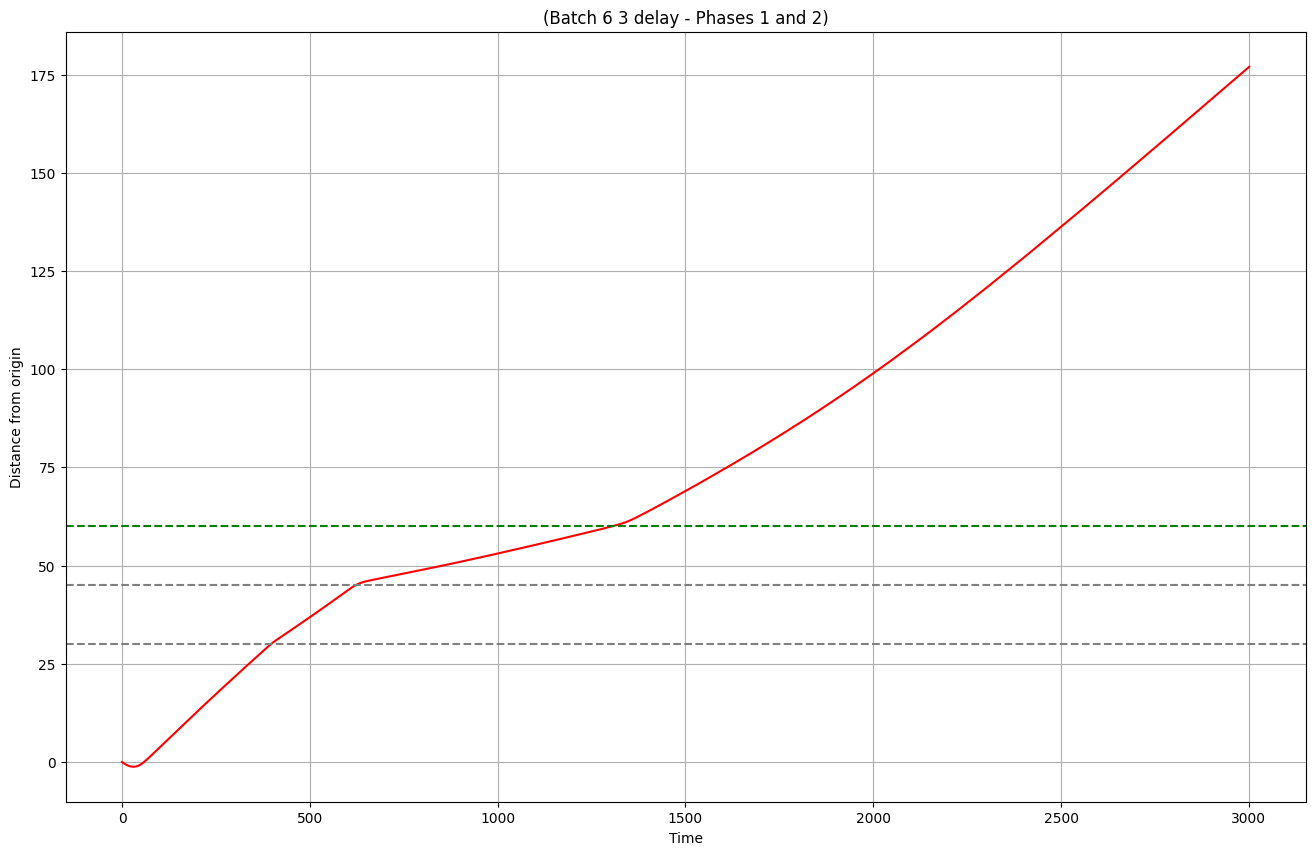

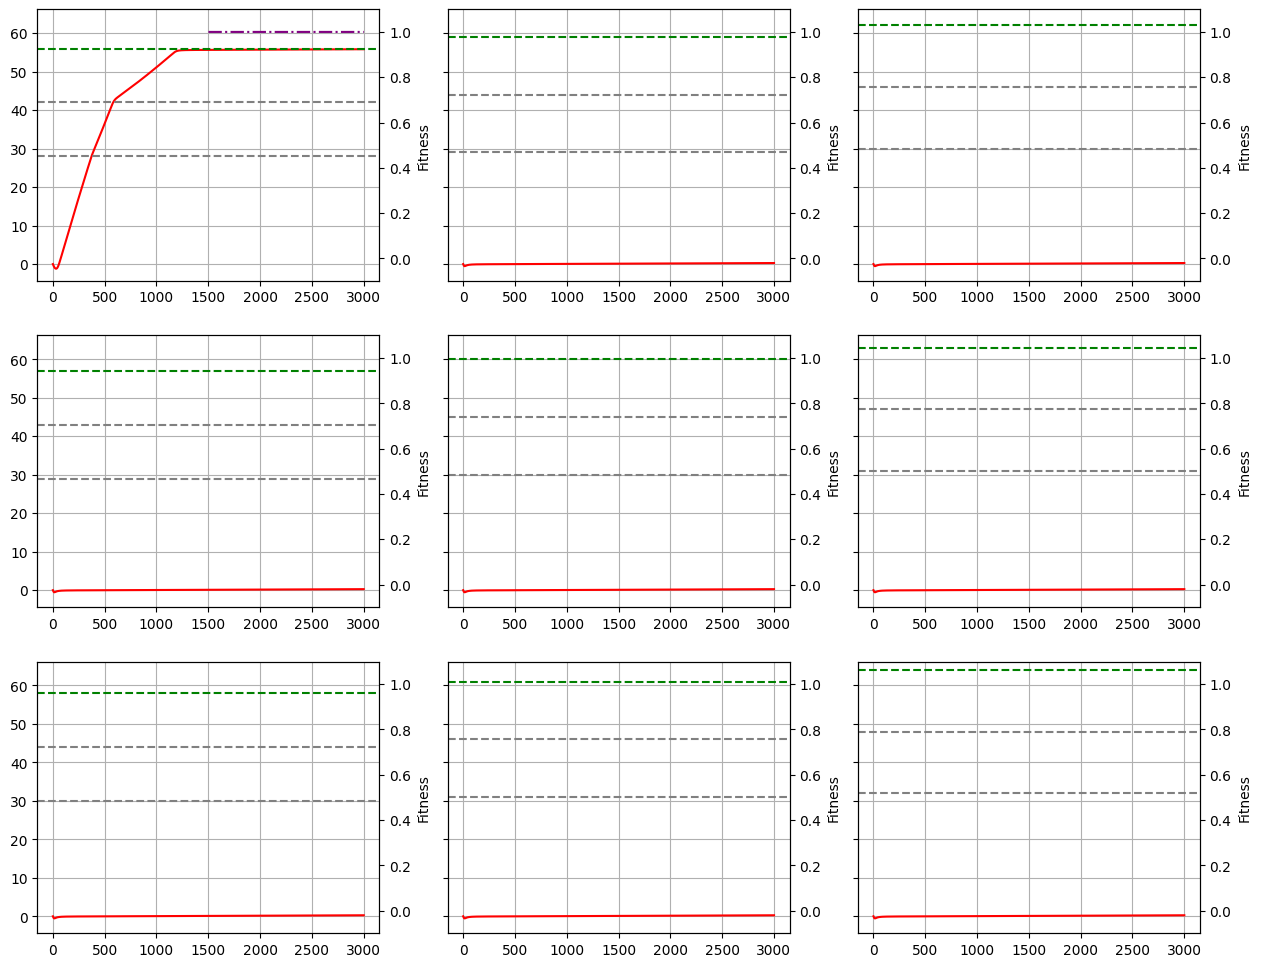

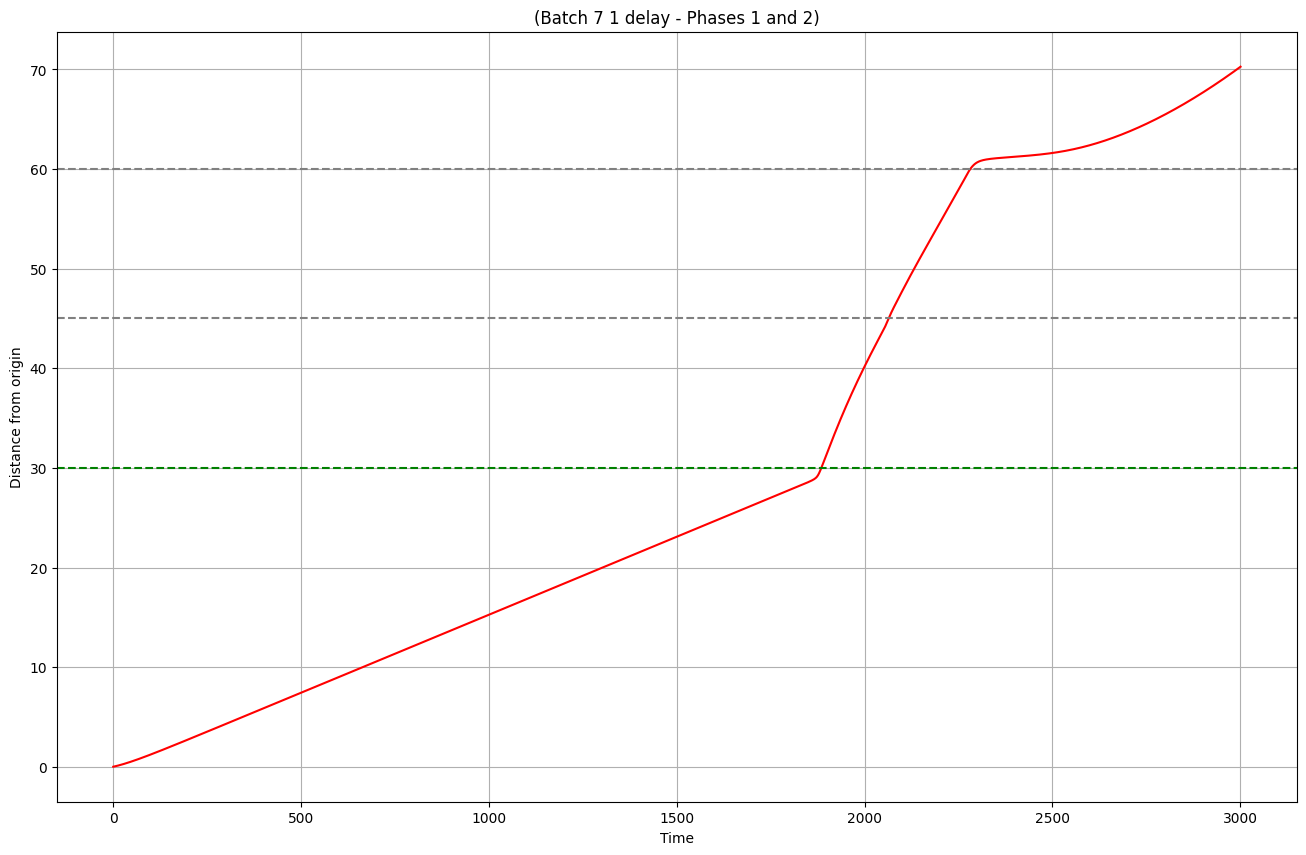

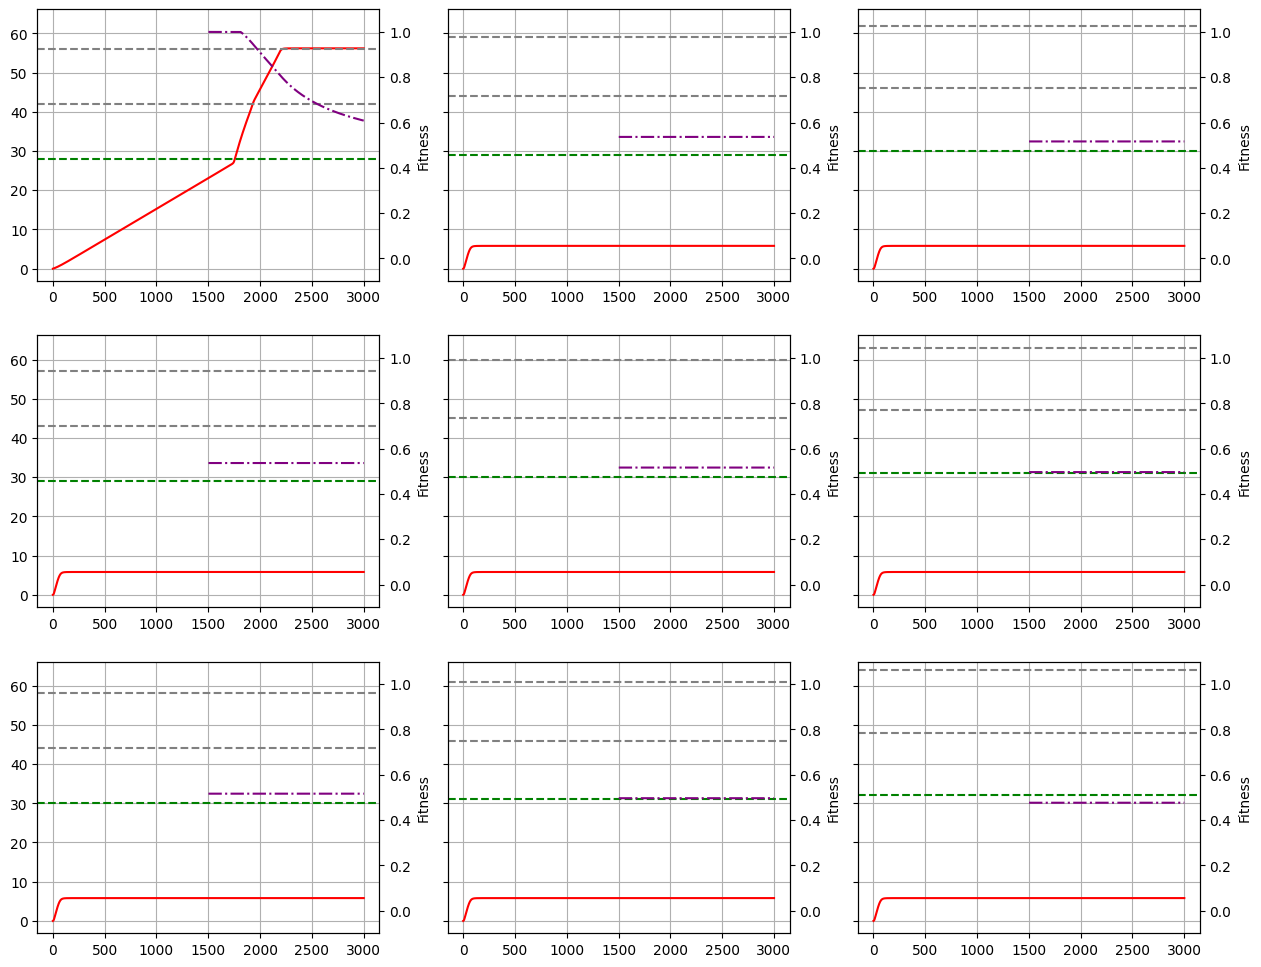

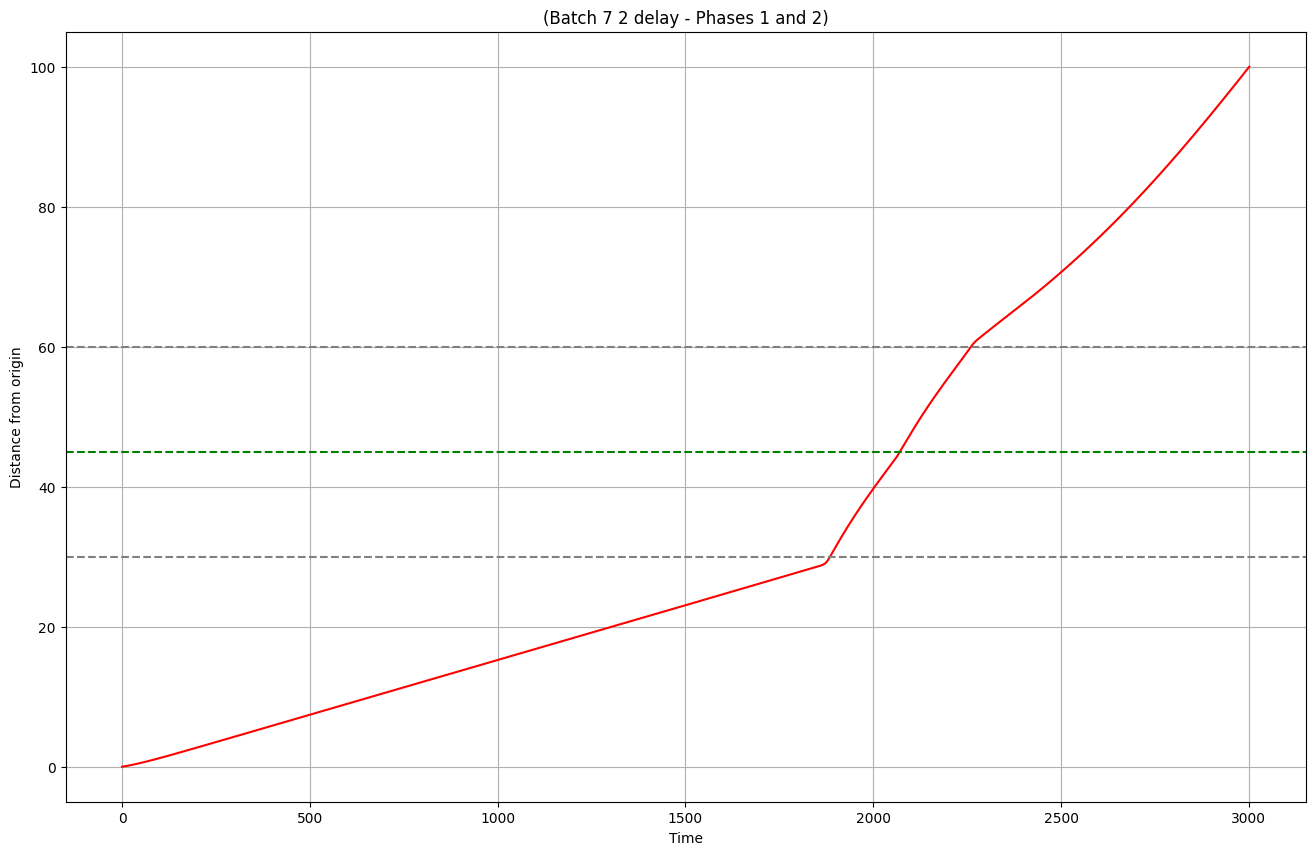

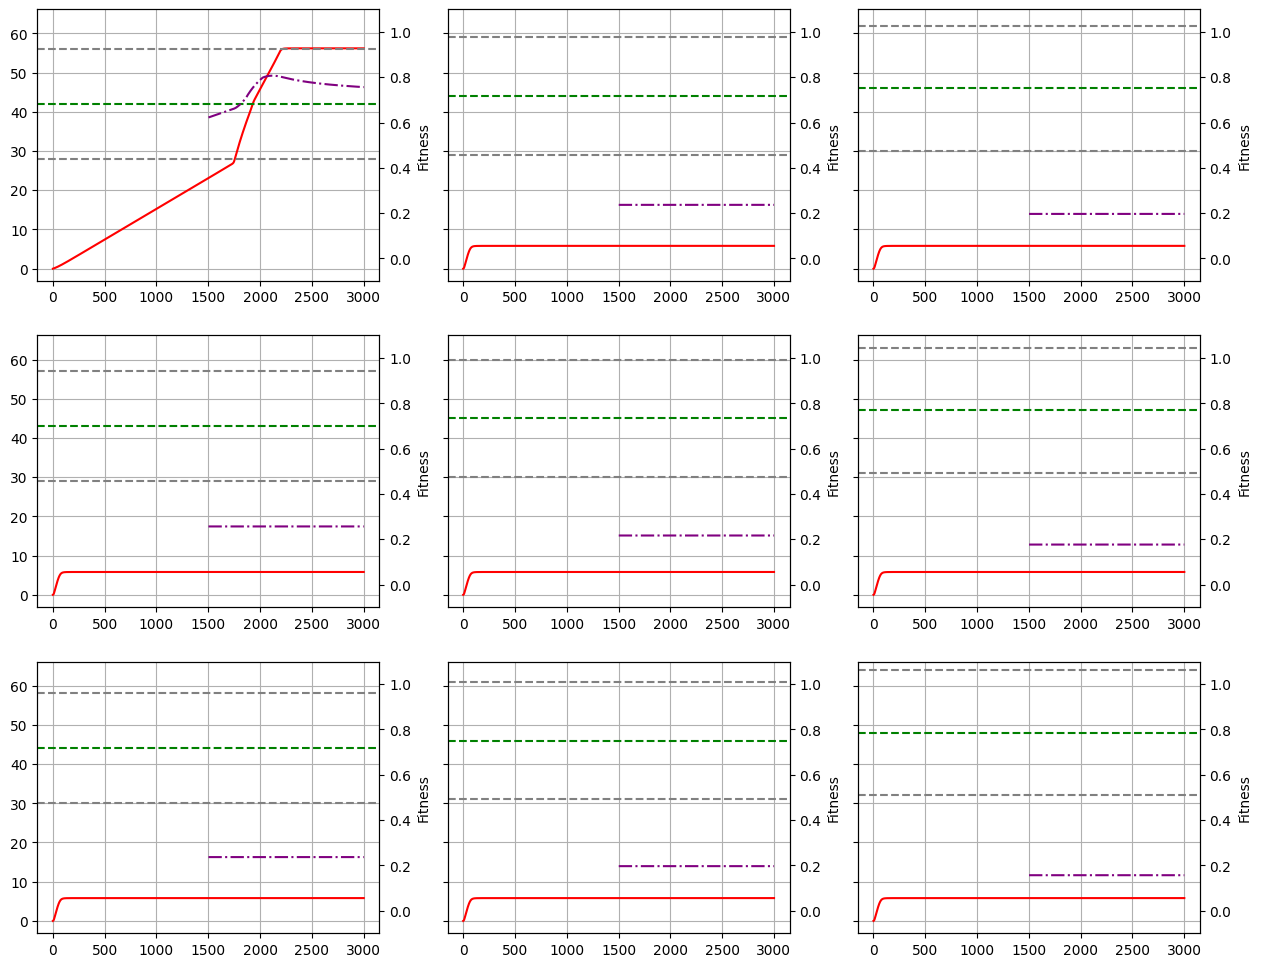

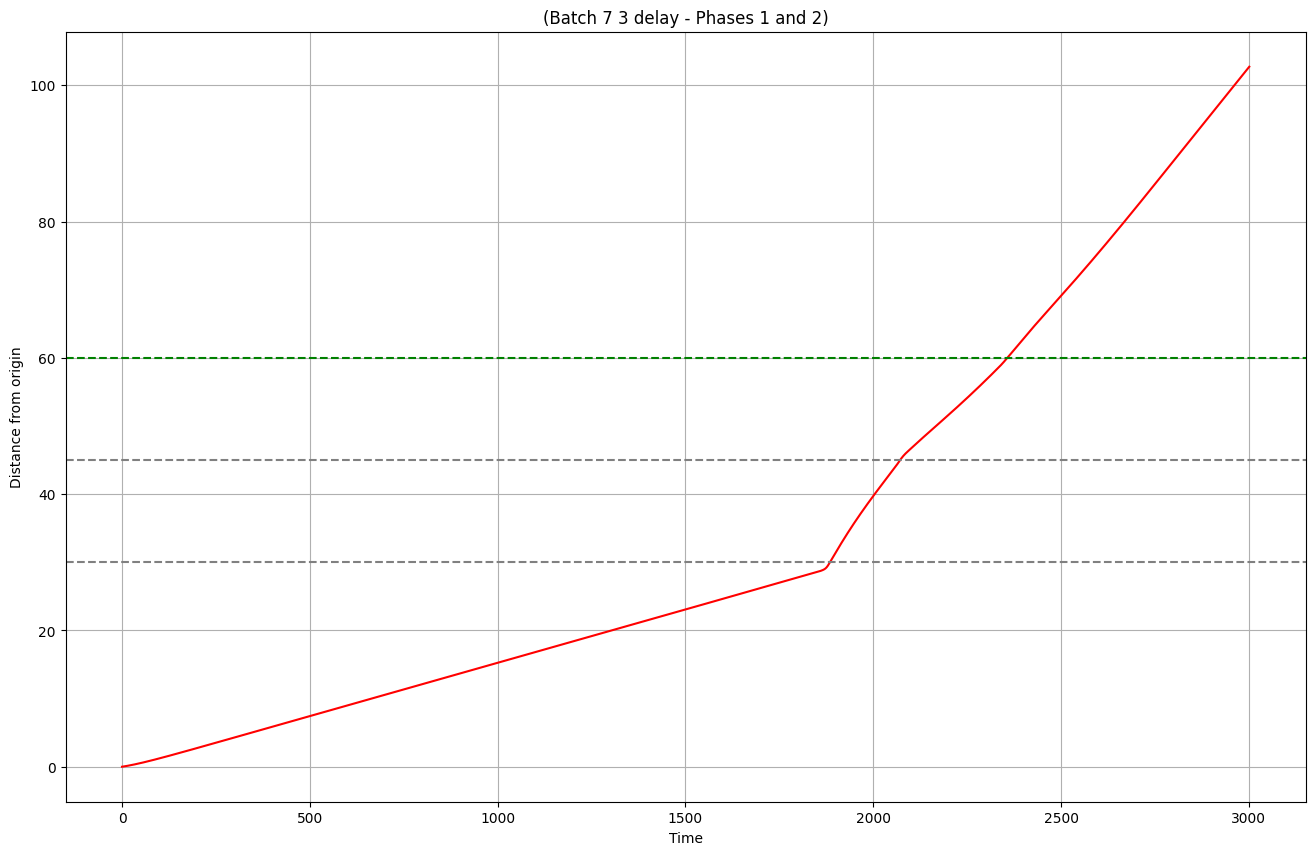

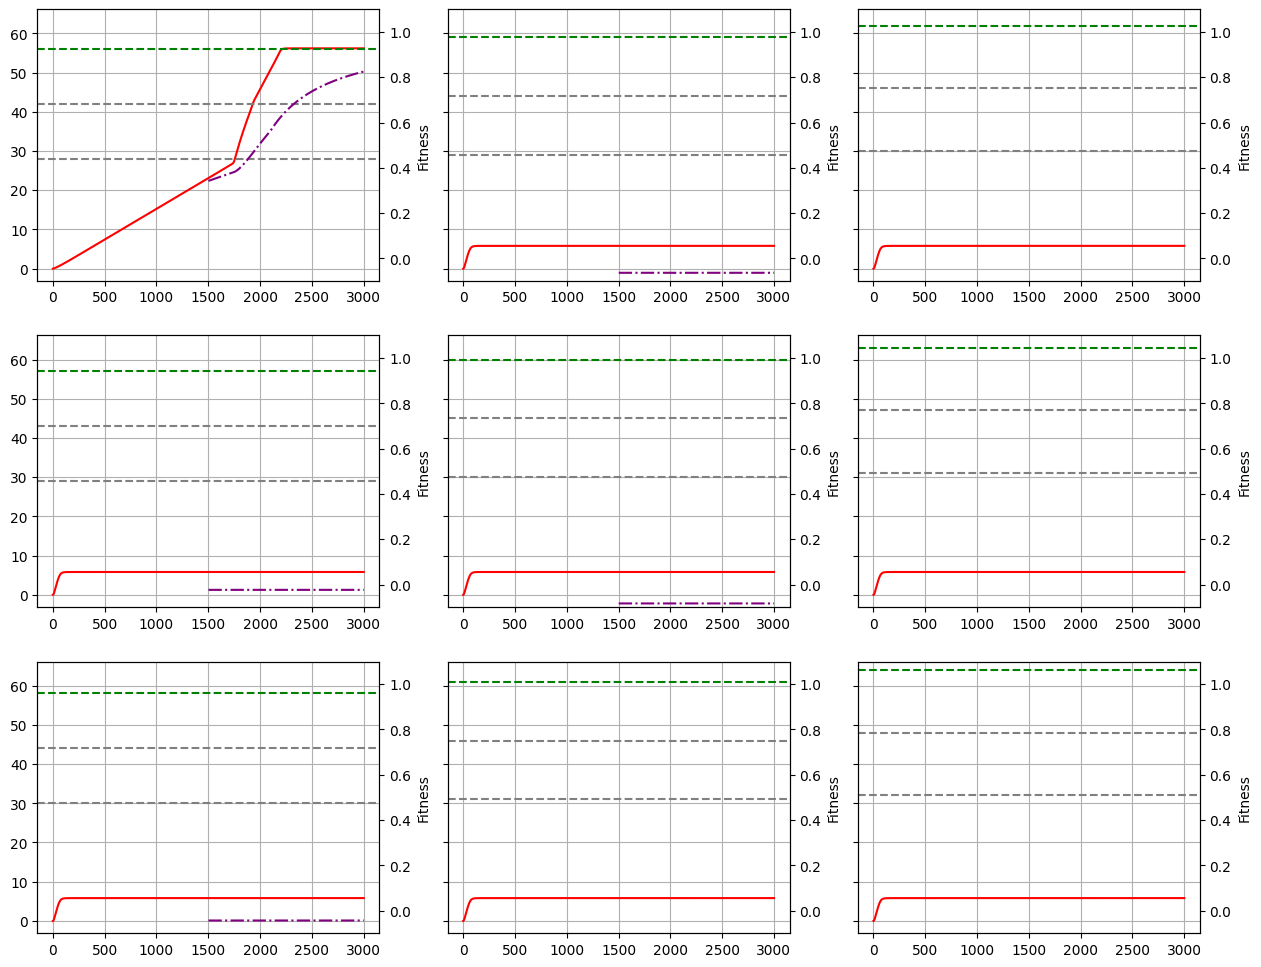

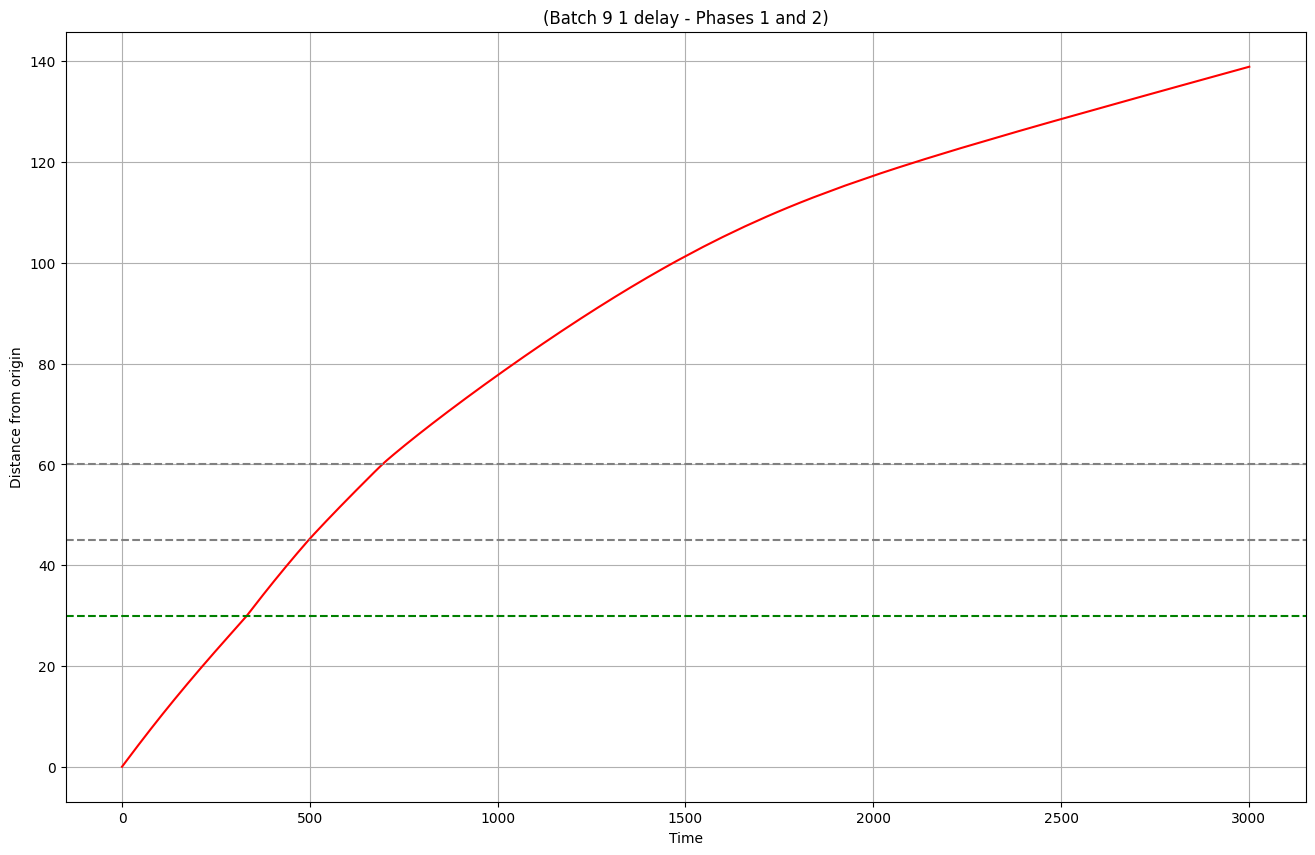

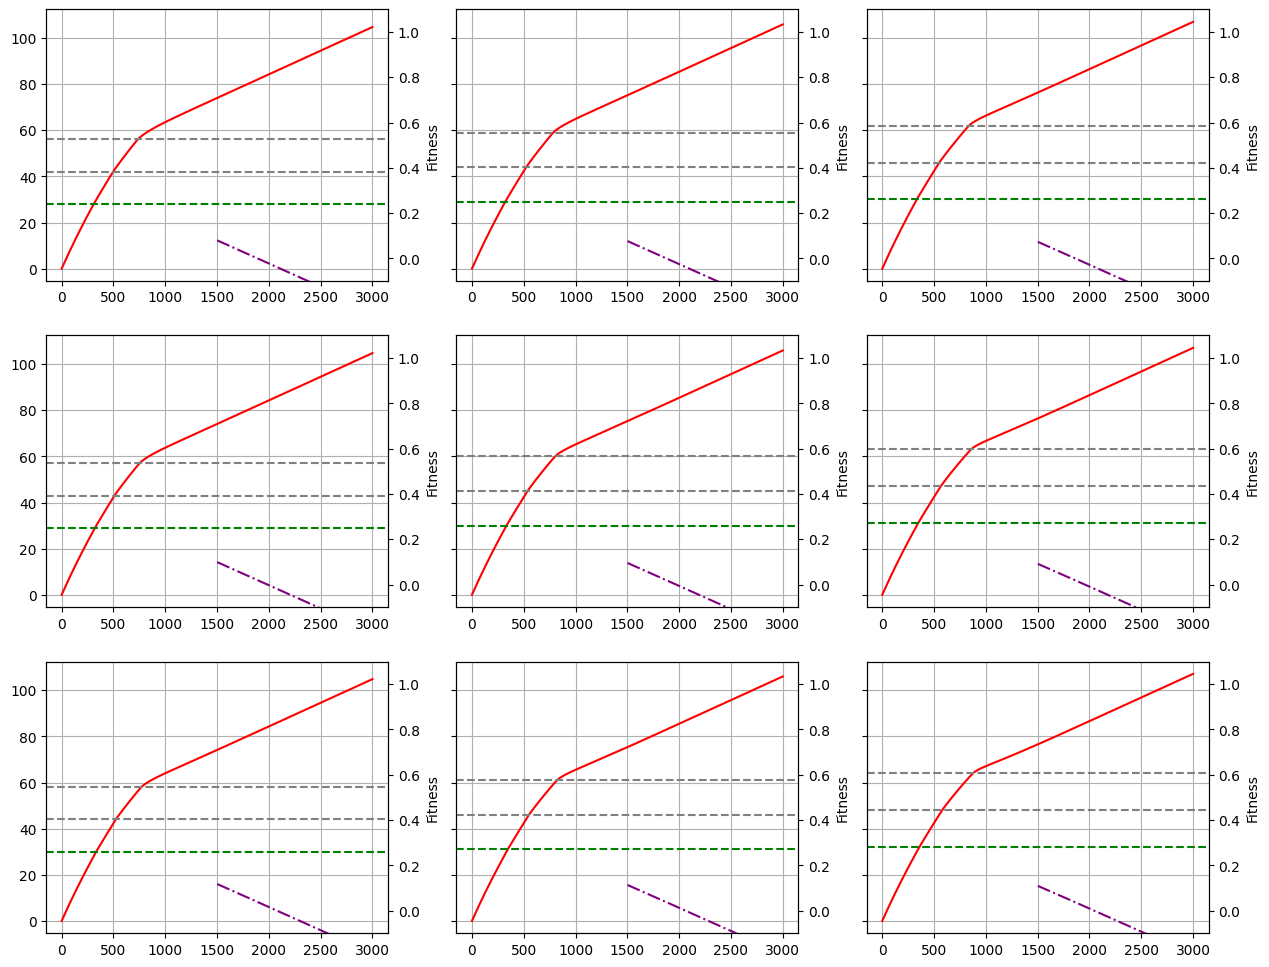

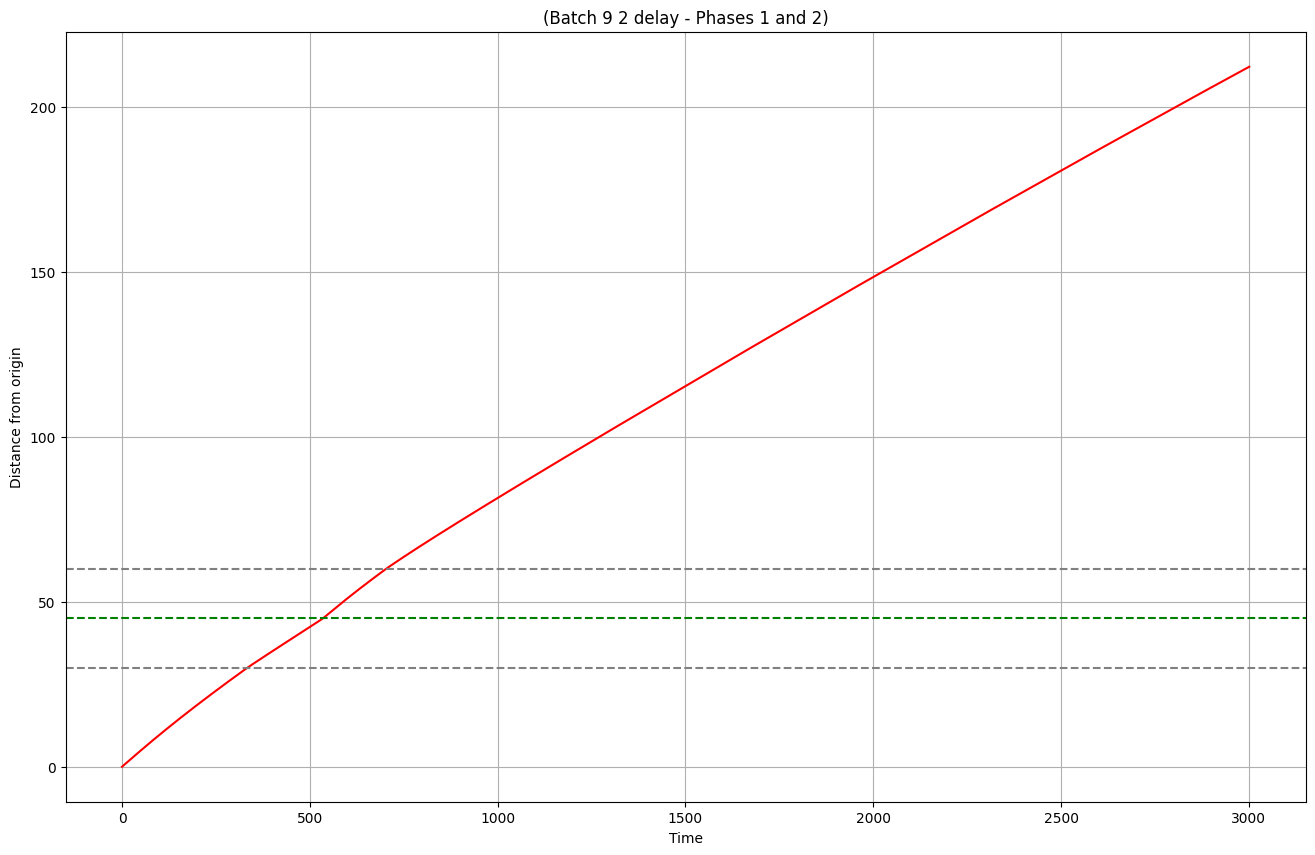

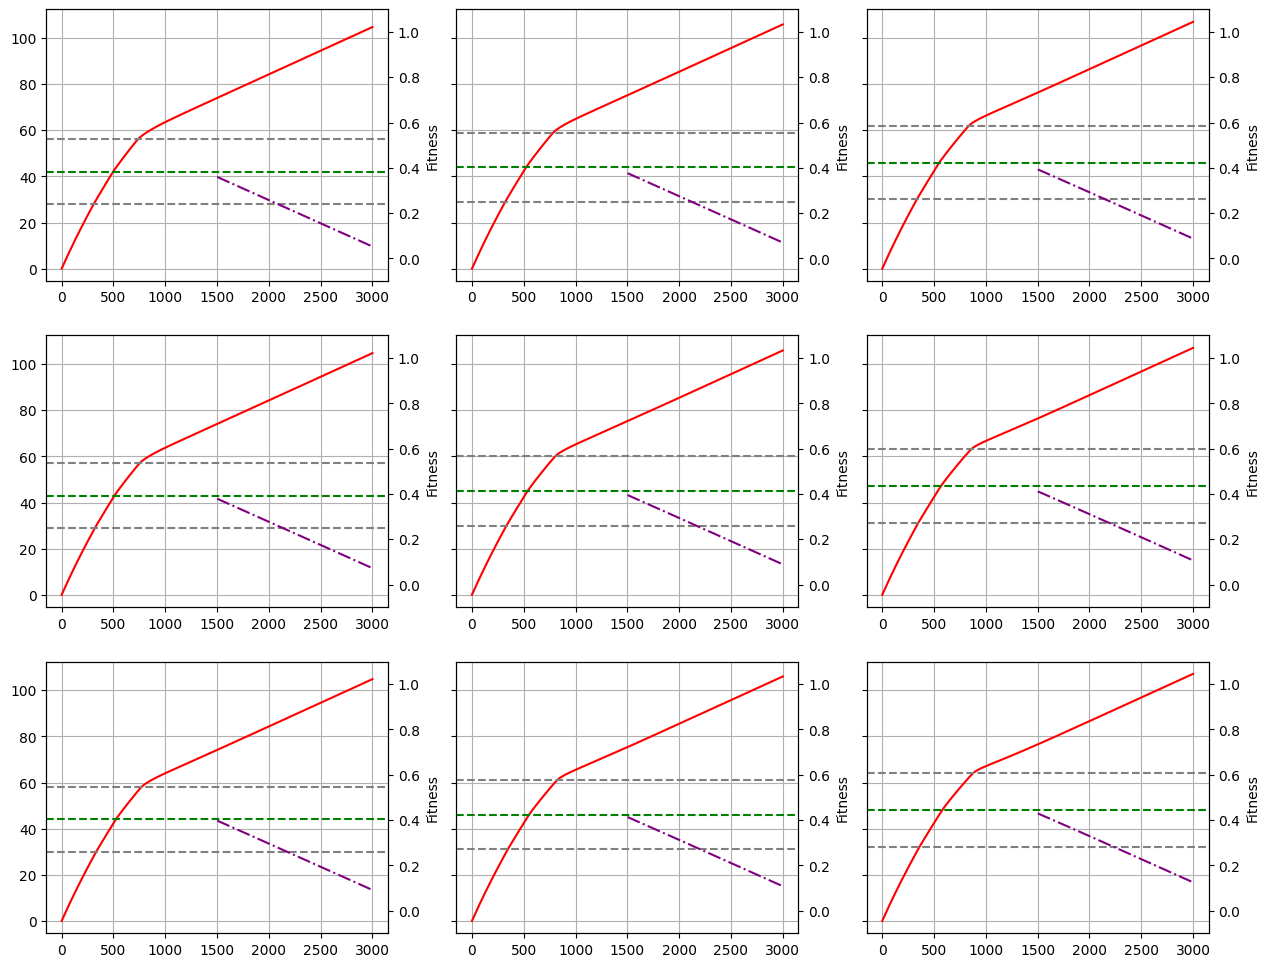

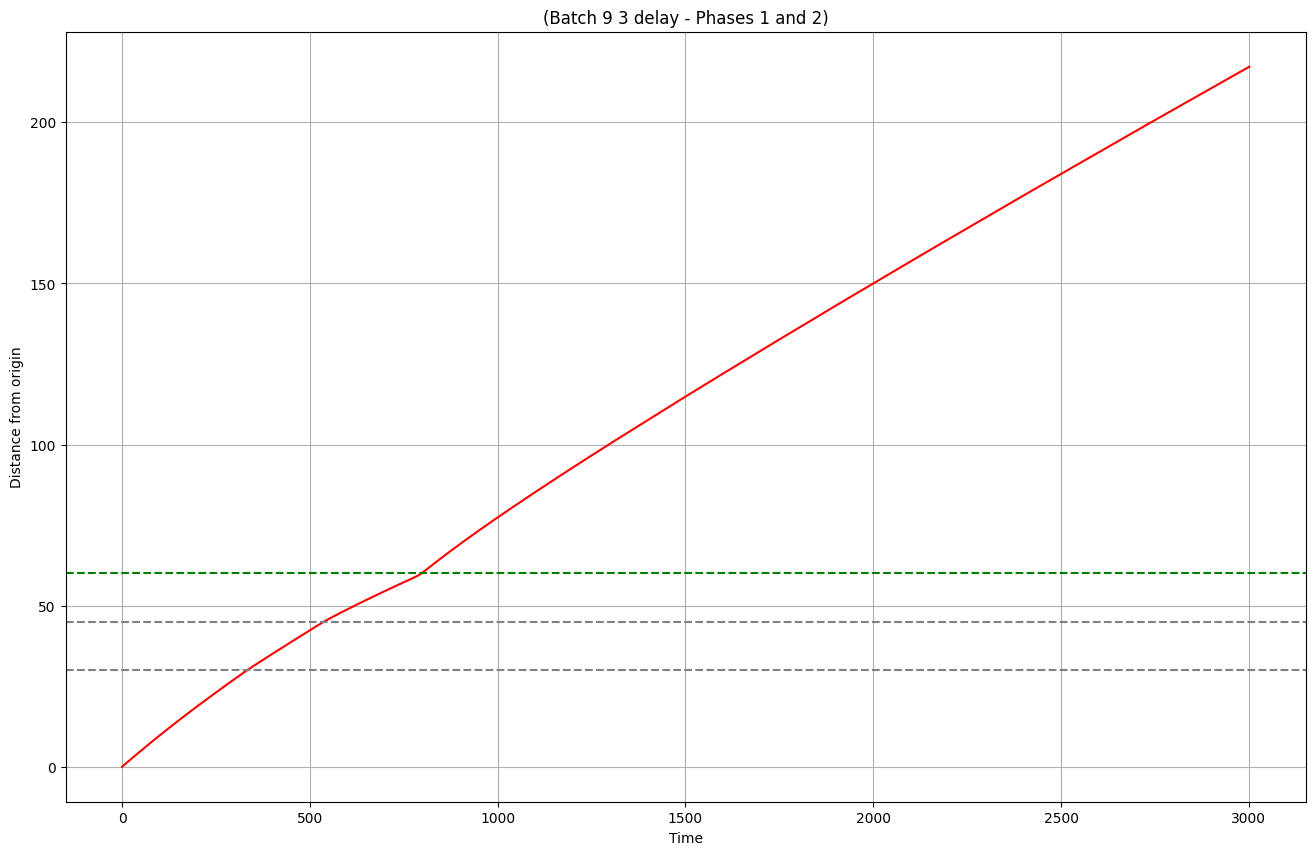

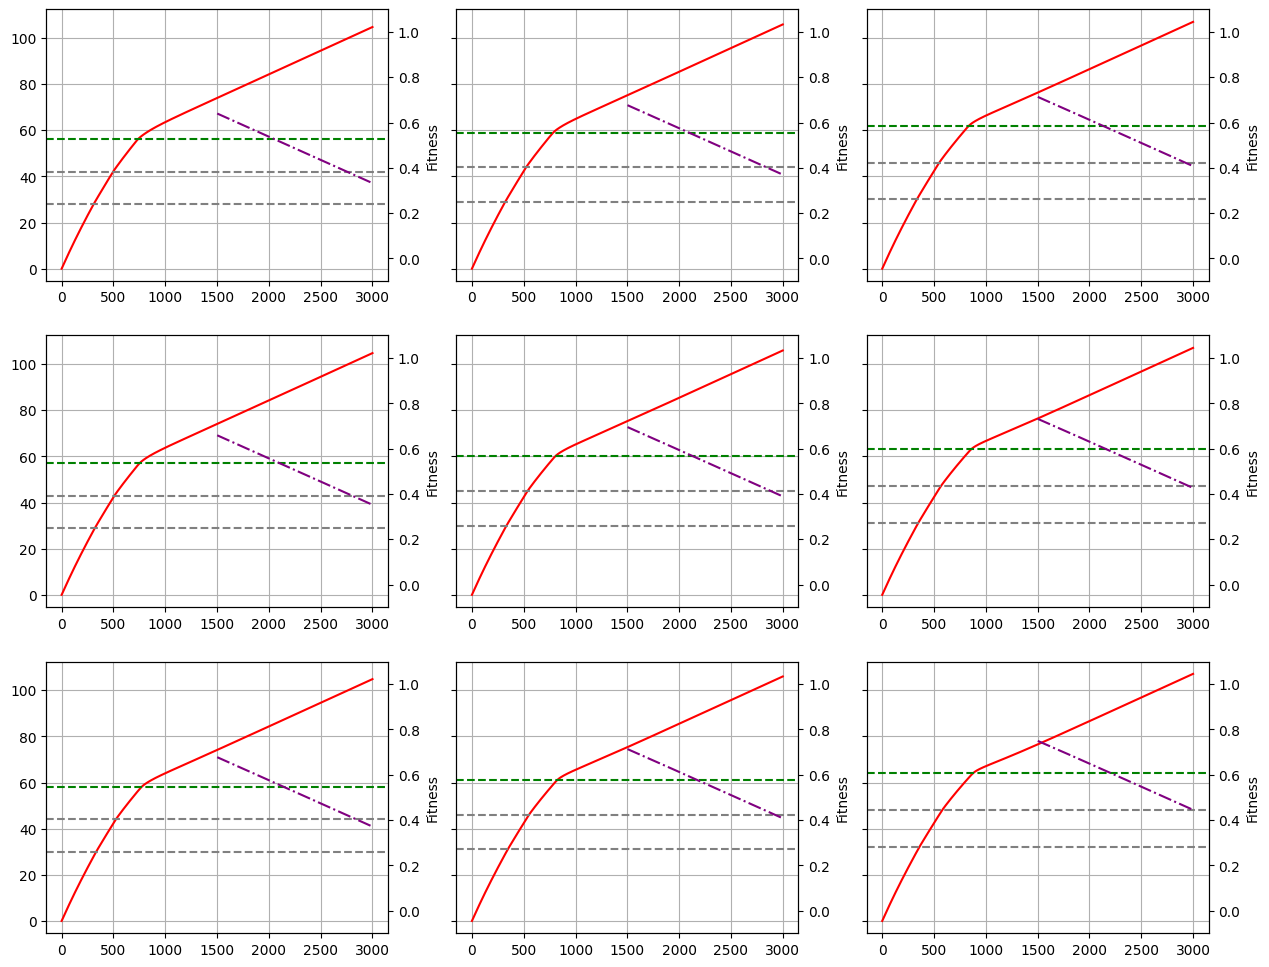

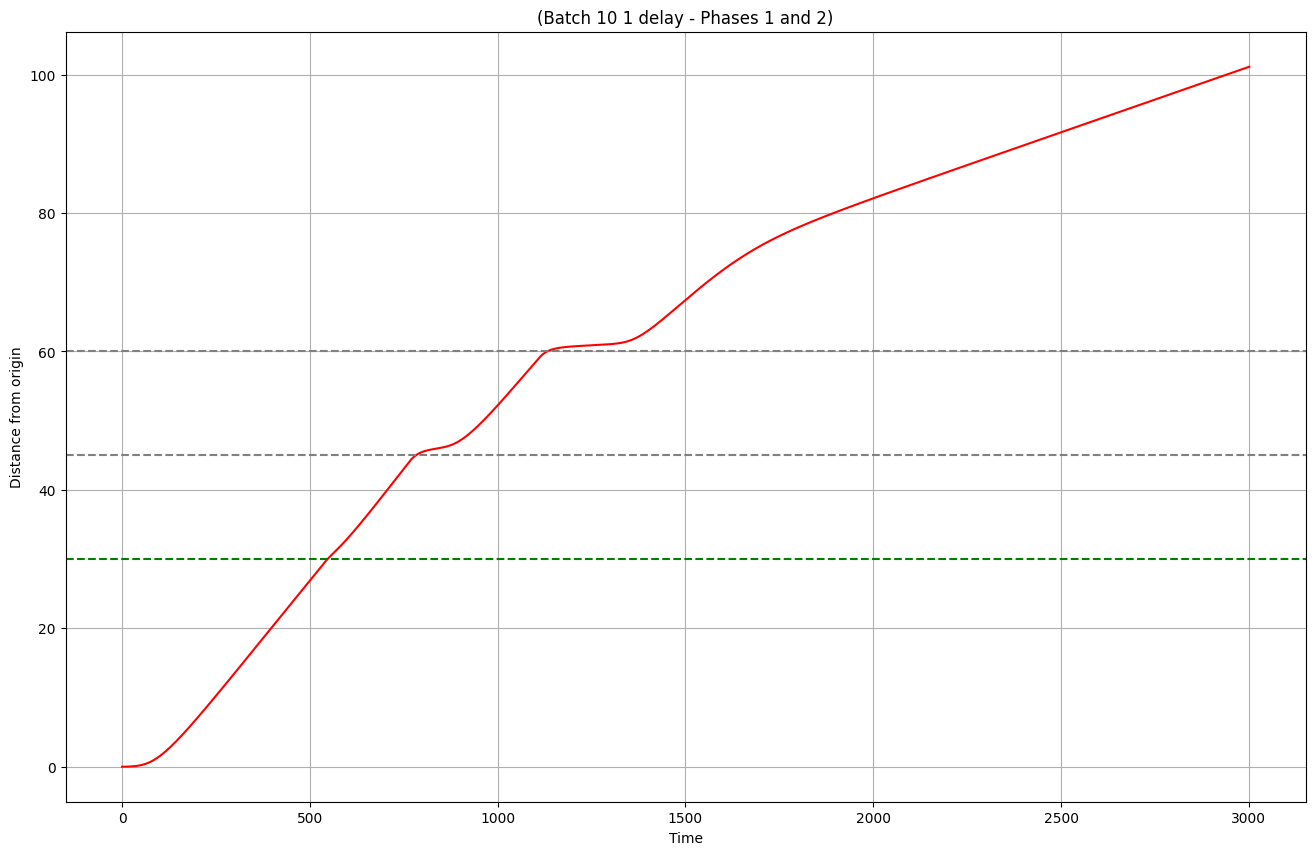

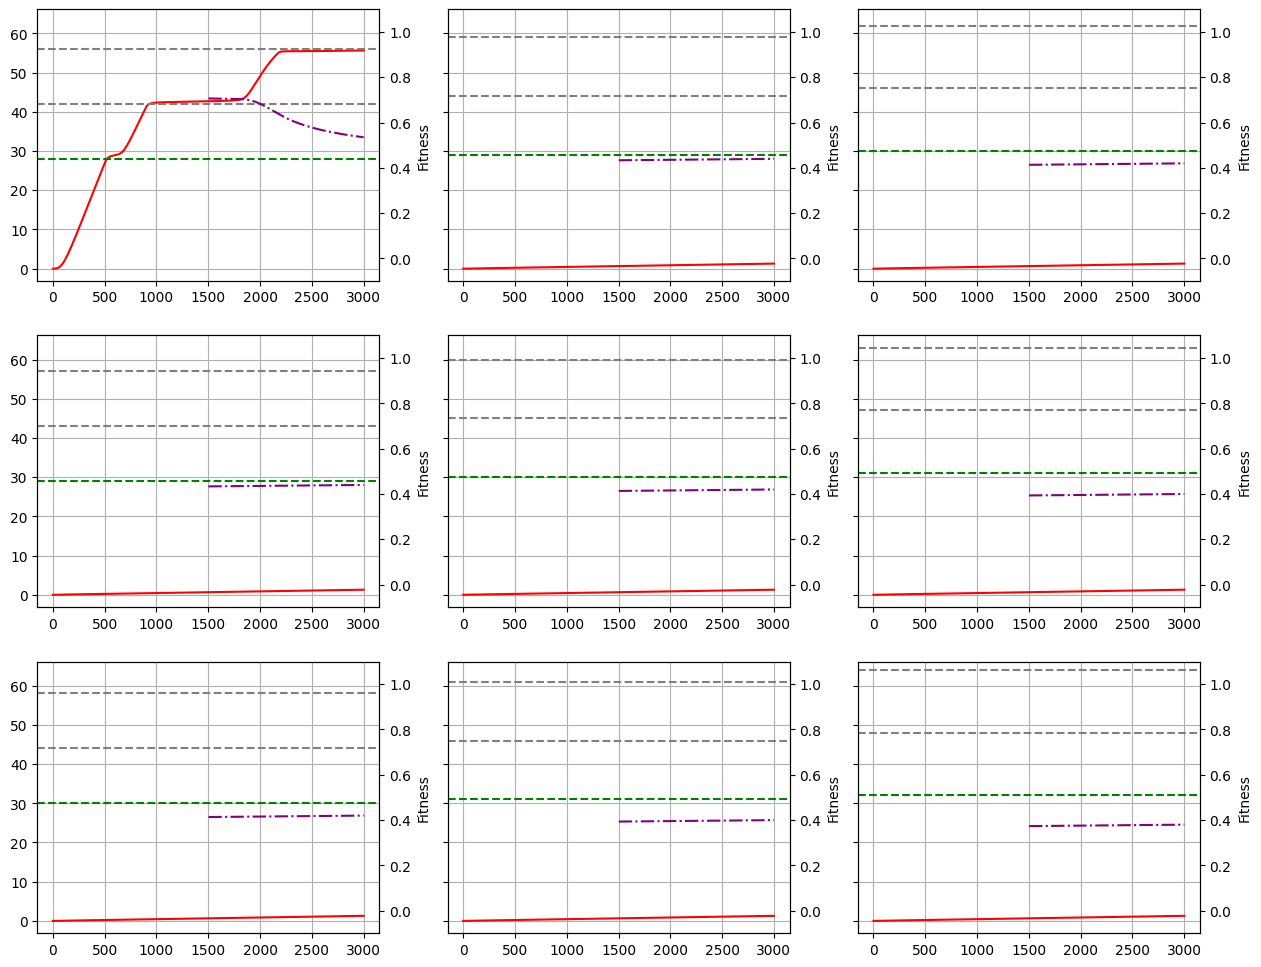

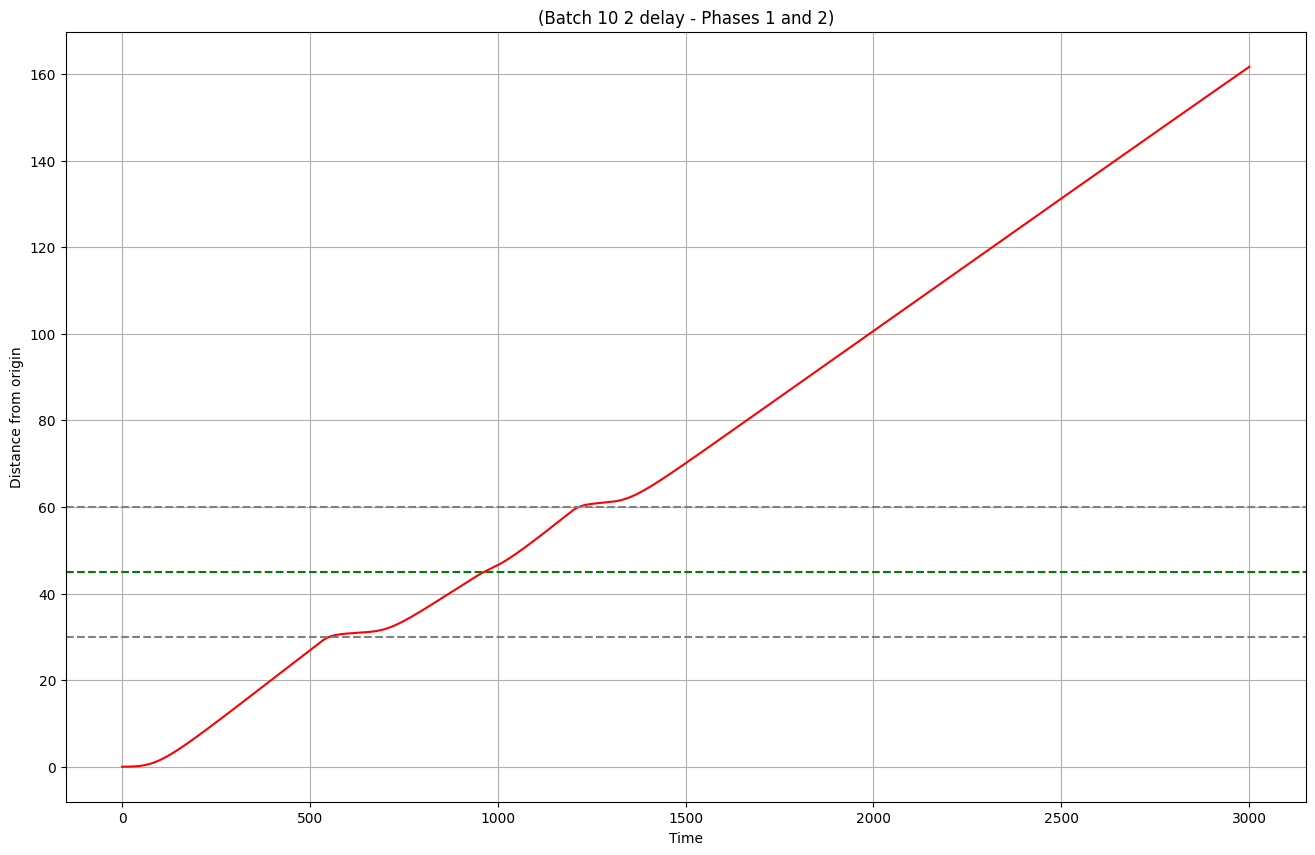

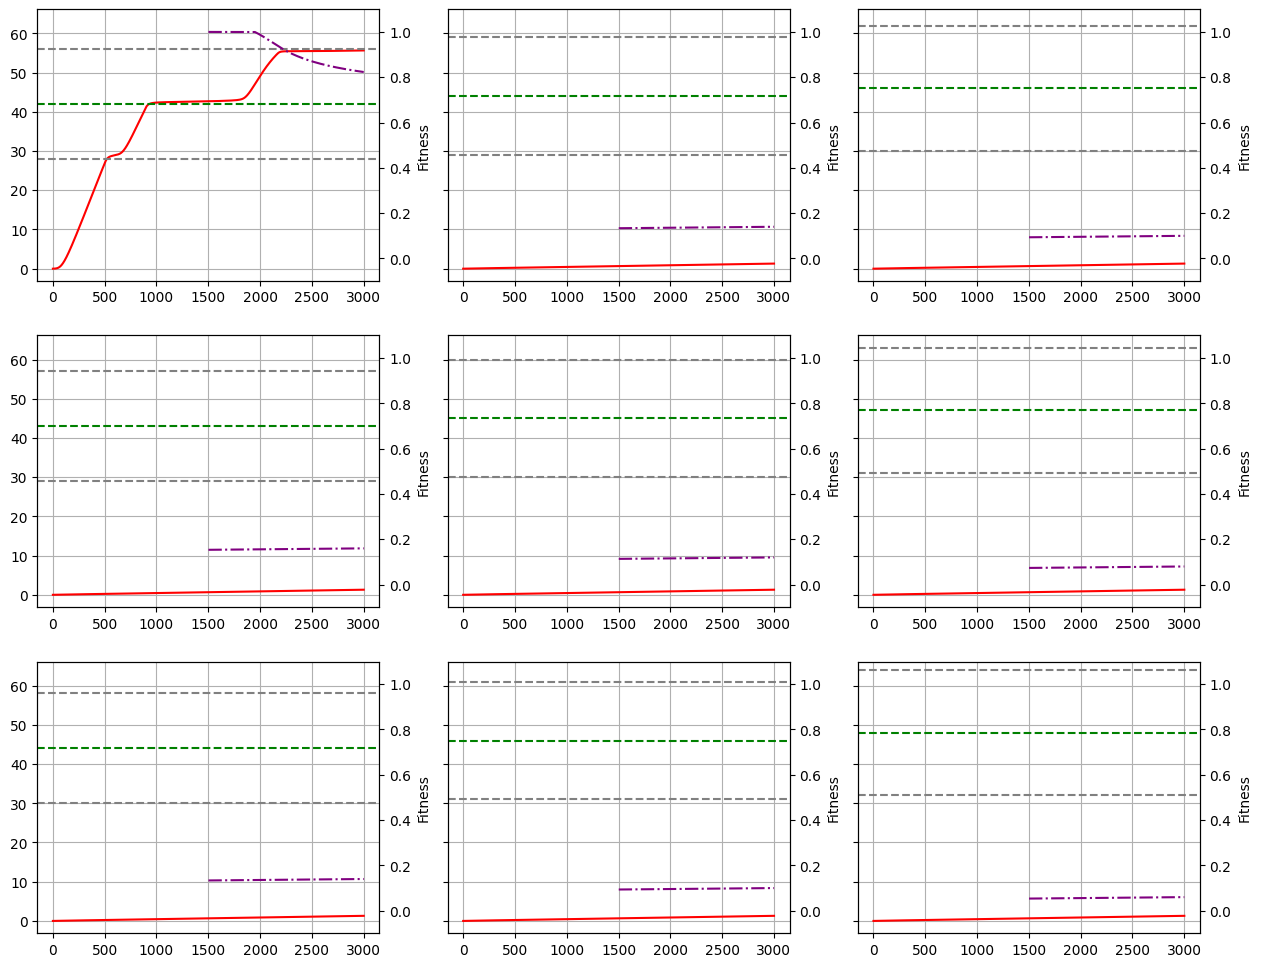

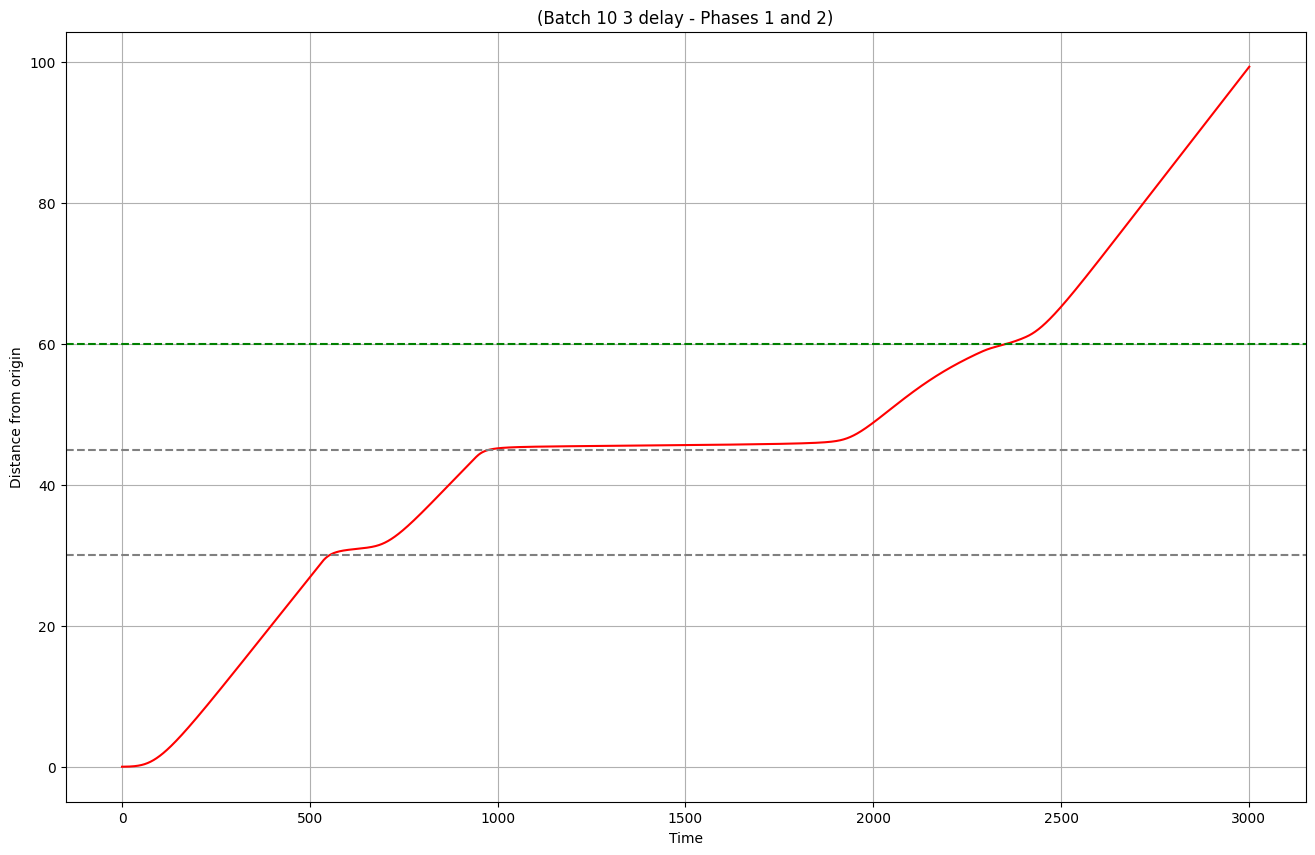

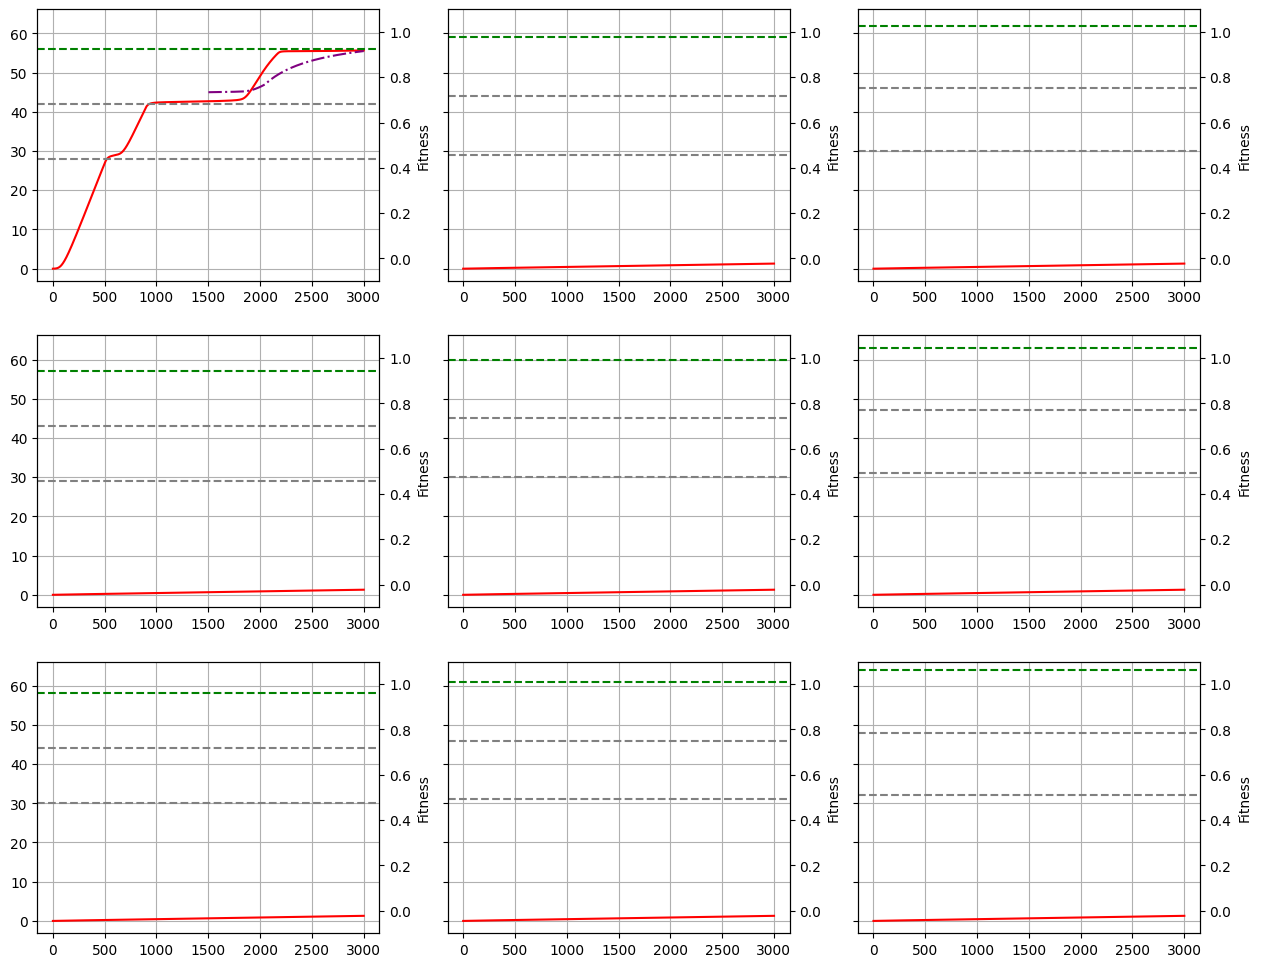

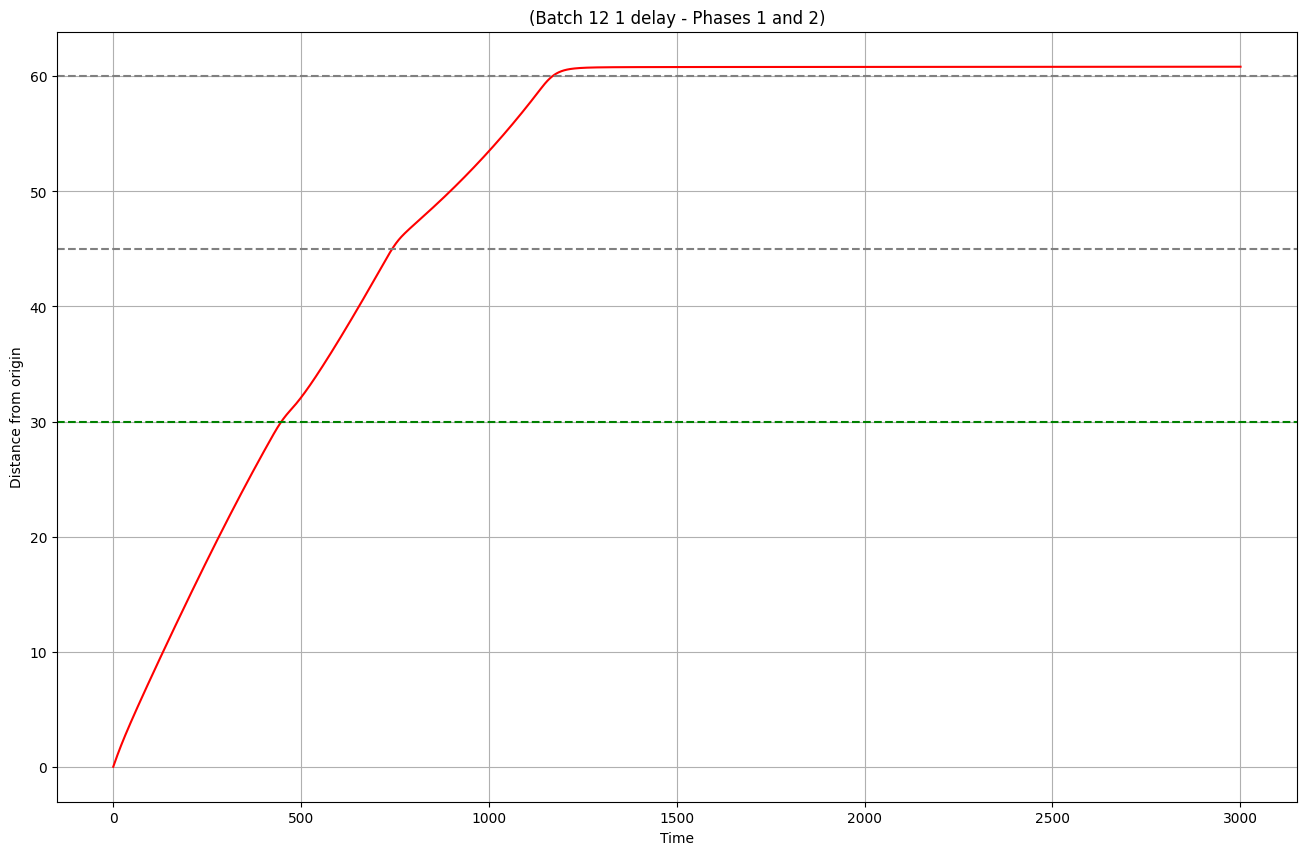

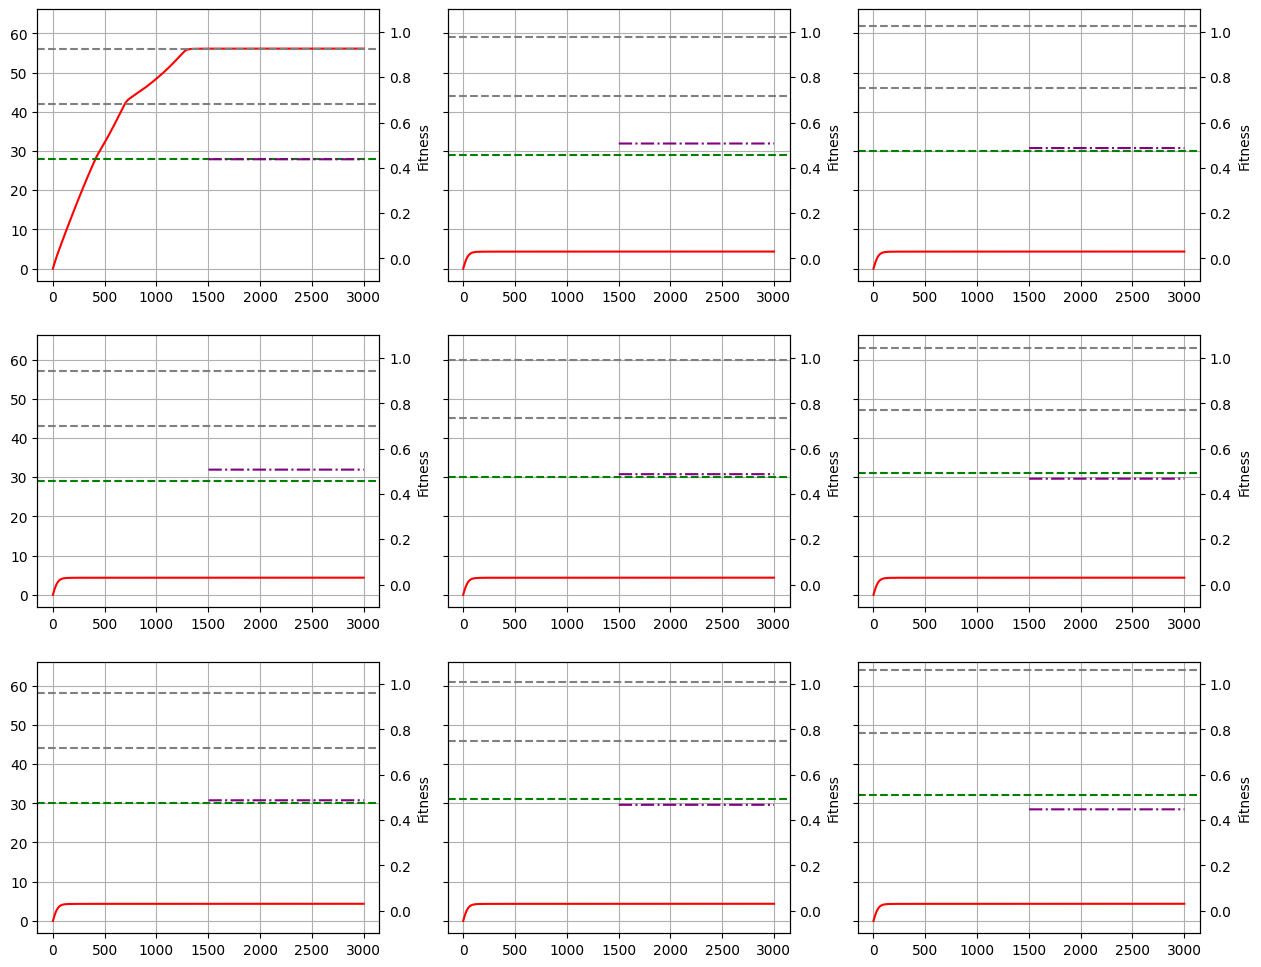

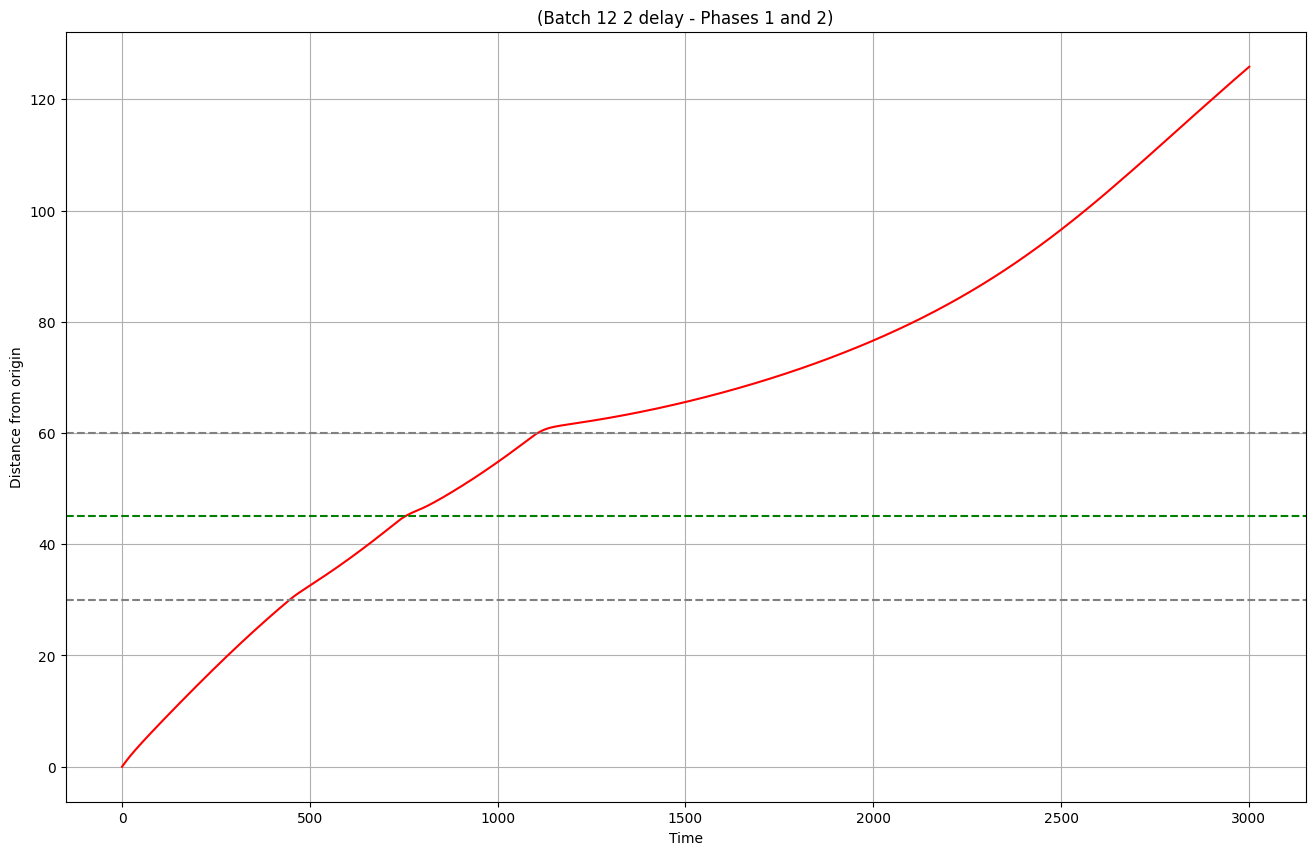

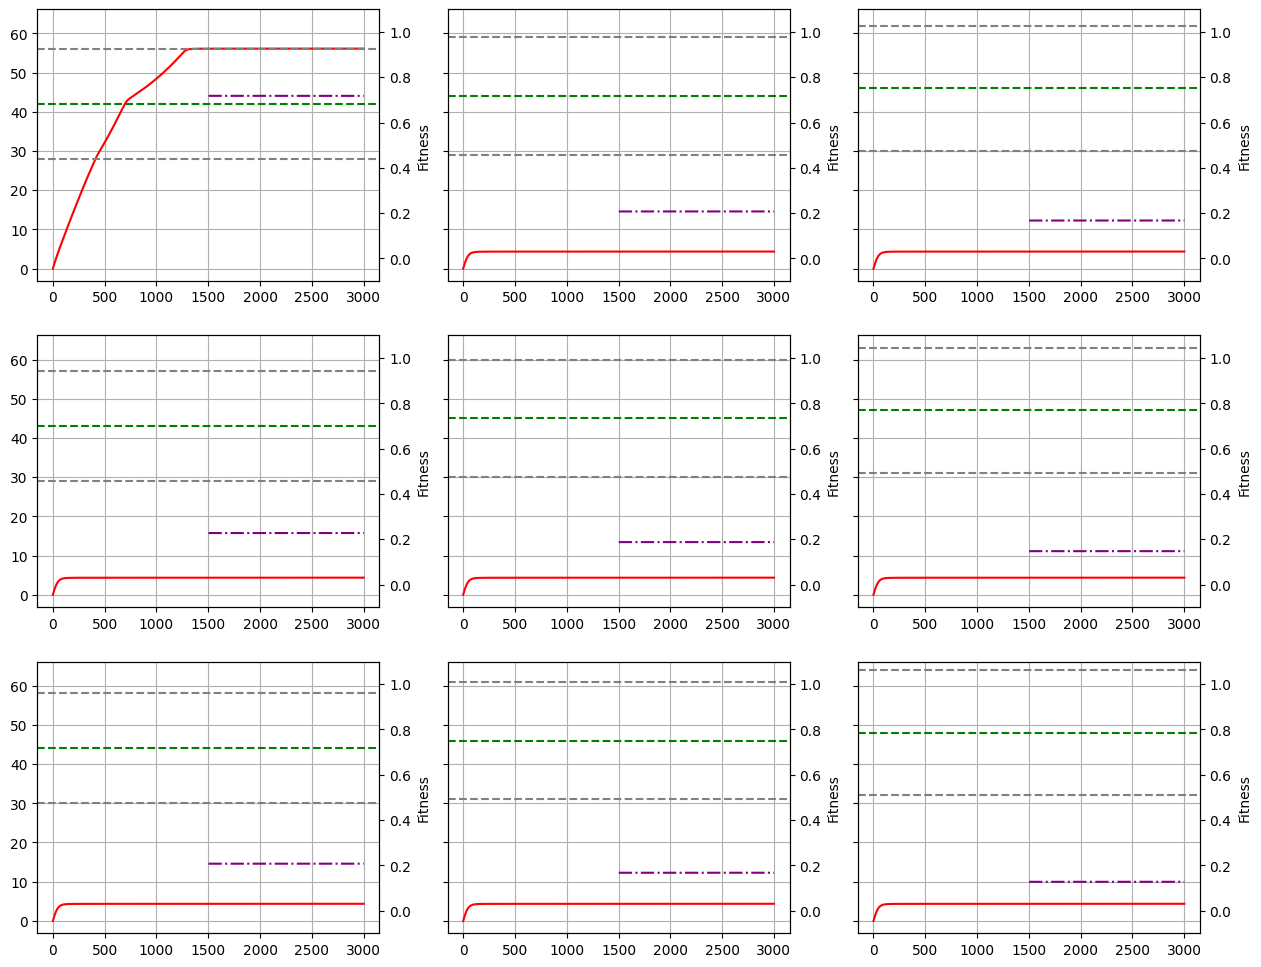

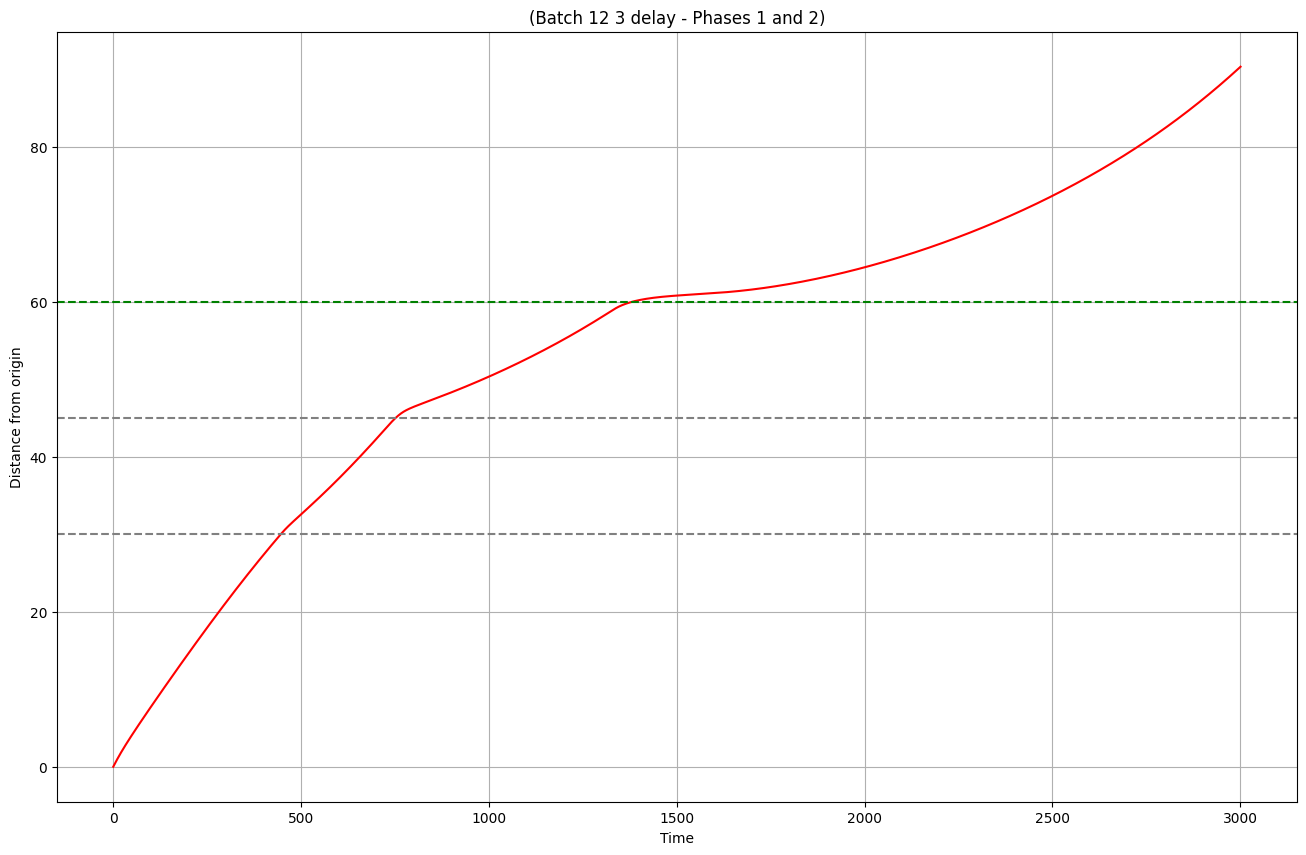

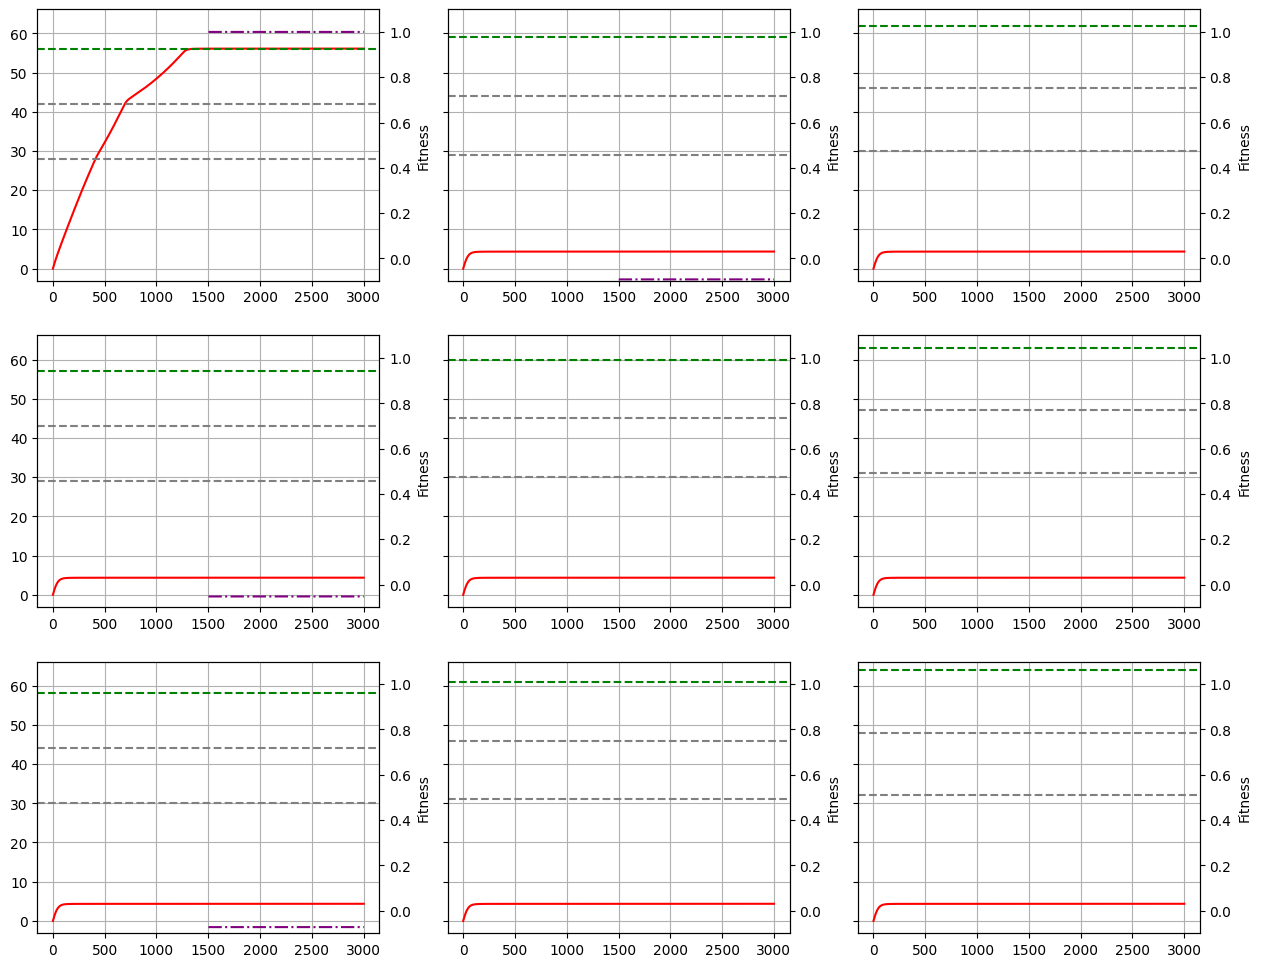

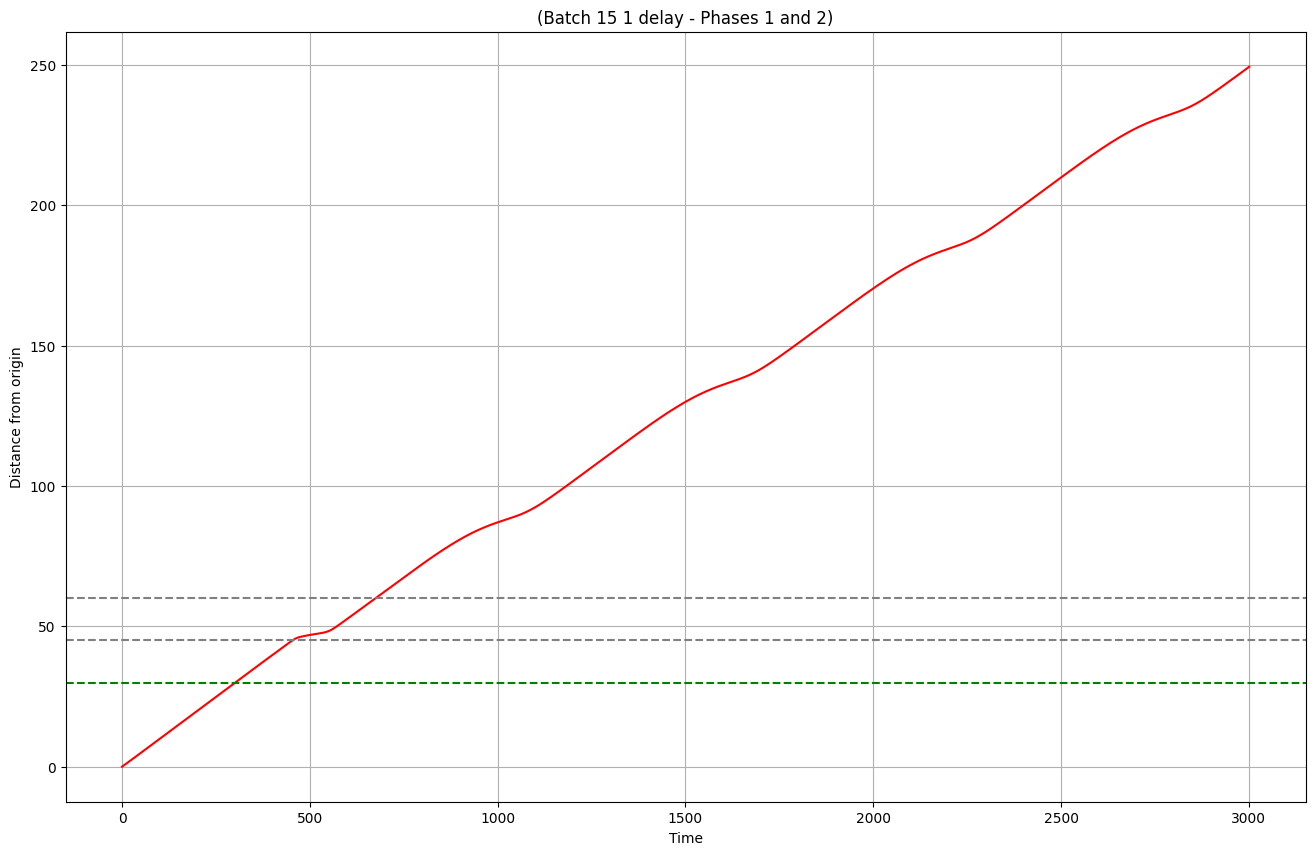

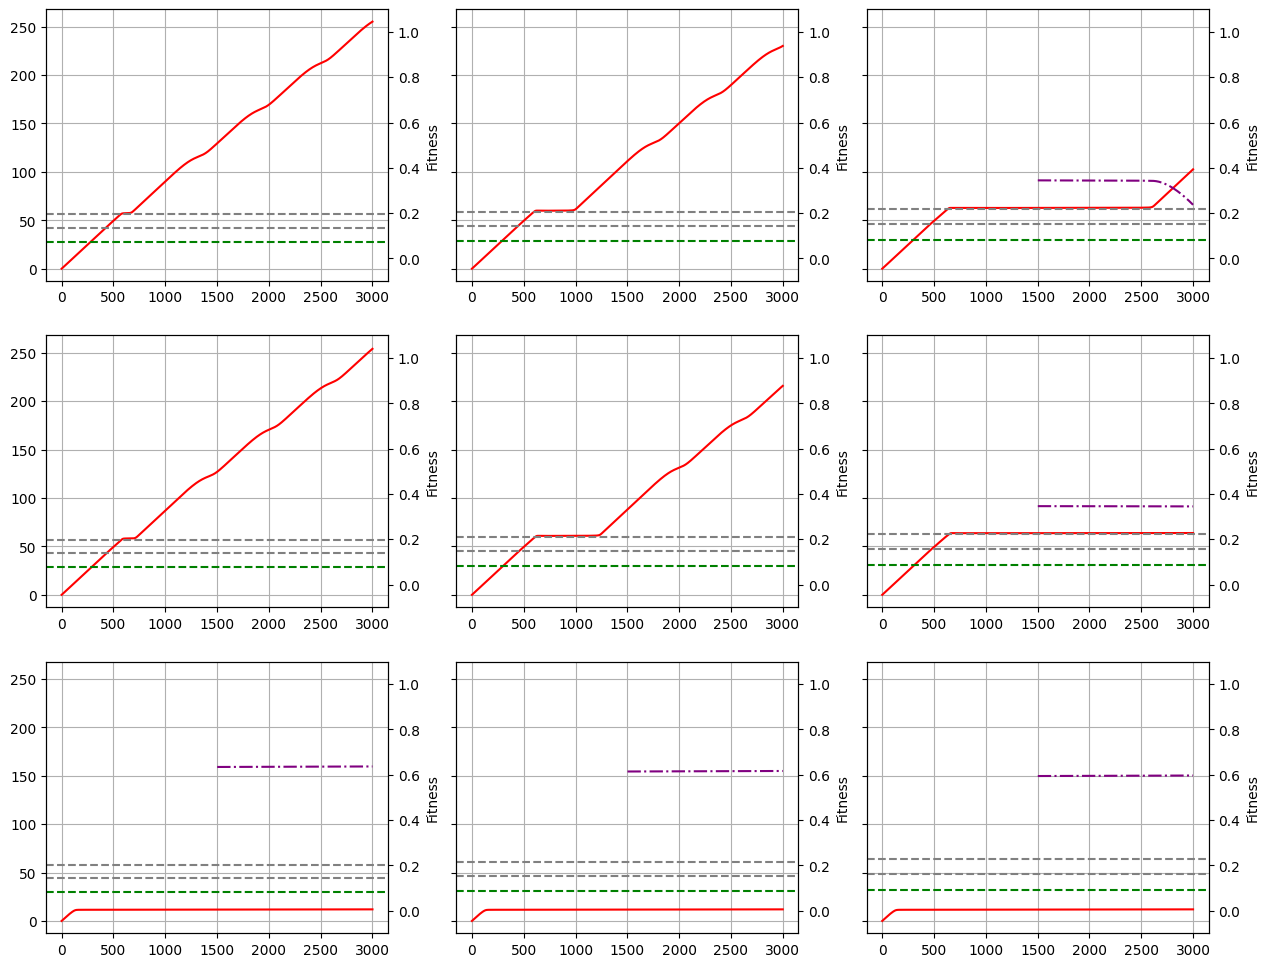

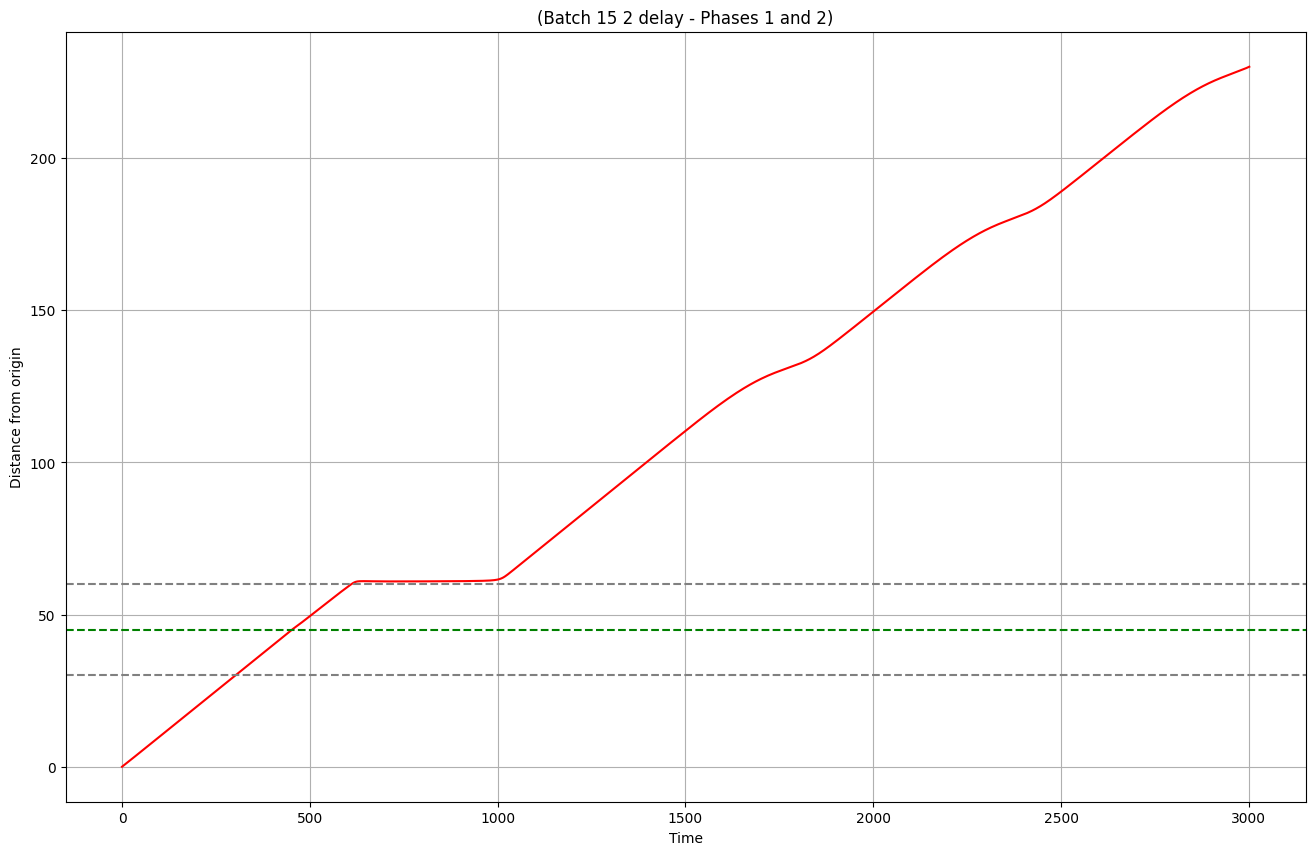

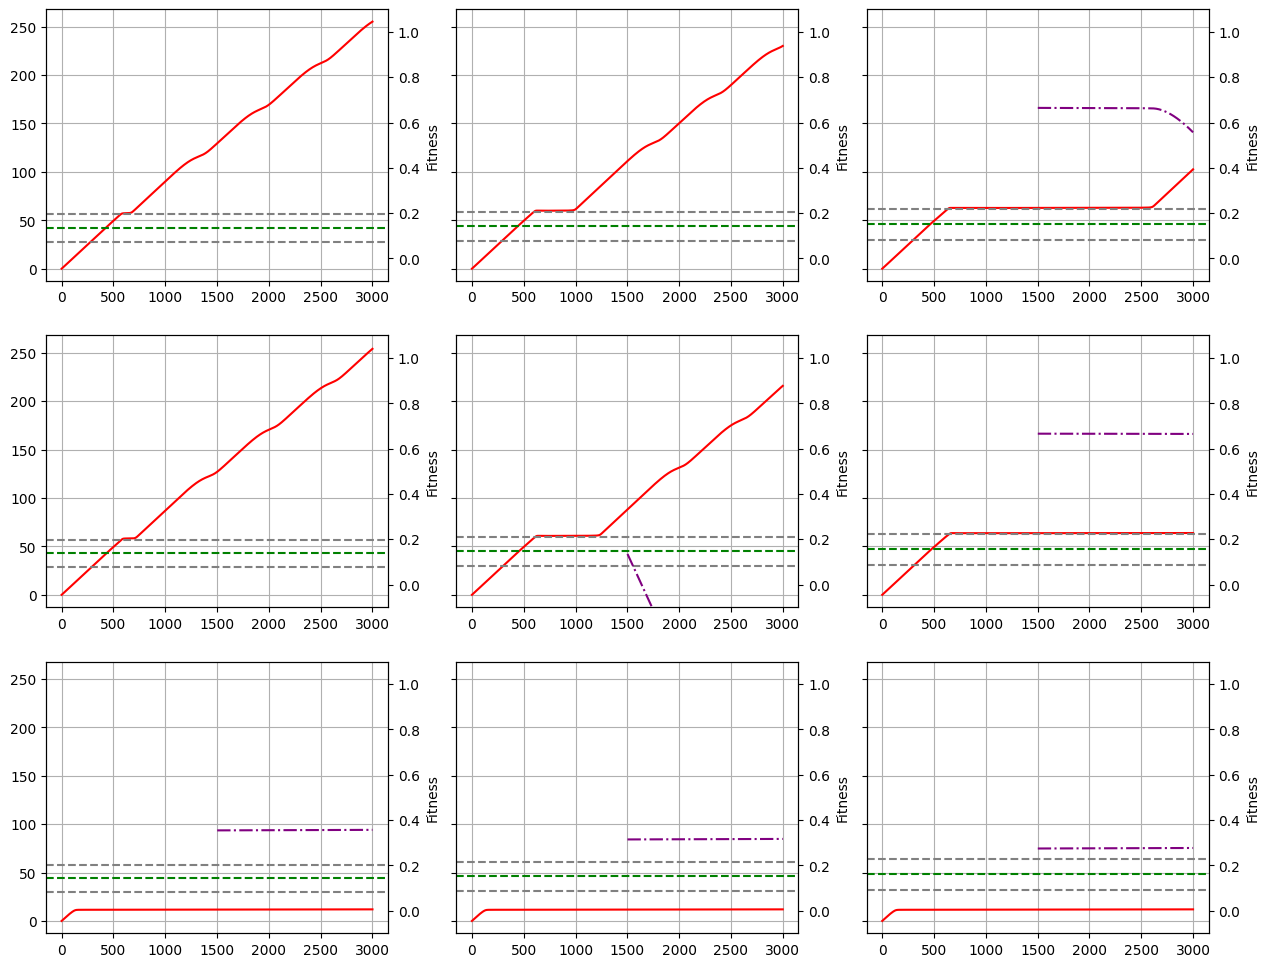

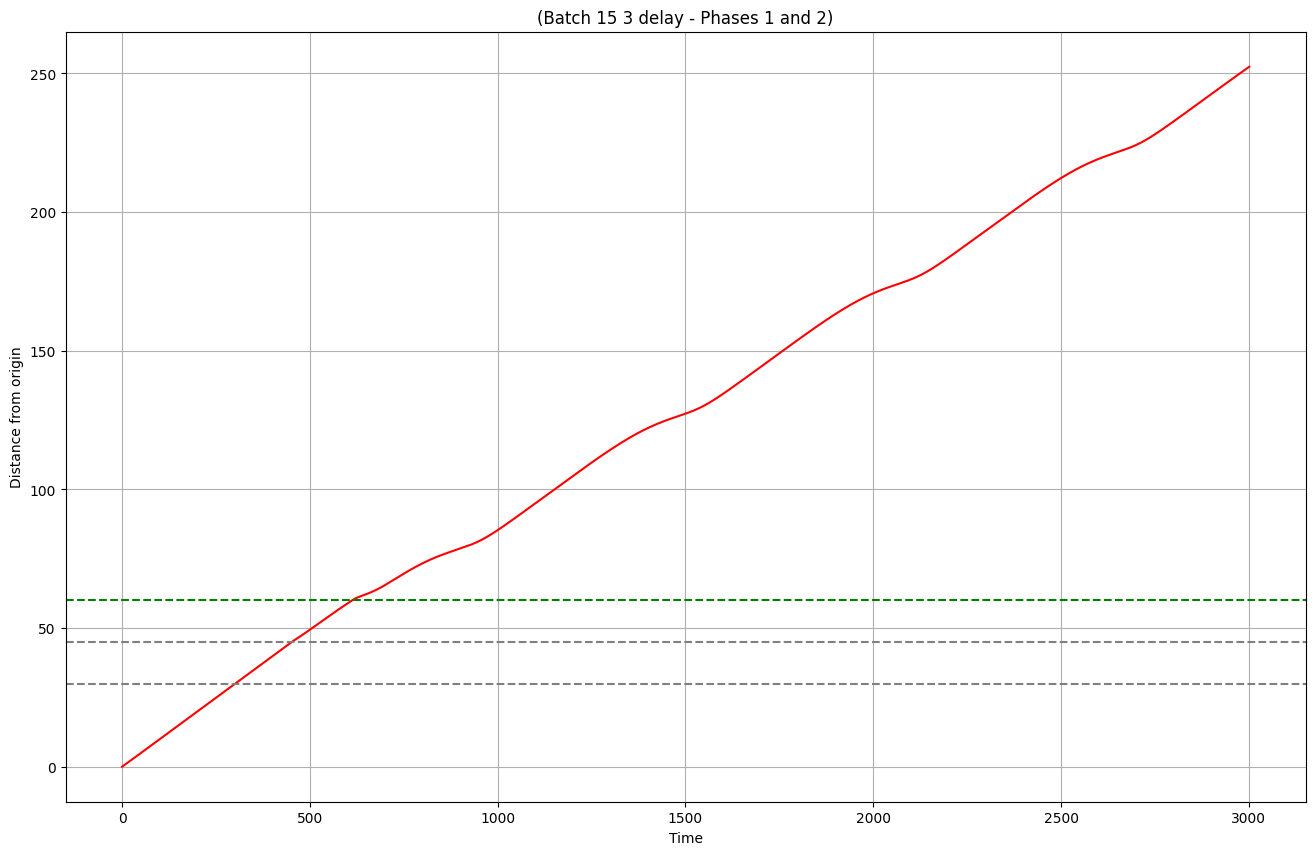

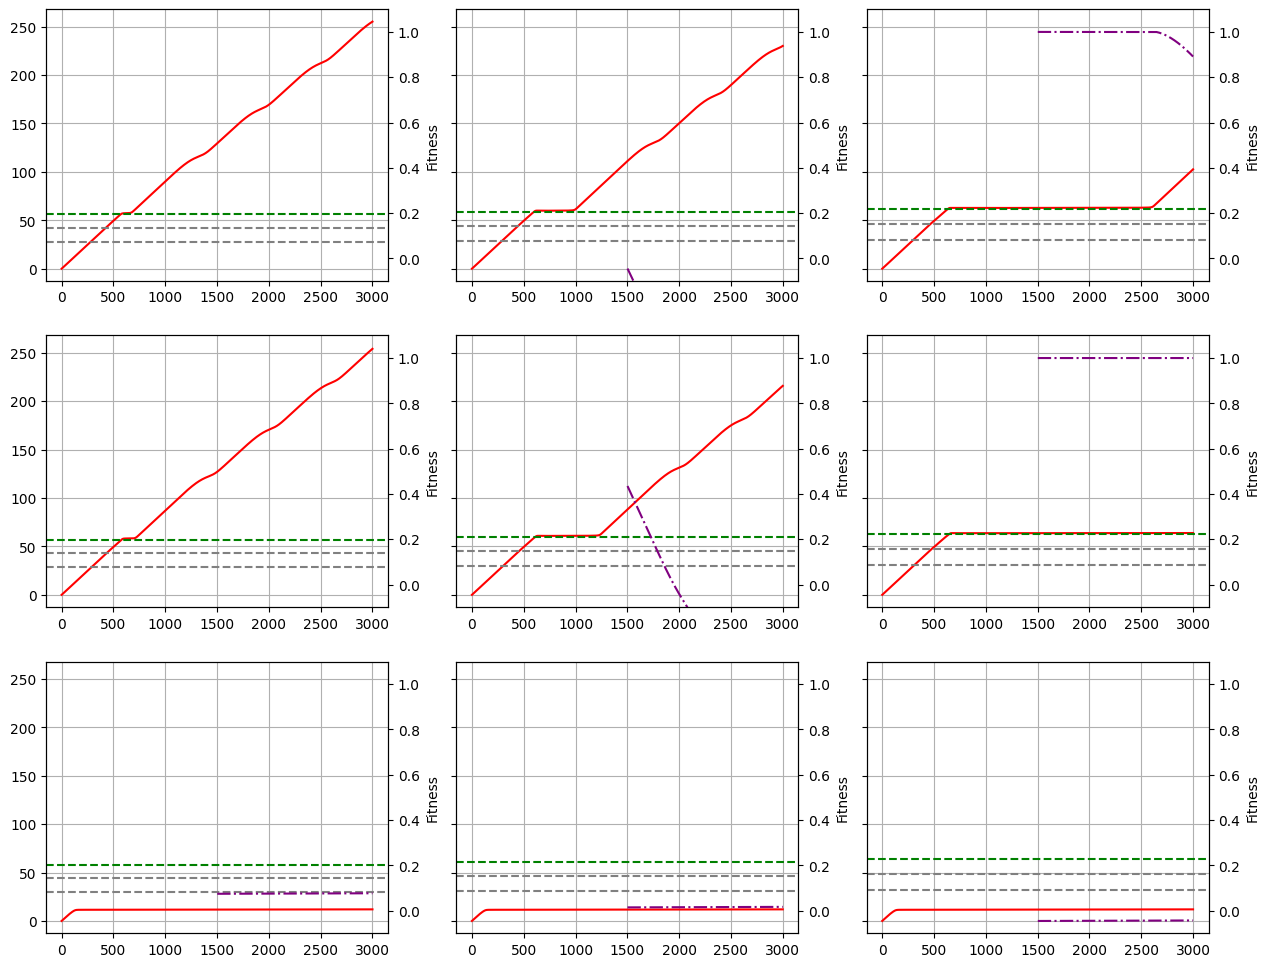

In [14]:
# training phase + pause behaviour
# this is looking at a single file
# phases = ["Phase1", "Phase2"]
phases = ["Phase3"]

delay = "delay"
envs = [1,2,3]
stage = "stage2"

run = 0

for batch_index, batch in enumerate(batches):
    for env in envs:
        fig, ax = plt.subplots(figsize=(16,10))
        # first plot phase 1 and phase 2 in the same plot
        phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase1.dat"
        phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{delay}_{stage}_Phase2.dat"
        combined = []
        combined.extend(read_ith_line(1, phase1_dir))
        combined.extend(read_ith_line(1, phase2_dir))
        x = list(range(0, len(combined)))
        ax.plot(x, combined, label=f"Agent", color="red")

        landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_env{env}_{stage}_phase2.dat"
        landmark = read_ith_line(1, landmark_file)
        food = landmark[3]
        landmarks = [0,1,2]
        for i in landmarks:
            if (i != env-1):
                ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
            else:
                ax.axhline(y=landmark[i], linestyle="--", label="Food Position", color="green")

        # plot it
        ax.set_xlabel("Time")
        ax.set_ylabel("Distance from origin")
        ax.set_title(f"(Batch {batch} {env} {delay} - Phases 1 and 2)")
        ax.grid(True)
        fig.show()


        # then plot phase 3 in a 3x3 grid
        fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

        phase3_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{delay}_{stage}_Phase3.dat"
        landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_env{env}_{stage}_phase3.dat"
        fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}_env{env}_{stage}_phase1.dat"

        counter = 1
        for x in range(0, 3):
            for y in range(0,3):
                ax = axes[x, y]
                ax2 = ax.twinx()
                
                # the behaviour
                behaviour = read_ith_line(counter, phase3_dir)
                behaviour_x = list(range(0, len(behaviour)))
                ax.plot(behaviour_x, behaviour, label=f"Agent", color="red")

                # the landmark
                landmark = read_ith_line(counter, landmark_file)
                food = landmark[3]
                landmarks = [0,1,2]
                for i in landmarks:
                    if (i != env-1):
                        ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
                    else:
                        ax.axhline(y=food, linestyle="--", label="Food Position", color="green")

                # fitness
                fitness = read_ith_line(counter, fitness_file)
                fitness_start = (len(behaviour) - len(fitness))
                fitness_x = range(fitness_start, len(fitness)+fitness_start)

                ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
                counter += 1

                ax2.set_ylim(bottom=-0.1, top=1.1)
                ax2.set_ylabel("Fitness")
                ax.grid(True)

                ax.set_title(f"") 
        fig.show()

# Part 4 - With the delay

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_35473/2068635035.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_35473/2068635035.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[26.0, 39.0, 52.0, 26.0]
[28.0, 43.0, 58.0, 28.0]
[30.0, 47.0, 64.0, 30.0]
[28.0, 41.0, 54.0, 28.0]
[30.0, 45.0, 60.0, 30.0]
[32.0, 49.0, 66.0, 32.0]
[30.0, 43.0, 56.0, 30.0]
[32.0, 47.0, 62.0, 32.0]
[34.0, 51.0, 68.0, 34.0]


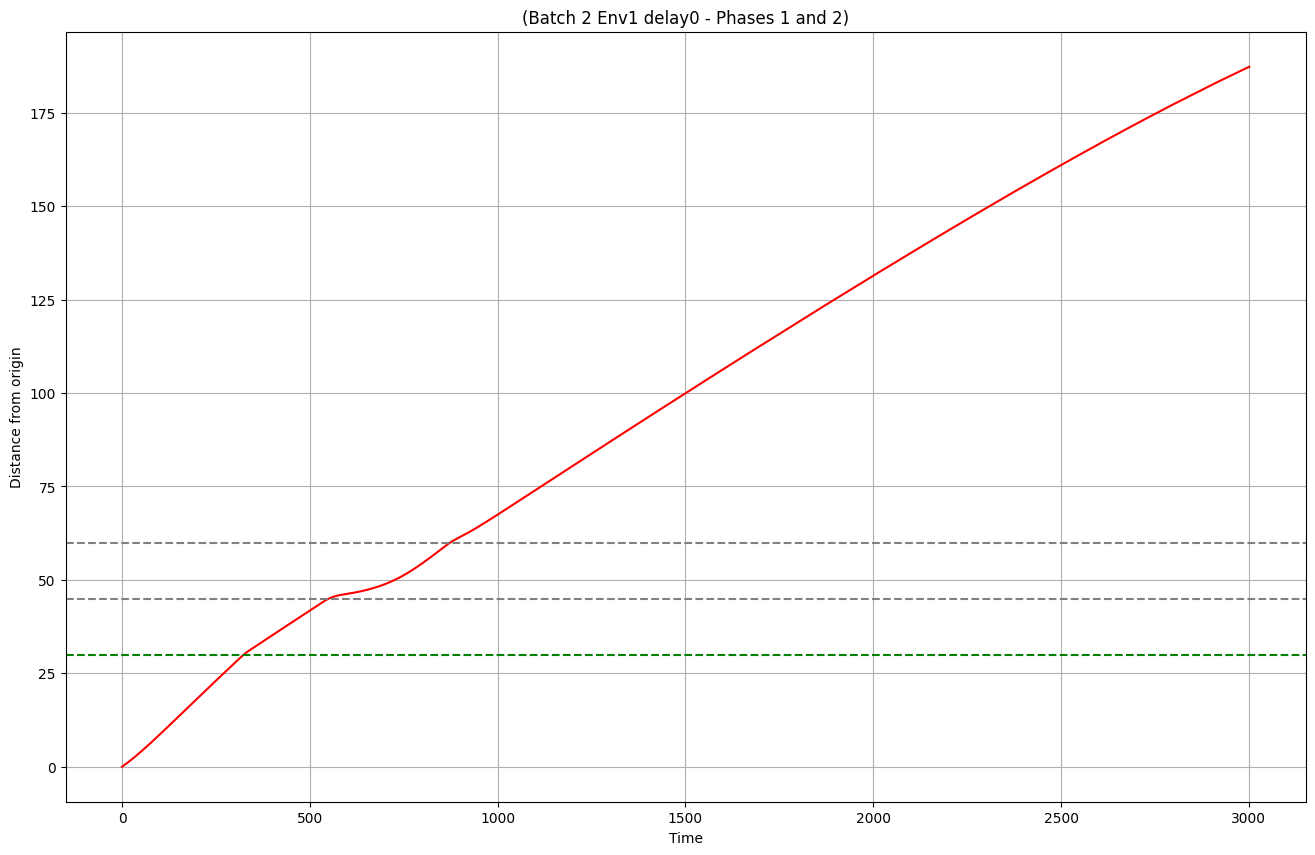

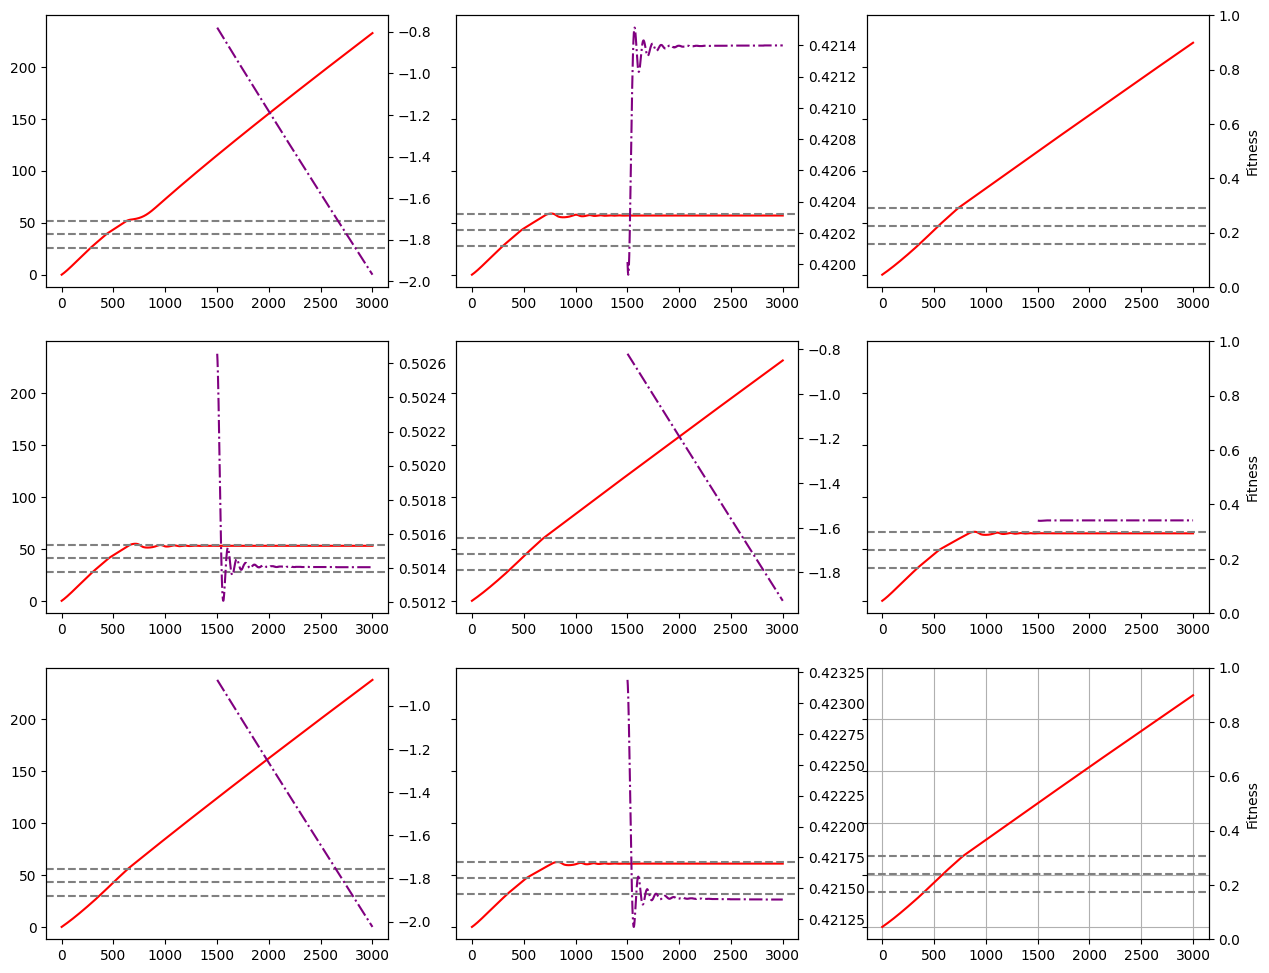

In [7]:
# the plot for a single run, batch and env with only one delay
batch = 2
delay = "delay0"
stage = "stage4"
run=0

env_behaviour="Env1"
env_other="env1"
env_index = 1
env_index=0
fig, ax = plt.subplots(figsize=(16,10))
# first plot phase 1 and phase 2 in the same plot
phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase1.dat"
phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase2.dat"
combined = []
combined.extend(read_ith_line(1, phase1_dir))
combined.extend(read_ith_line(1, phase2_dir))
x = list(range(0, len(combined)))
ax.plot(x, combined, label=f"Agent", color="red")

landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_{env_other}_{delay}_{stage}_phase2.dat"
landmark = read_ith_line(1, landmark_file)
food = landmark[3]
landmarks = [0,1,2]
for i in landmarks:
    if (landmark[i] != food):
        ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
ax.axhline(y=food, linestyle="--", label="Food Position", color="green")

# plot it
ax.set_xlabel("Time")
ax.set_ylabel("Distance from origin")
ax.set_title(f"(Batch {batch} {env_behaviour} {delay} - Phases 1 and 2)")
ax.grid(True)
fig.show()


# then plot phase 3 in a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

phase3_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase3.dat"
landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_{env_other}_{delay}_{stage}_phase3.dat"
fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}_{env_other}_{delay}_{stage}_phase1.dat"

counter = 1
for x in range(0, 3):
    for y in range(0,3):
        ax = axes[x, y]
        ax2 = ax.twinx()
        
        # the behaviour
        behaviour = read_ith_line(counter, phase3_dir)
        behaviour_x = list(range(0, len(behaviour)))
        ax.plot(behaviour_x, behaviour, label=f"Agent", color="red")

        # the landmark
        landmark = read_ith_line(counter, landmark_file)
        print(landmark)
        food = landmark[3]
        landmarks = [0,1,2]
        for i in landmarks:
            if (i != env_index-1):
                ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
            else:
                ax.axhline(y=landmark[i], linestyle="--", label="Food Position", color="green")

        # fitness
        fitness = read_ith_line(counter, fitness_file)
        fitness_start = (len(behaviour) - len(fitness))
        fitness_x = range(fitness_start, len(fitness)+fitness_start)

        ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")

        counter += 1

    ax2.set_ylim(bottom=0, top=1)
    ax2.set_ylabel("Fitness")
ax.set_title(f"")
ax.grid(True)
fig.show()


/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_16264/4052002510.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_16264/4052002510.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[26.0, 39.0, 52.0, 26.0]
[28.0, 43.0, 58.0, 28.0]
[30.0, 47.0, 64.0, 30.0]
[28.0, 41.0, 54.0, 28.0]
[30.0, 45.0, 60.0, 30.0]
[32.0, 49.0, 66.0, 32.0]
[30.0, 43.0, 56.0, 30.0]
[32.0, 47.0, 62.0, 32.0]
[34.0, 51.0, 68.0, 34.0]
[26.0, 39.0, 52.0, 26.0]
[28.0, 43.0, 58.0, 28.0]
[30.0, 47.0, 64.0, 30.0]
[28.0, 41.0, 54.0, 28.0]
[30.0, 45.0, 60.0, 30.0]
[32.0, 49.0, 66.0, 32.0]
[30.0, 43.0, 56.0, 30.0]
[32.0, 47.0, 62.0, 32.0]
[34.0, 51.0, 68.0, 34.0]
[26.0, 39.0, 52.0, 26.0]
[28.0, 43.0, 58.0, 28.0]
[30.0, 47.0, 64.0, 30.0]
[28.0, 41.0, 54.0, 28.0]
[30.0, 45.0, 60.0, 30.0]
[32.0, 49.0, 66.0, 32.0]
[30.0, 43.0, 56.0, 30.0]
[32.0, 47.0, 62.0, 32.0]
[34.0, 51.0, 68.0, 34.0]
[26.0, 39.0, 52.0, 26.0]
[28.0, 43.0, 58.0, 28.0]
[30.0, 47.0, 64.0, 30.0]
[28.0, 41.0, 54.0, 28.0]
[30.0, 45.0, 60.0, 30.0]
[32.0, 49.0, 66.0, 32.0]
[30.0, 43.0, 56.0, 30.0]
[32.0, 47.0, 62.0, 32.0]
[34.0, 51.0, 68.0, 34.0]
[26.0, 39.0, 52.0, 26.0]
[28.0, 43.0, 58.0, 28.0]
[30.0, 47.0, 64.0, 30.0]
[28.0, 41.0, 54.0, 28.0]


/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_16264/4052002510.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(16,10))


[26.0, 39.0, 52.0, 26.0]
[28.0, 43.0, 58.0, 28.0]
[30.0, 47.0, 64.0, 30.0]
[28.0, 41.0, 54.0, 28.0]
[30.0, 45.0, 60.0, 30.0]
[32.0, 49.0, 66.0, 32.0]
[30.0, 43.0, 56.0, 30.0]
[32.0, 47.0, 62.0, 32.0]
[34.0, 51.0, 68.0, 34.0]


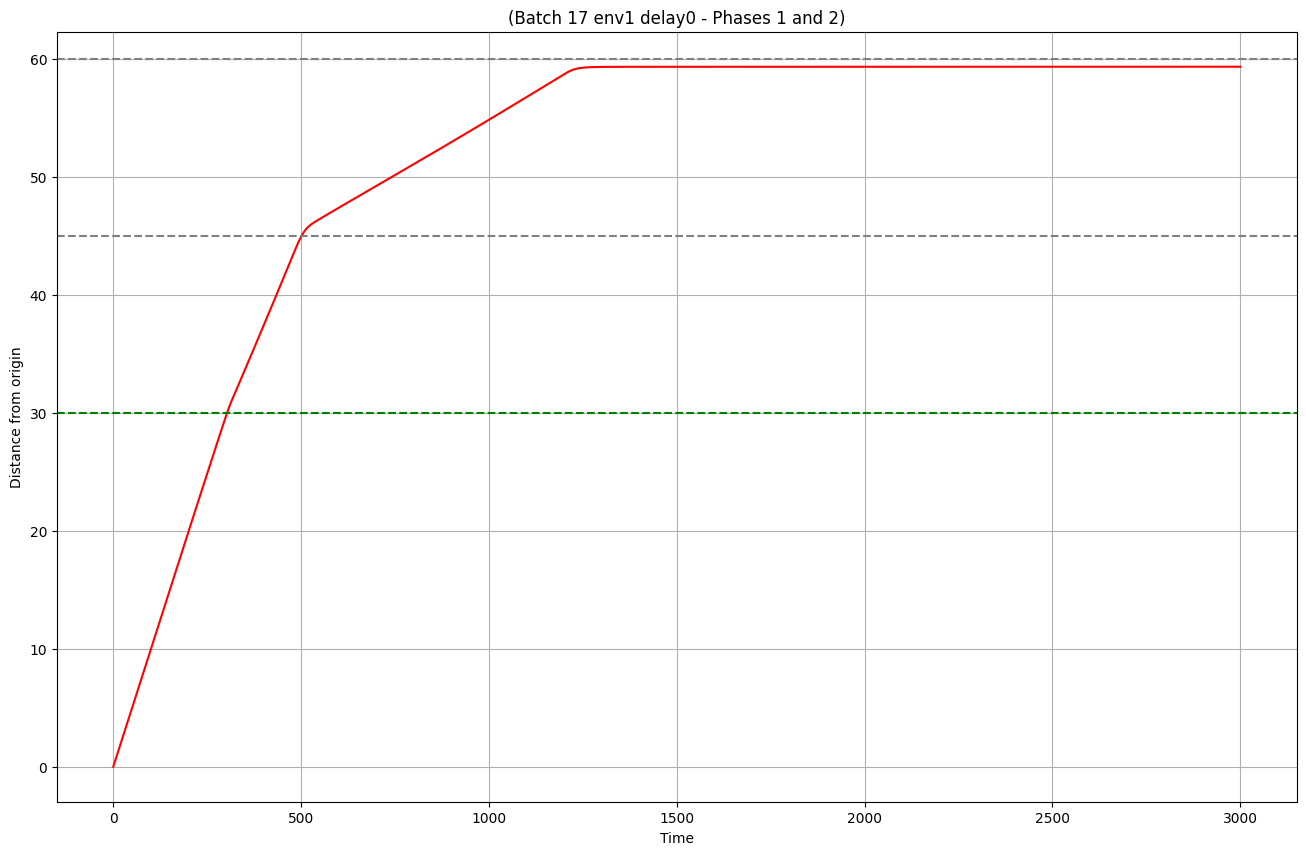

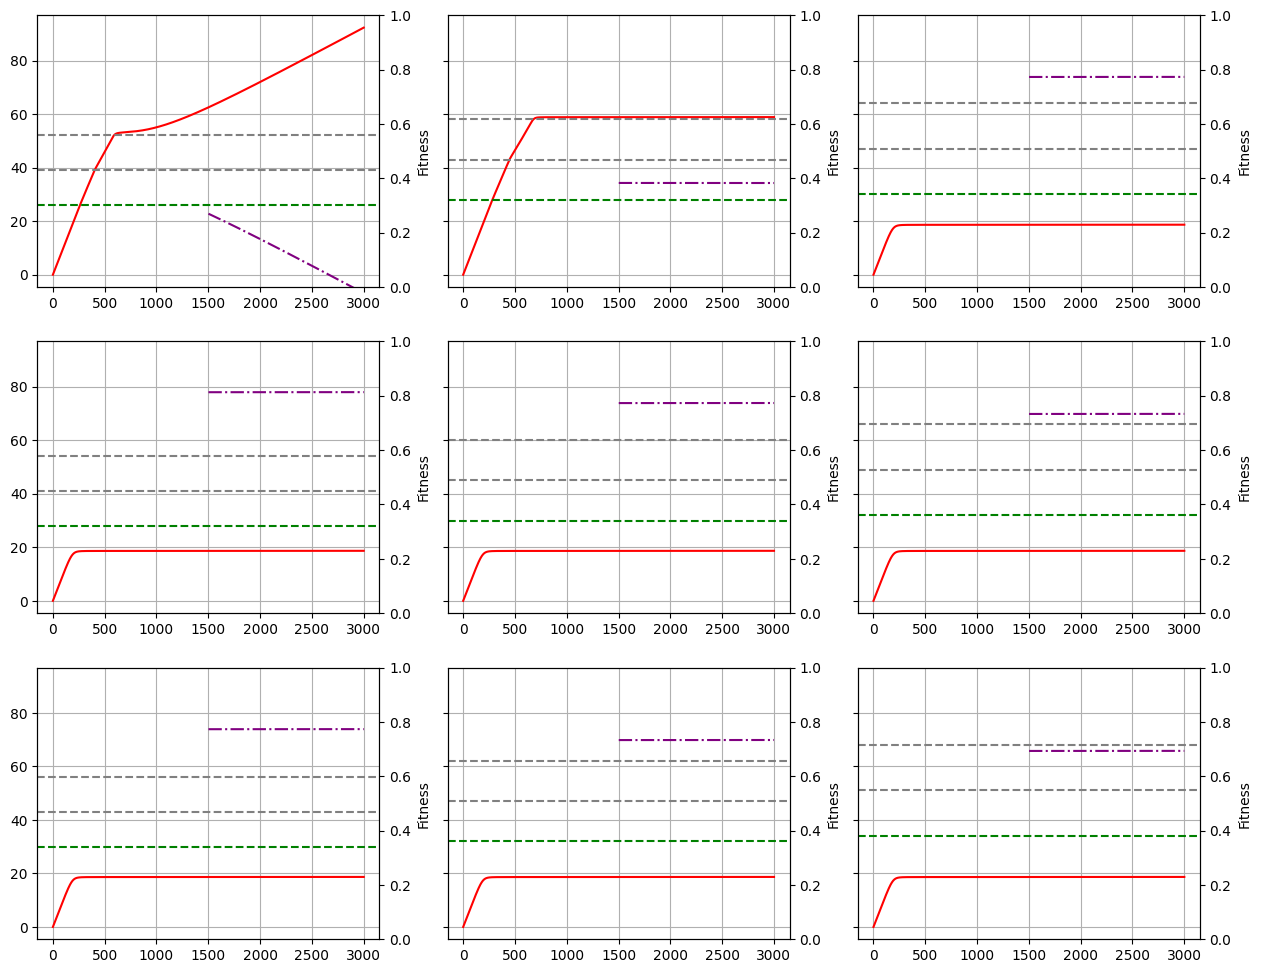

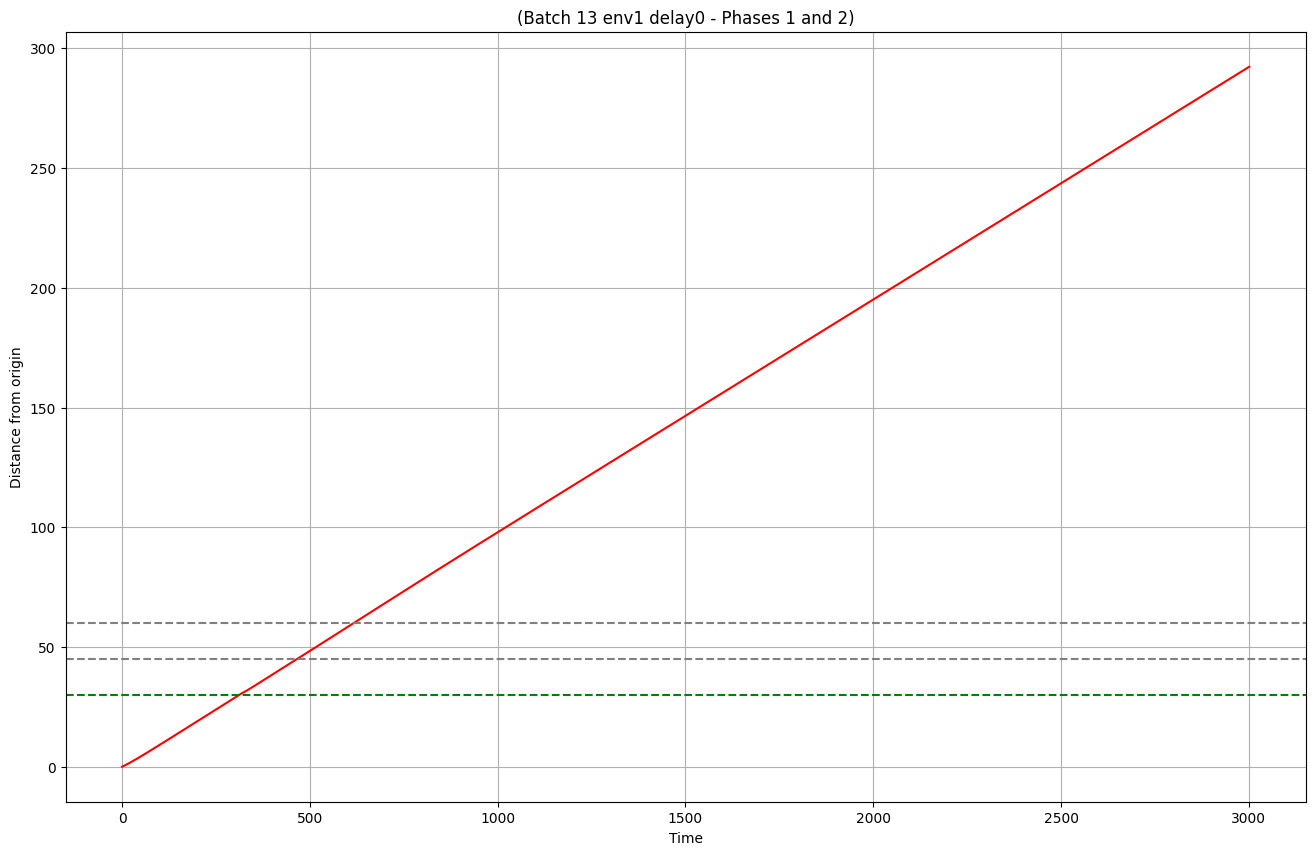

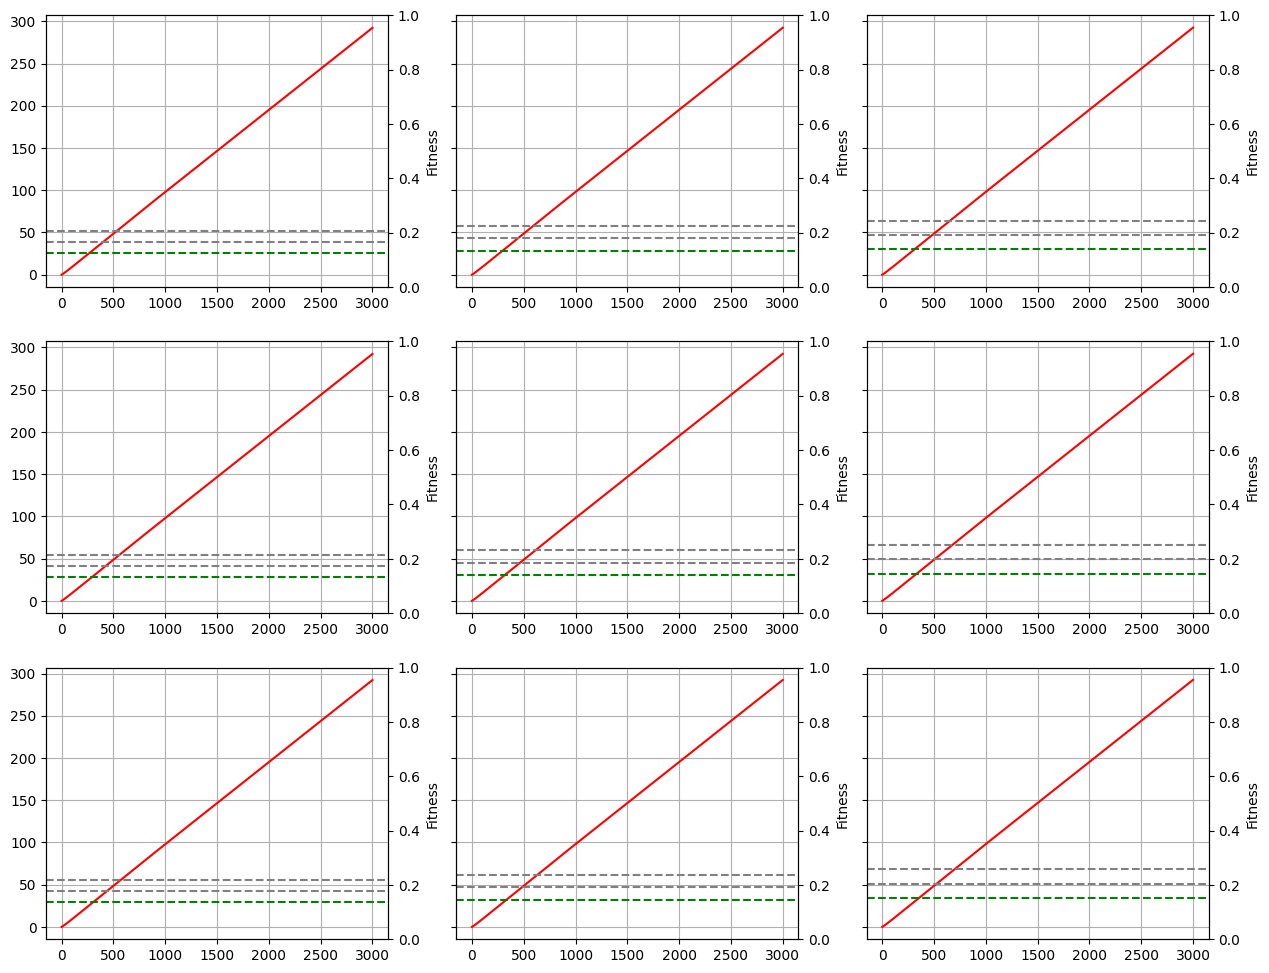

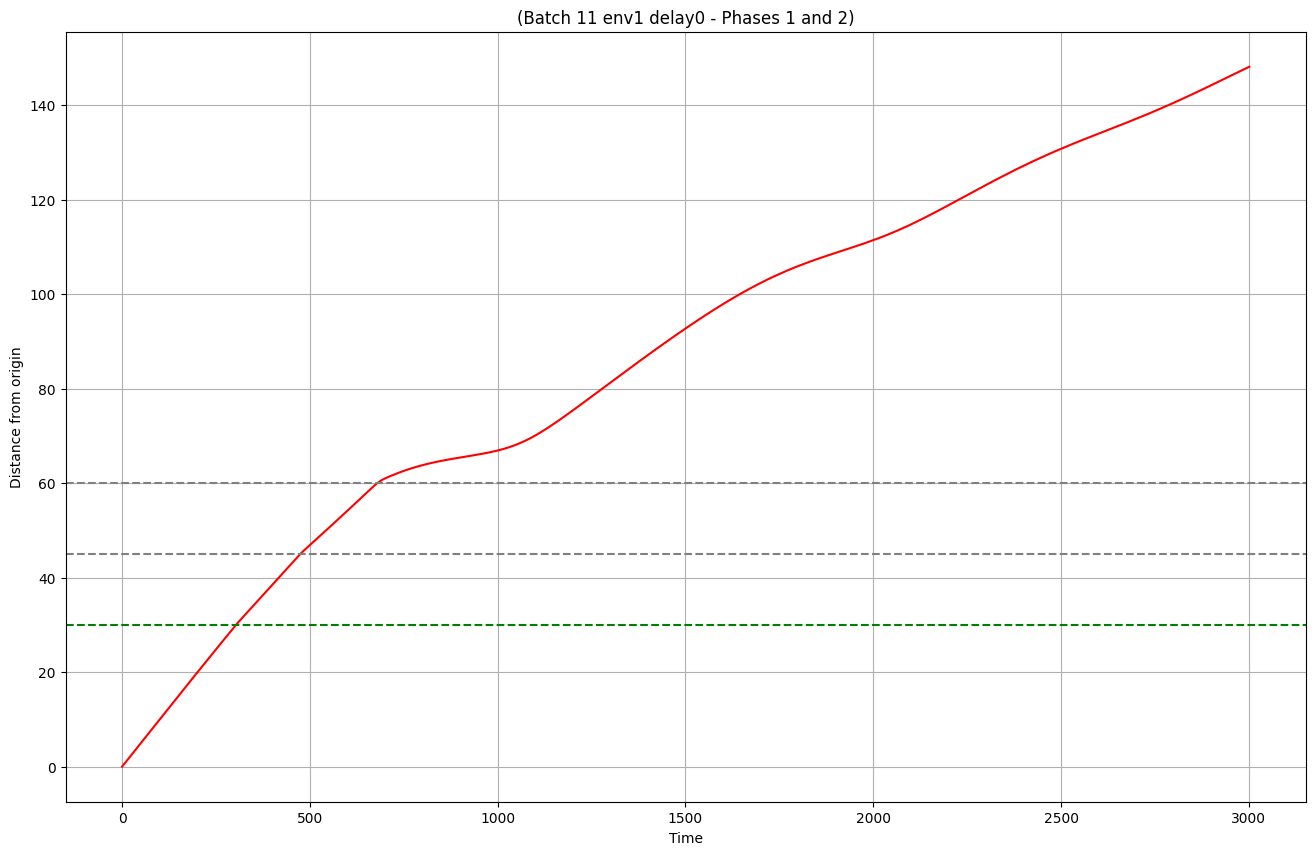

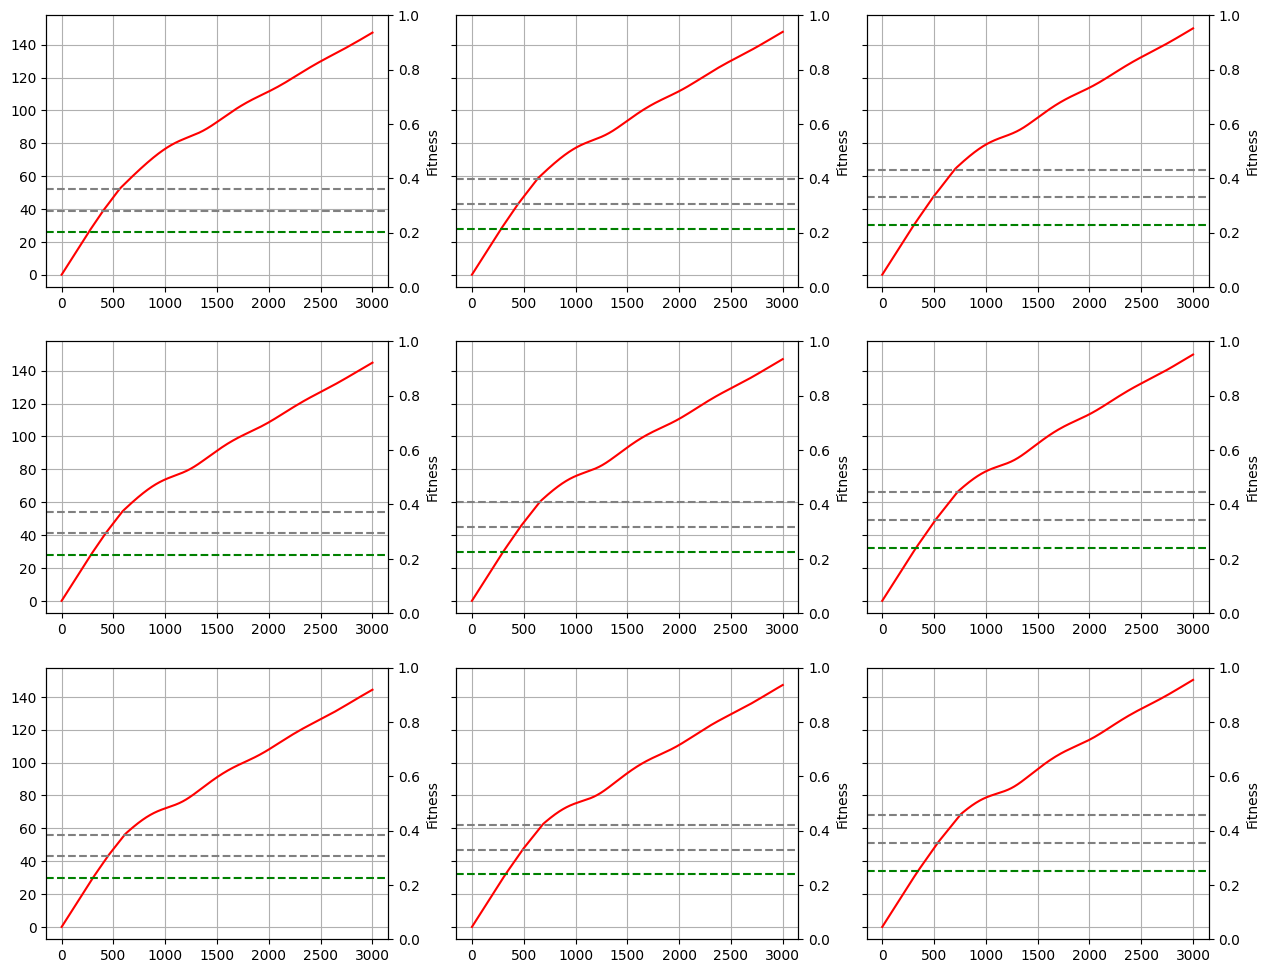

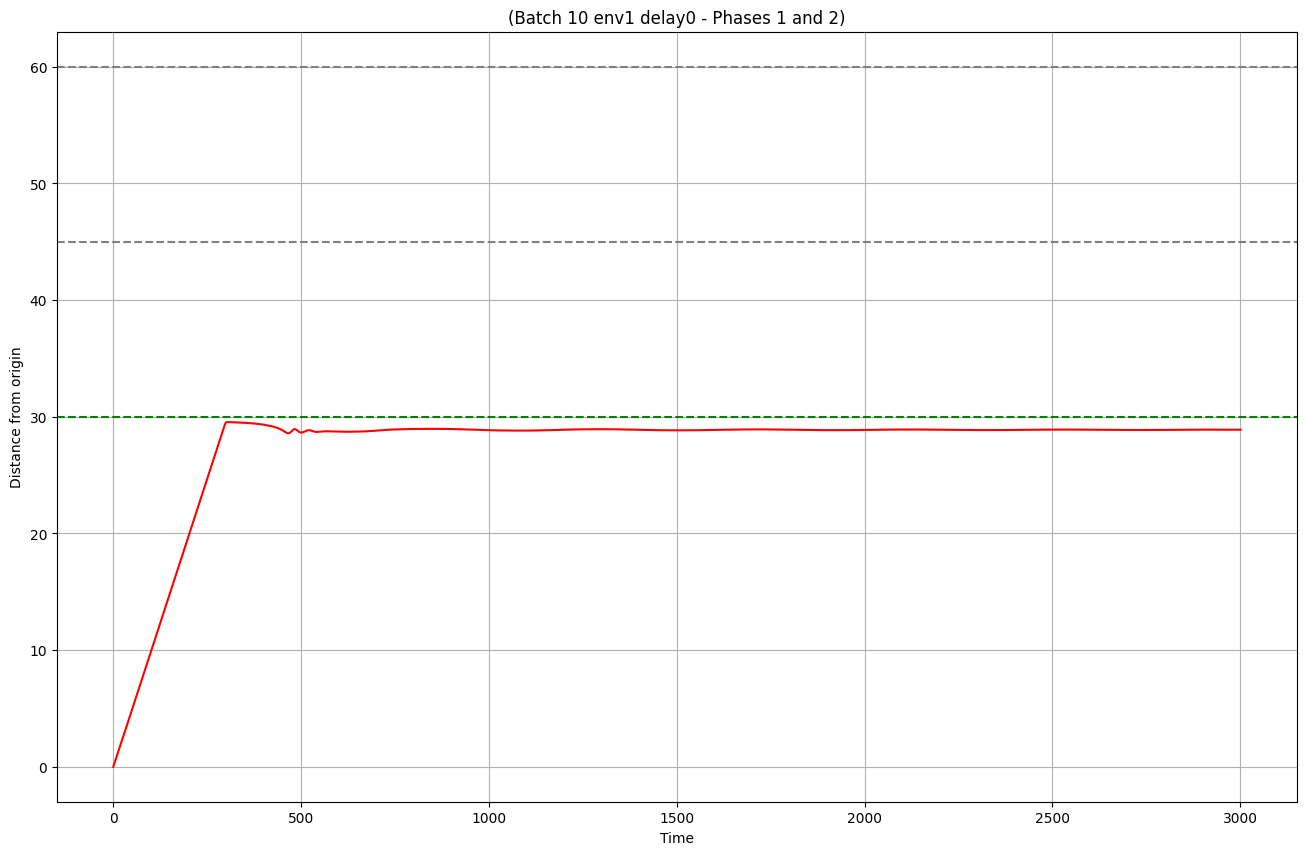

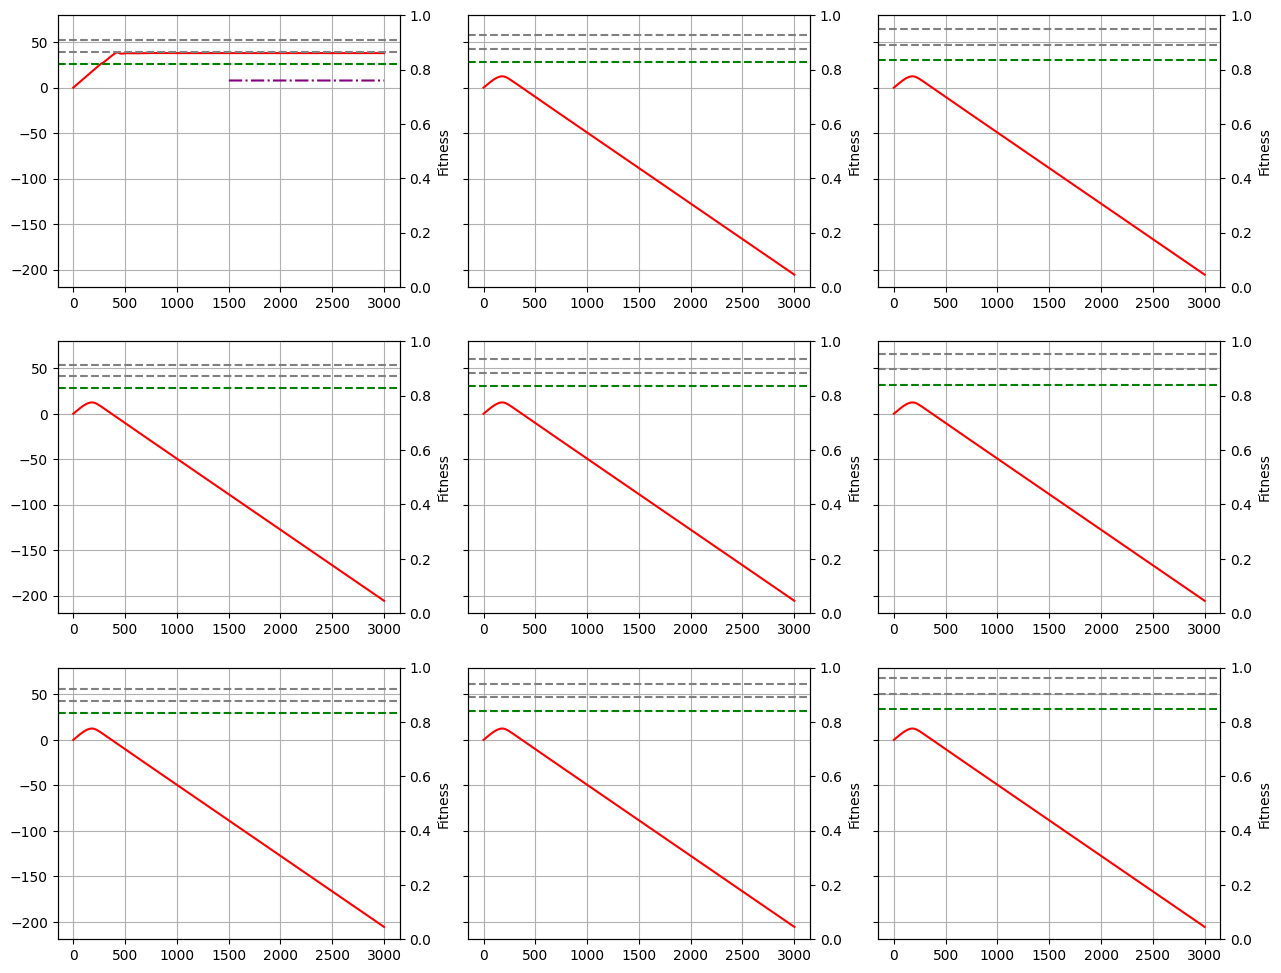

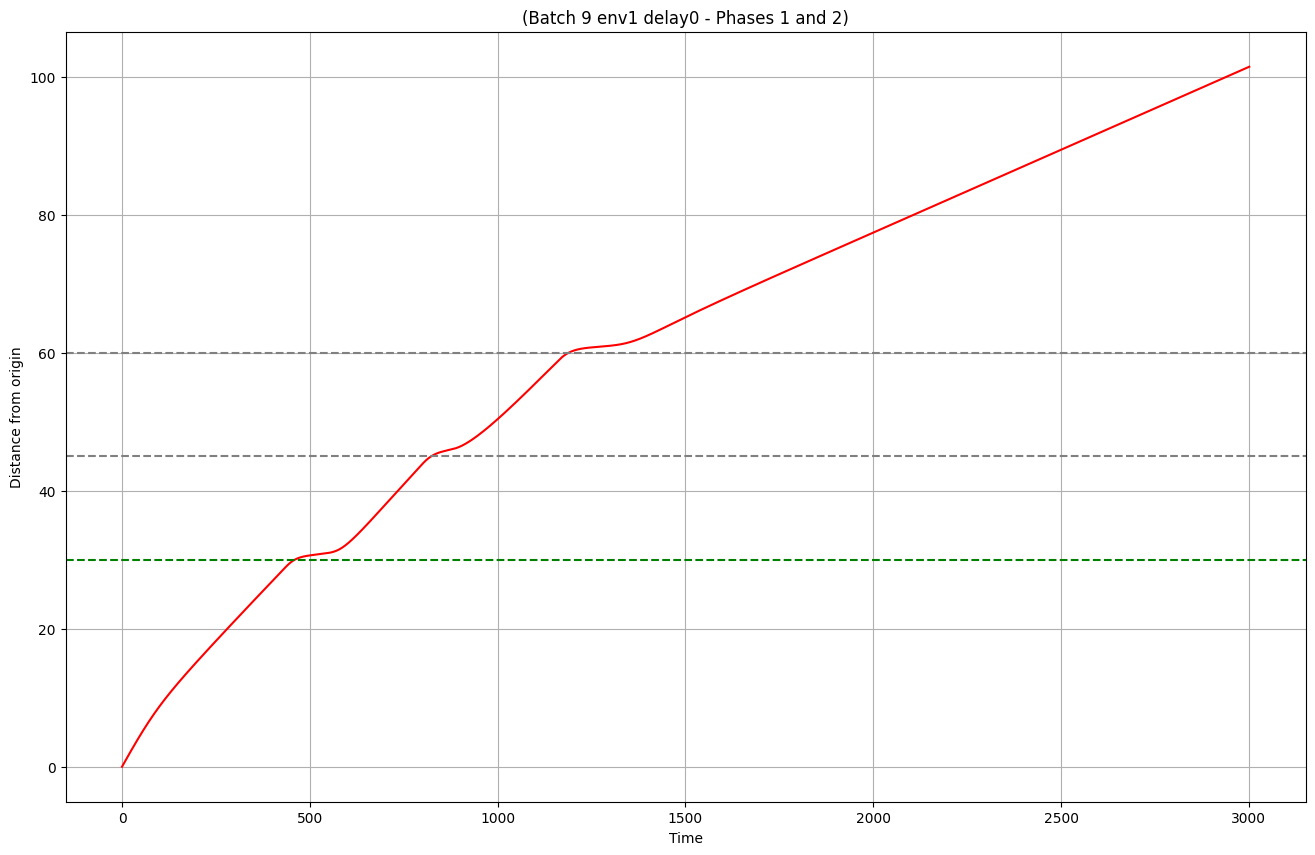

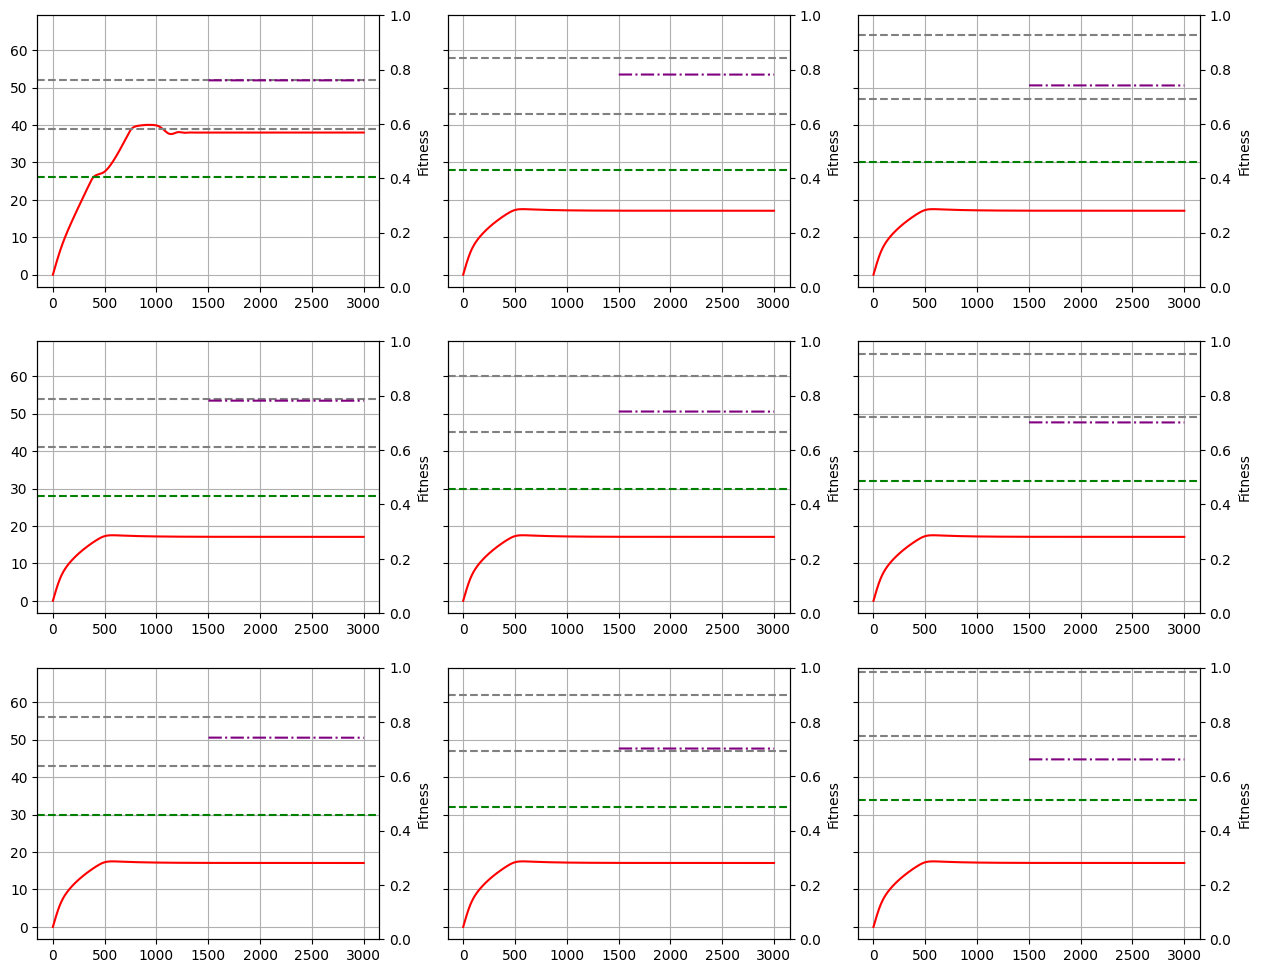

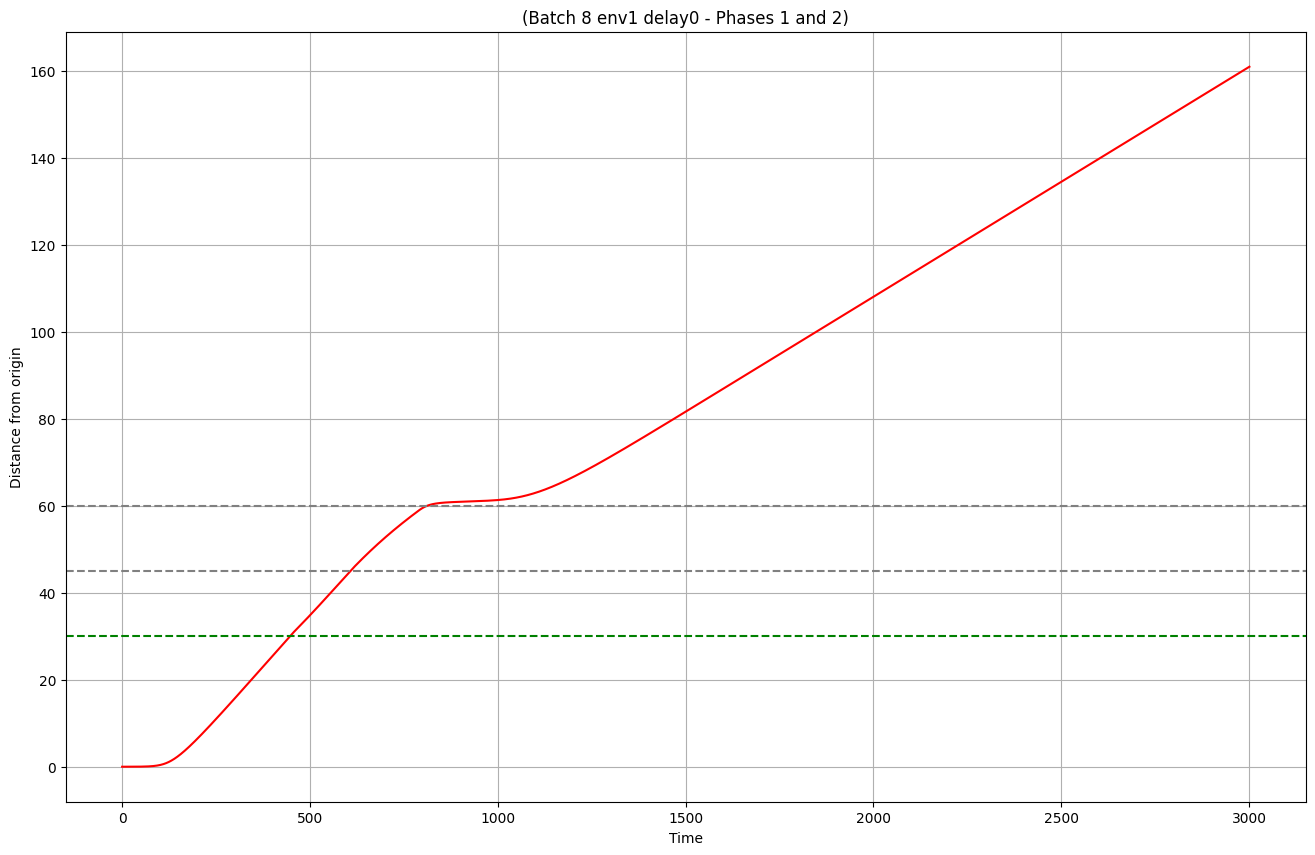

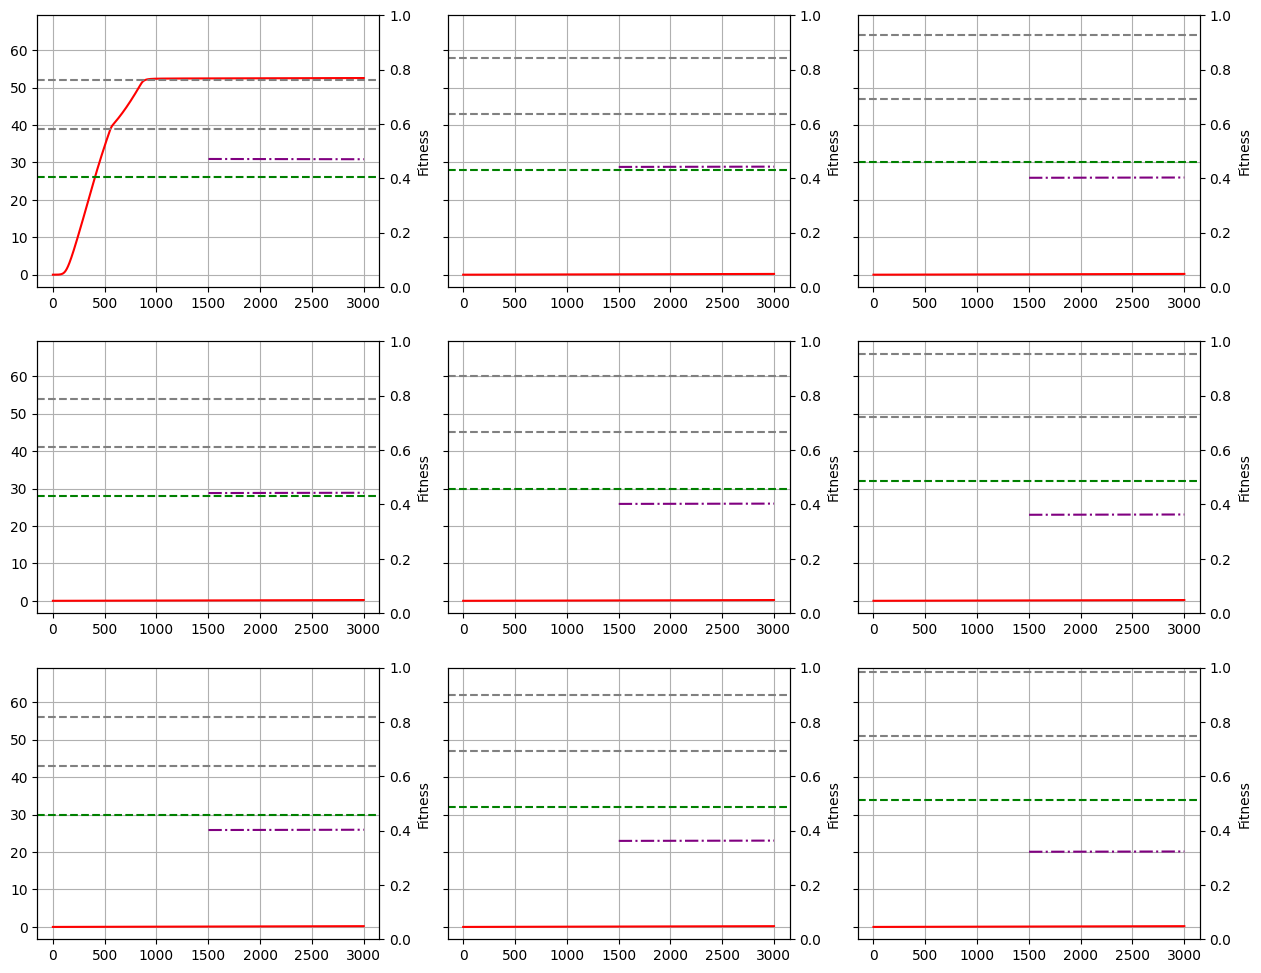

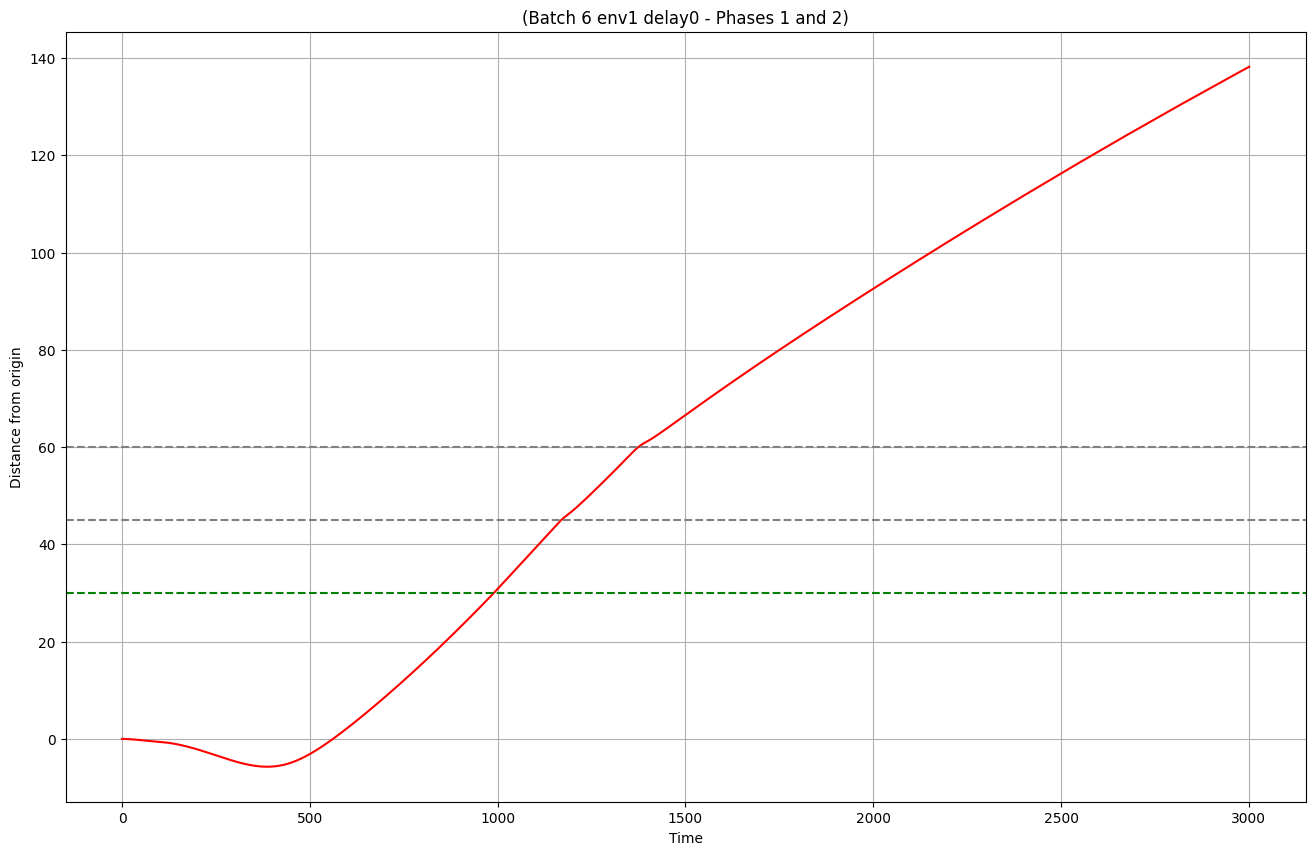

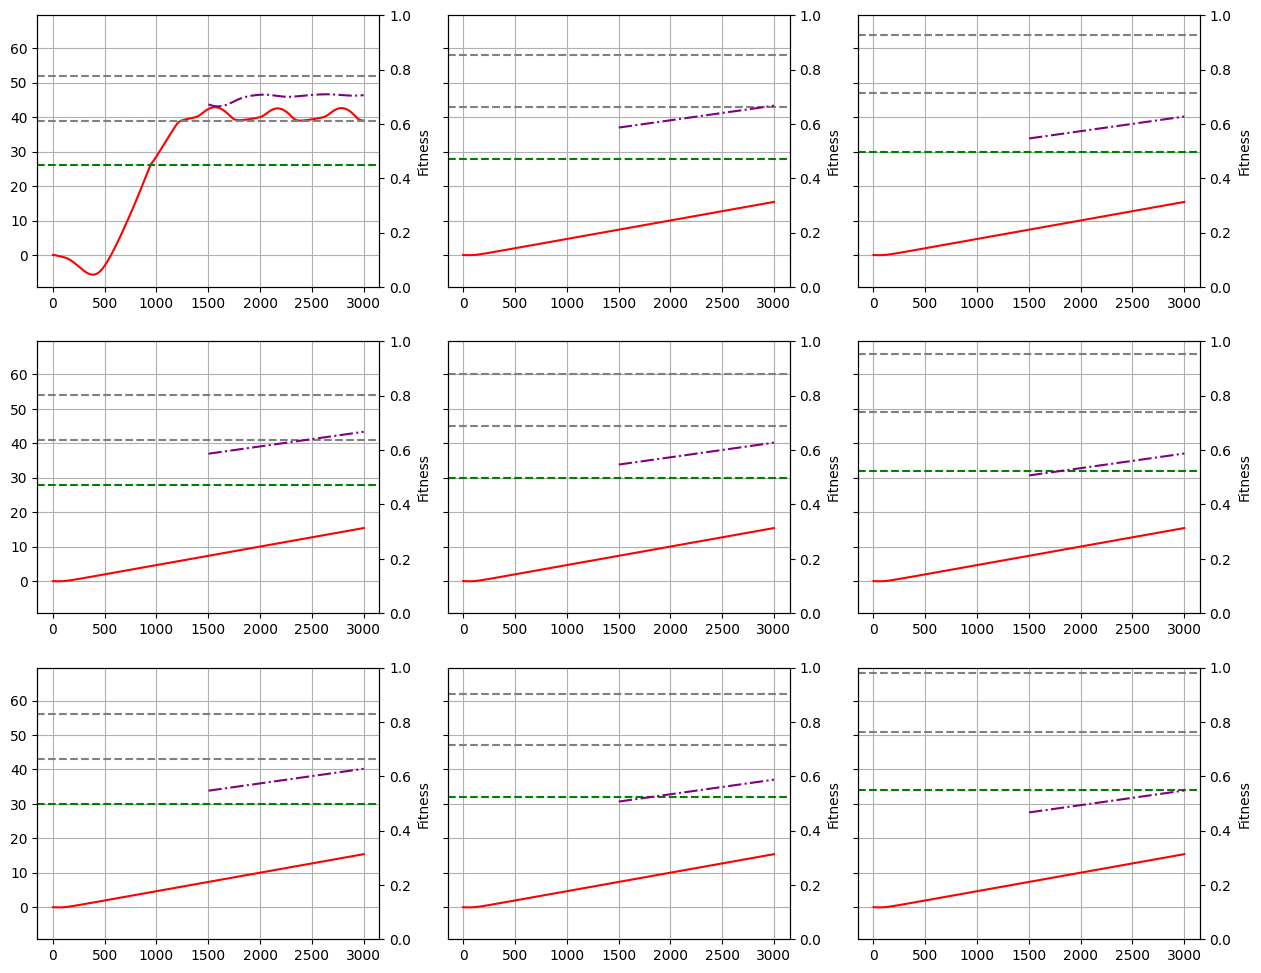

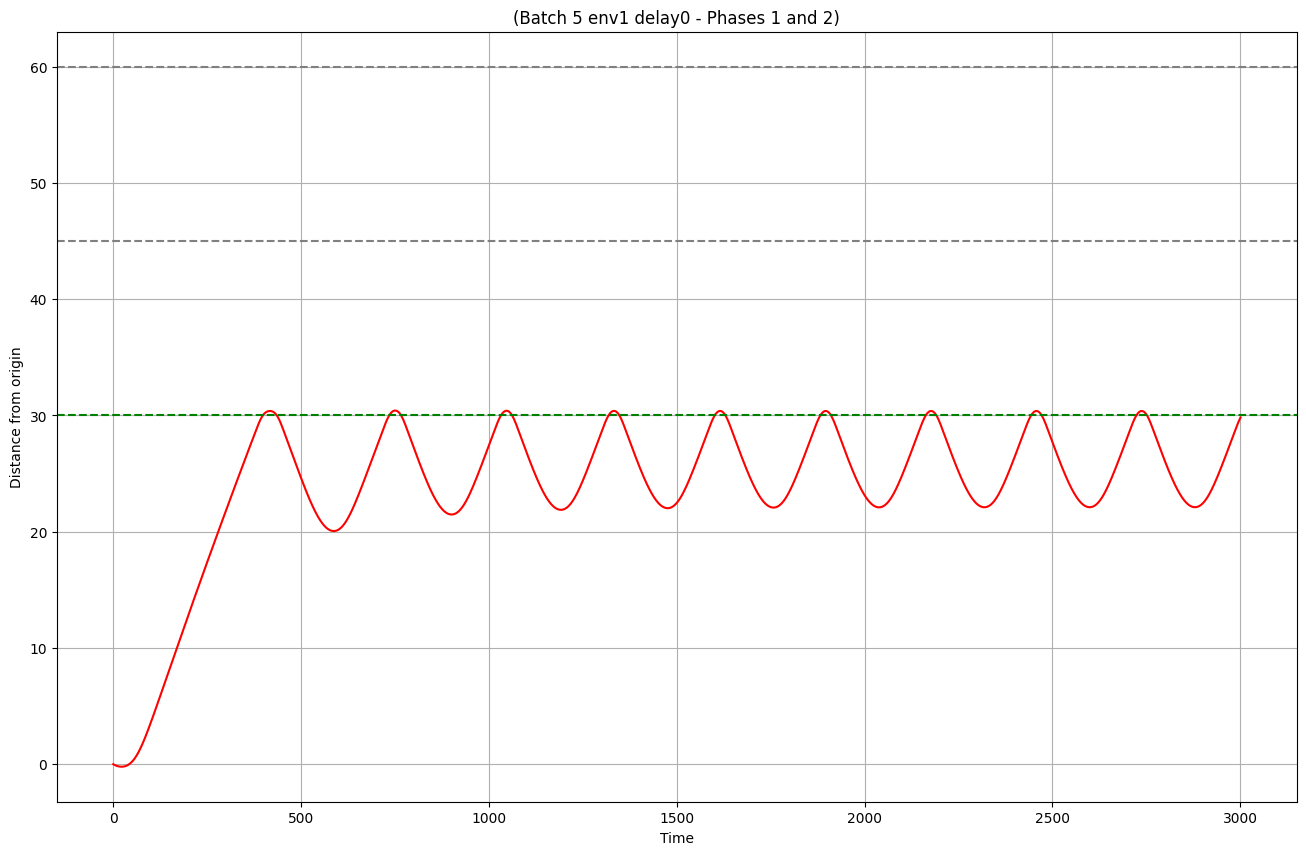

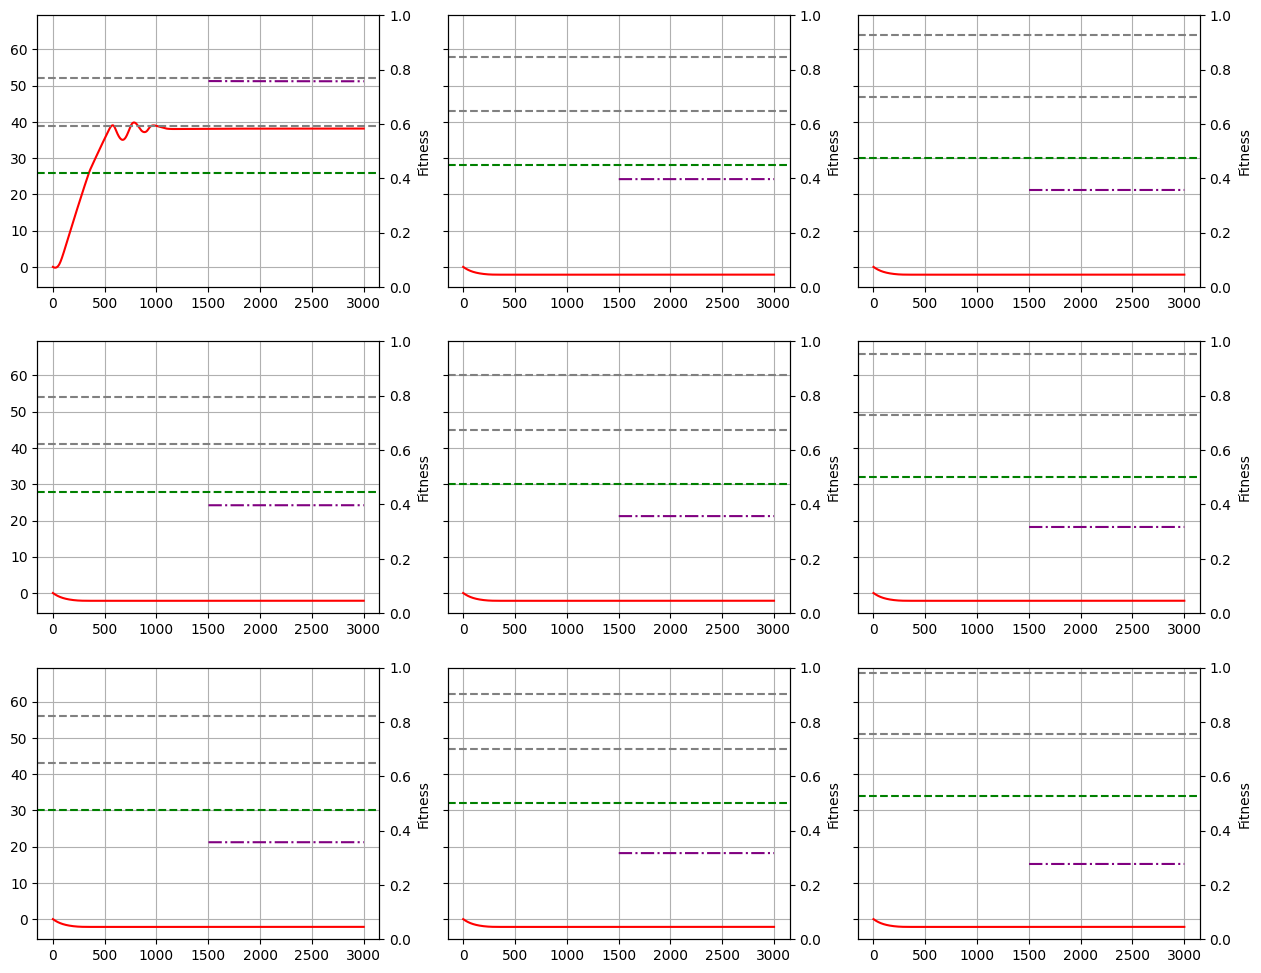

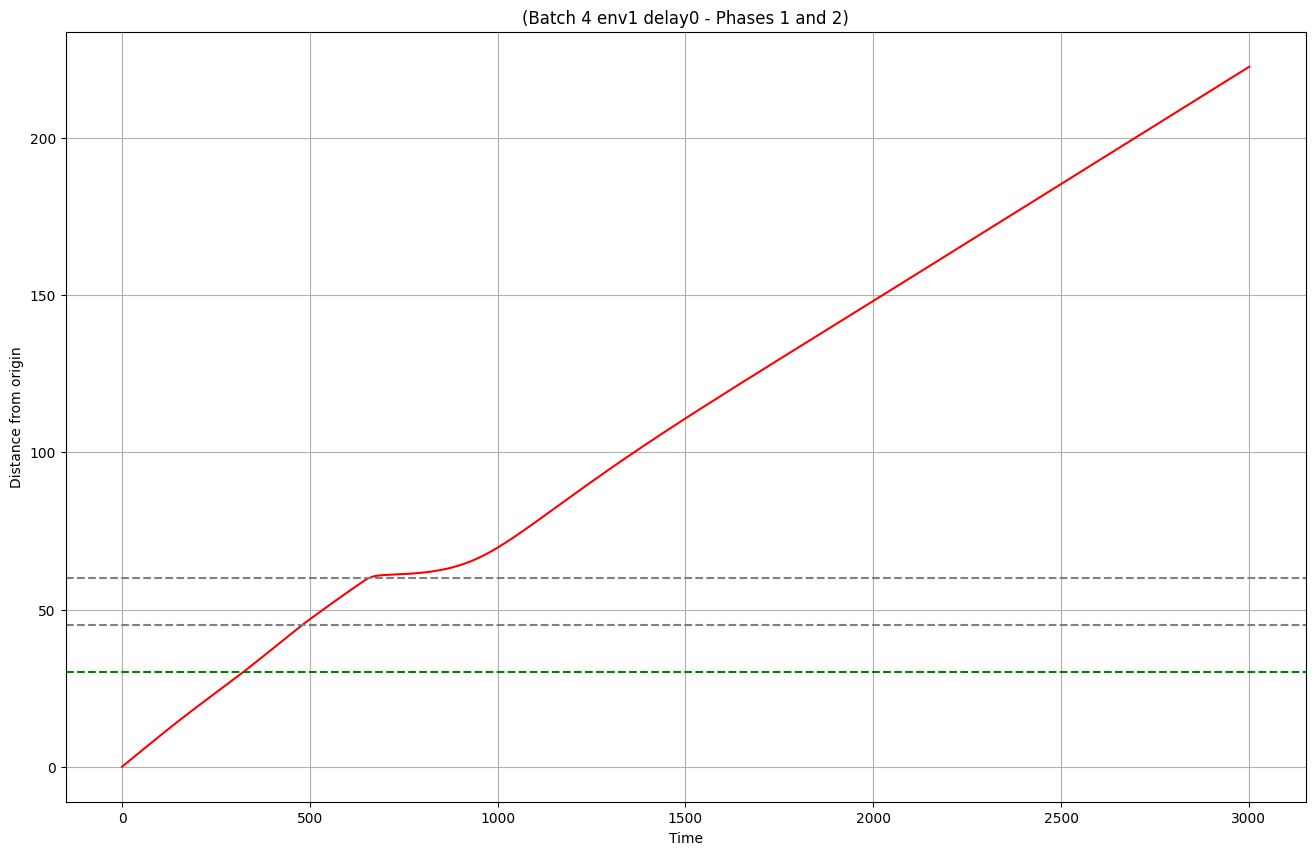

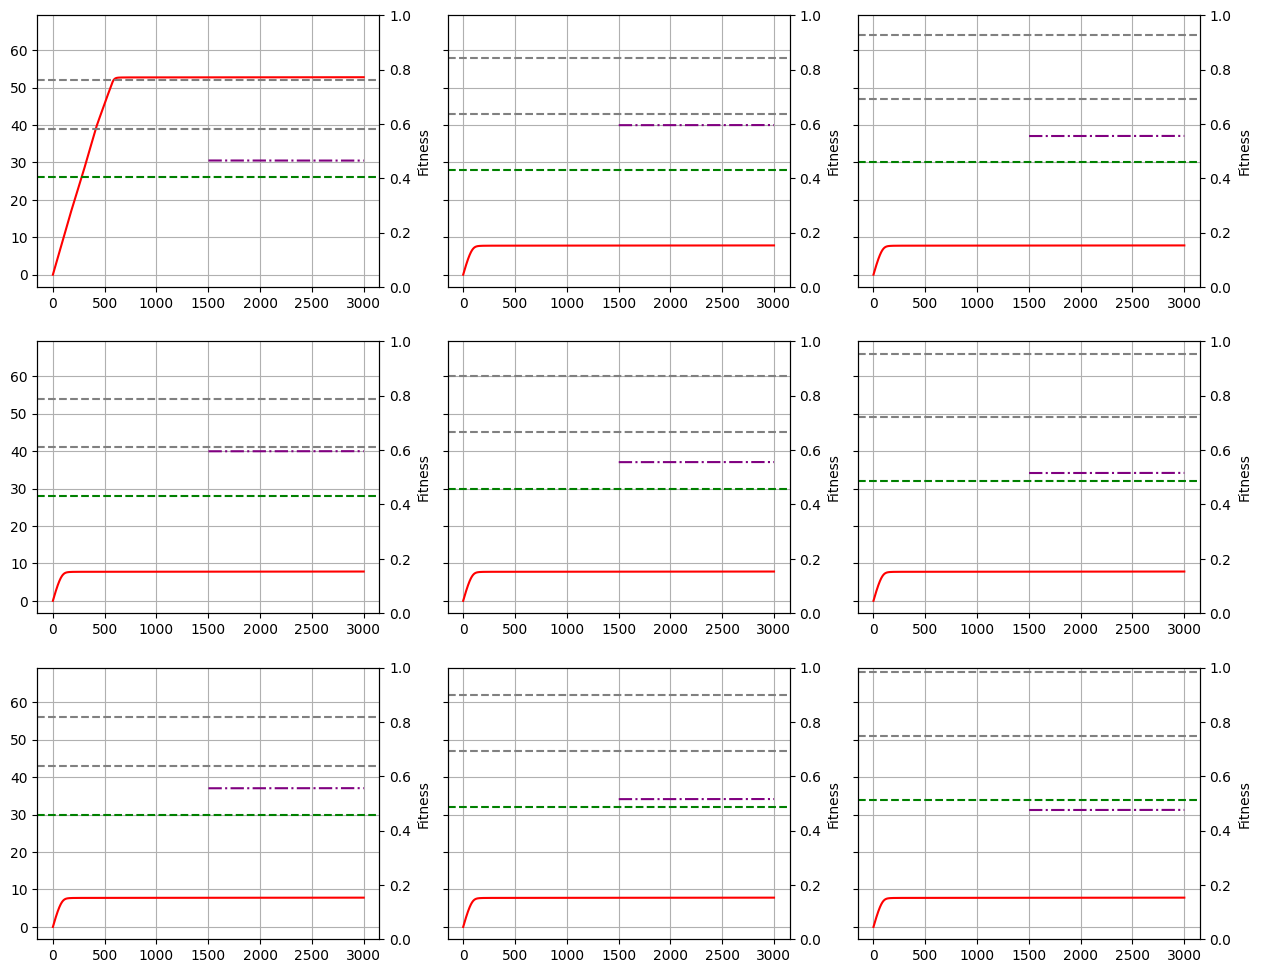

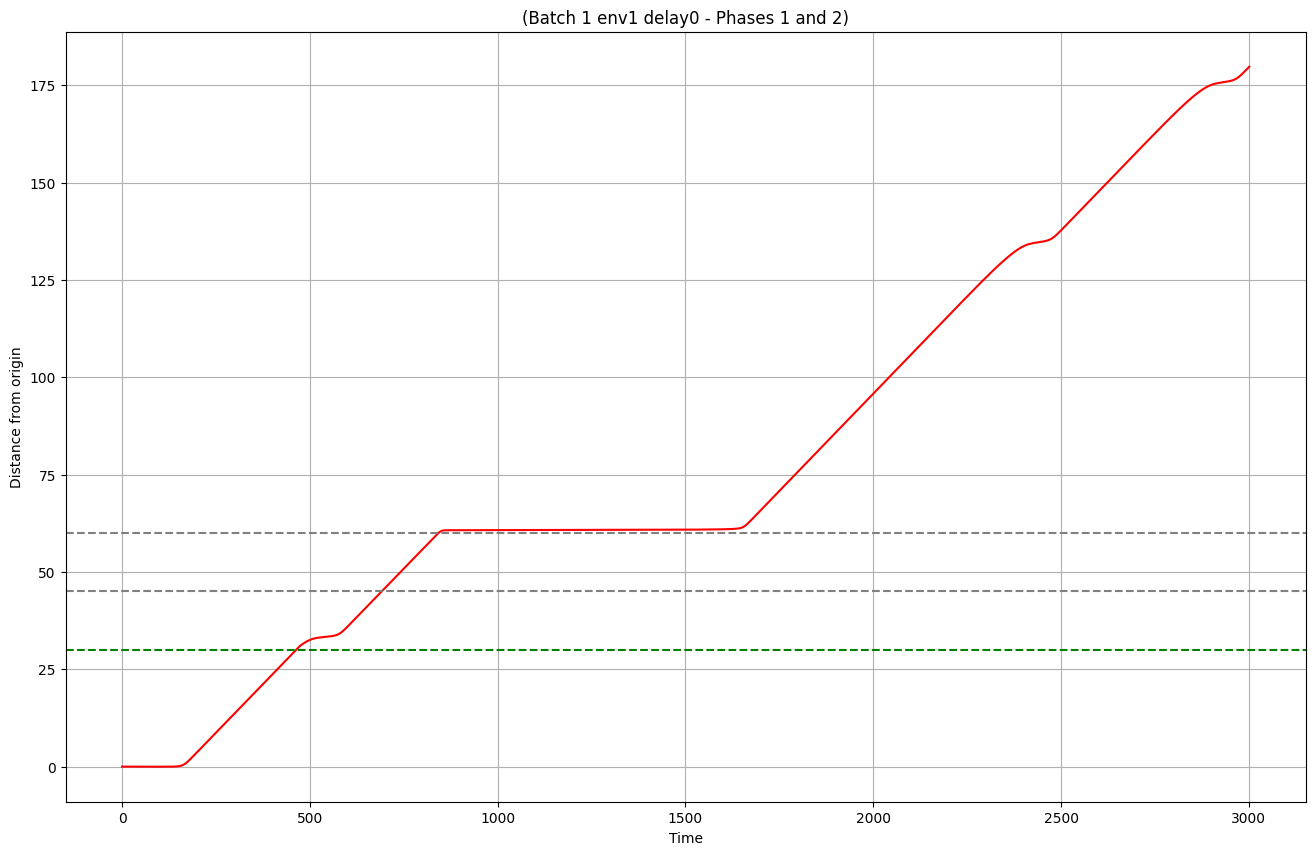

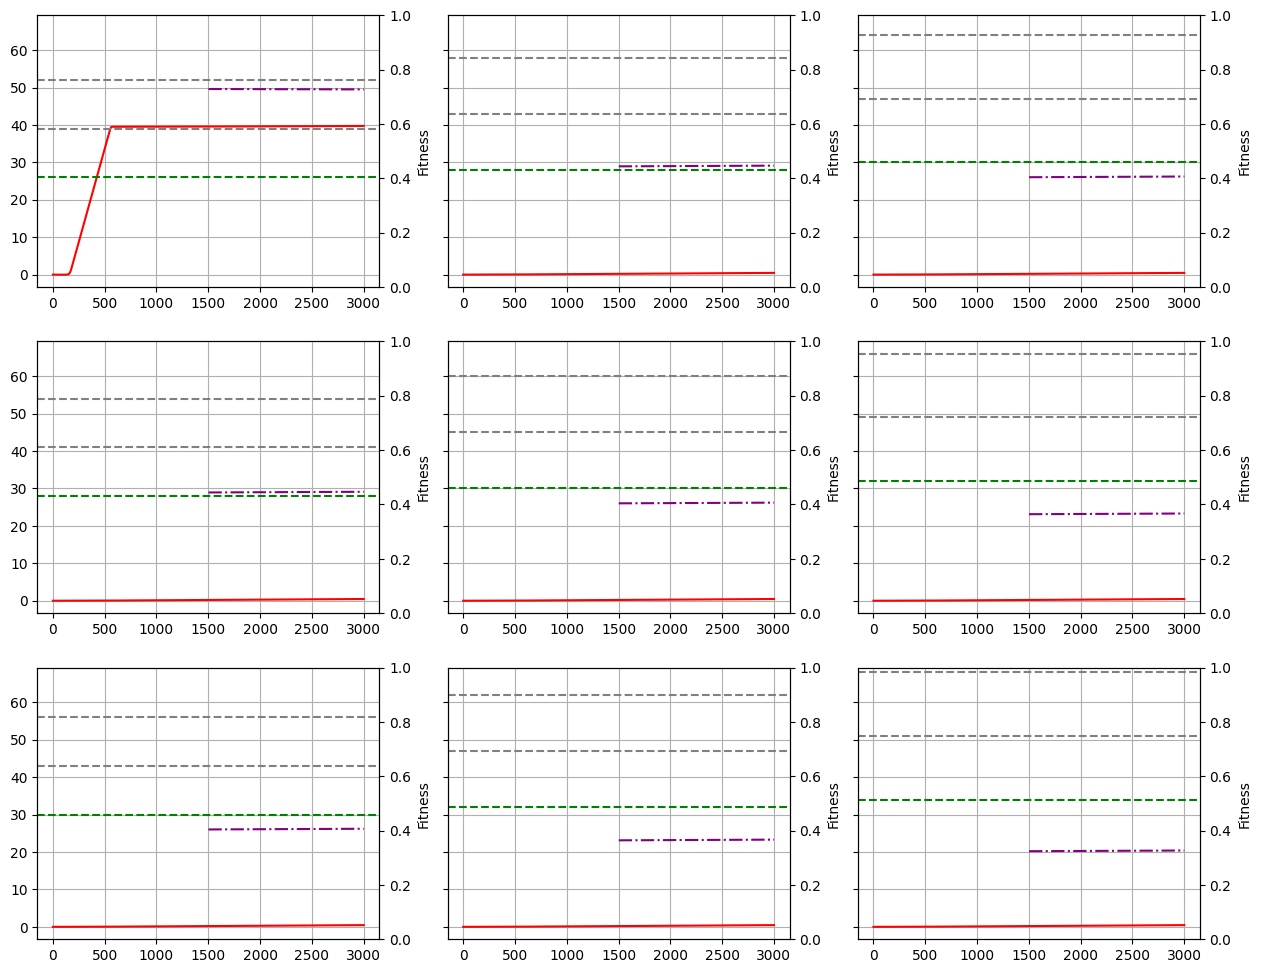

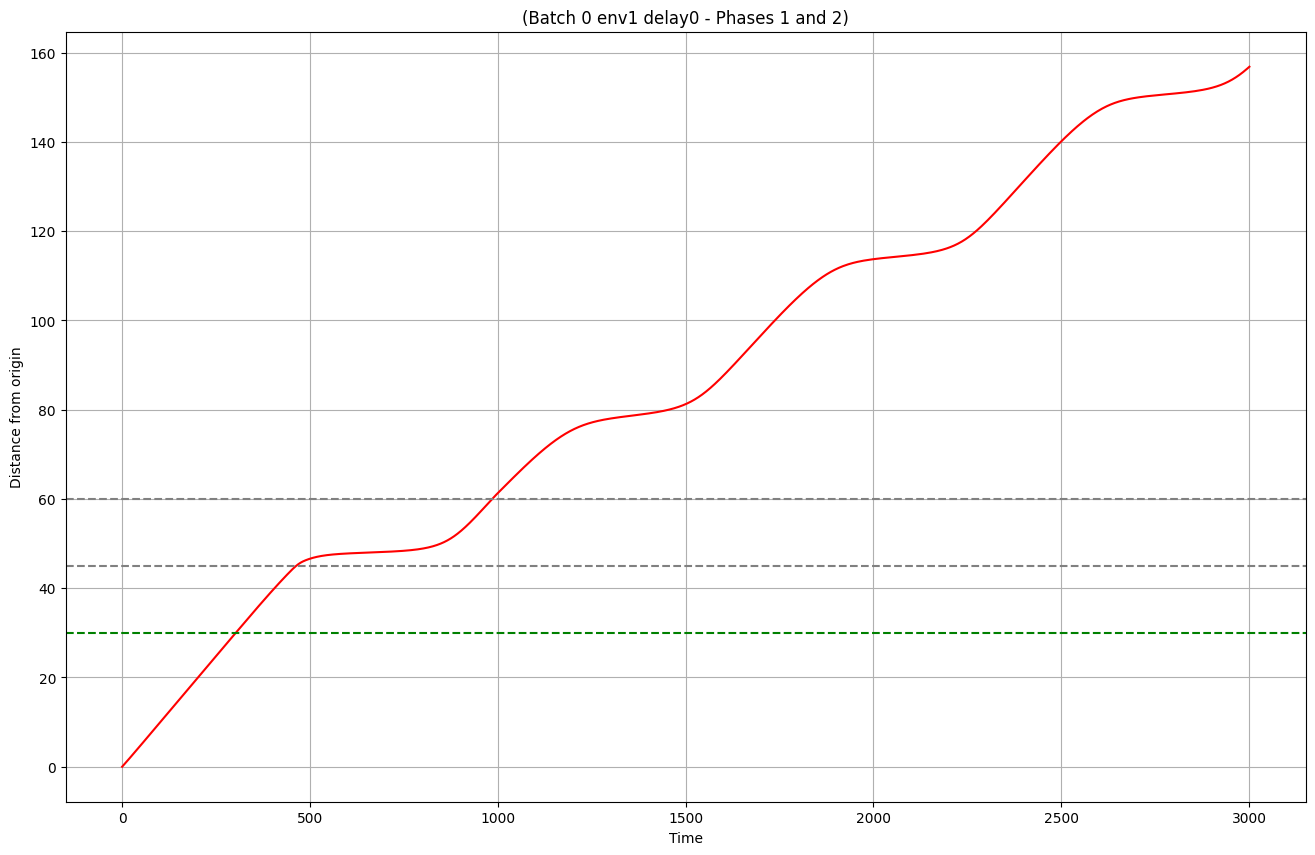

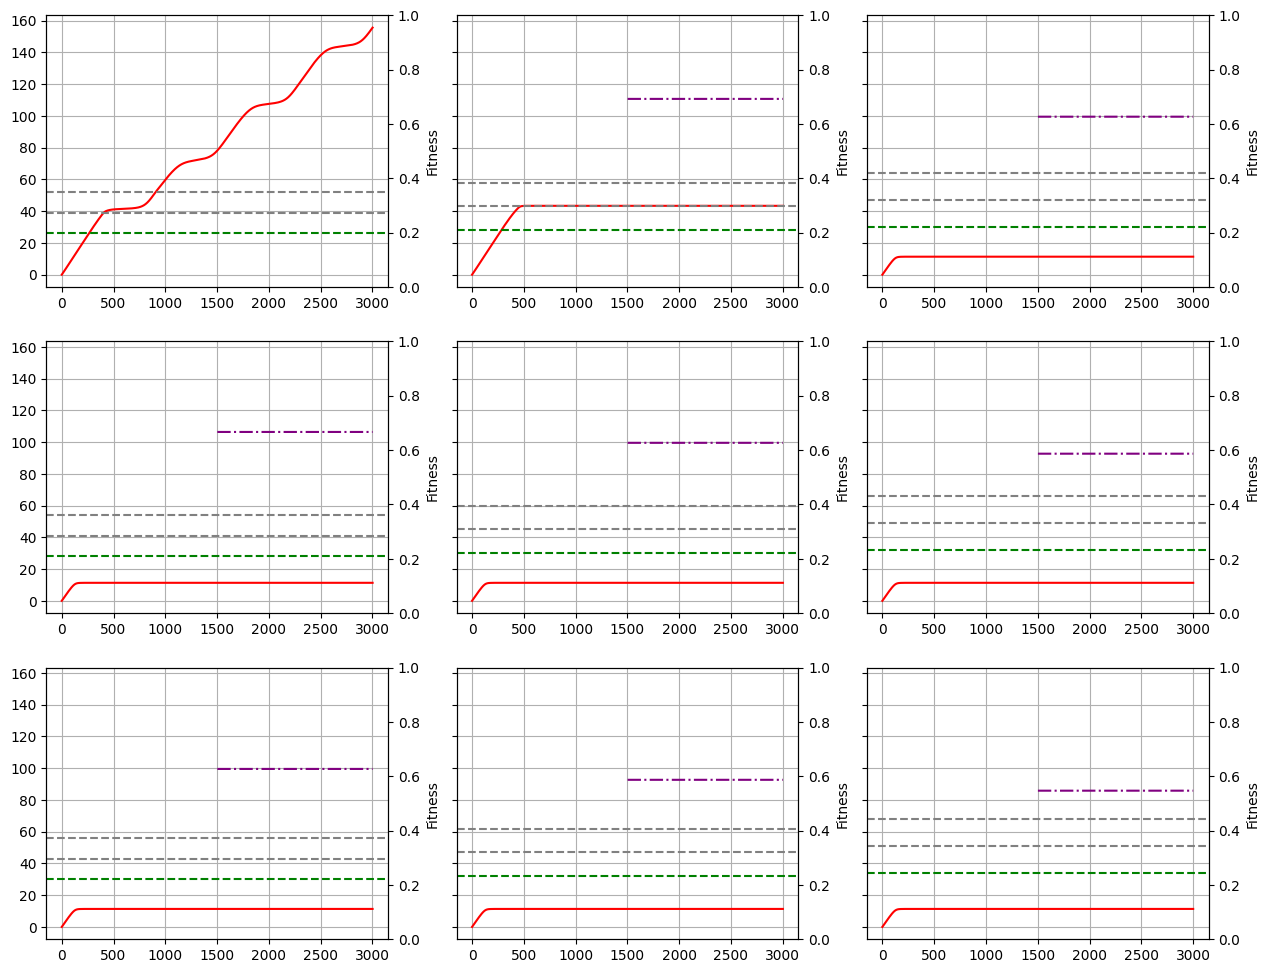

In [ ]:
# training phase + pause behaviour
# this is looking at a single file
# phases = ["Phase1", "Phase2"]
phases = ["Phase3"]

delays = ["delay0"]
envs = ["Env1", "Env2", "Env3"]

run = 0

for batch_index, batch in enumerate(batches):
    for env in envs:
        fig, ax = plt.subplots(figsize=(16,10))
        # first plot phase 1 and phase 2 in the same plot
        phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase1.dat"
        phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase2.dat"
        combined = []
        combined.extend(read_ith_line(1, phase1_dir))
        combined.extend(read_ith_line(1, phase2_dir))
        x = list(range(0, len(combined)))
        ax.plot(x, combined, label=f"Agent", color="red")

        landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_{env}_{delay}_phase2.dat"
        landmark = read_ith_line(1, landmark_file)
        food = landmark[3]
        landmarks = [0,1,2]
        for i in landmarks:
            if (landmark[i] != food):
                ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
        ax.axhline(y=food, linestyle="--", label="Food Position", color="green")

        # plot it
        ax.set_xlabel("Time")
        ax.set_ylabel("Distance from origin")
        ax.set_title(f"(Batch {batch} {env} {delay} - Phases 1 and 2)")
        ax.grid(True)
        fig.show()


        # then plot phase 3 in a 3x3 grid
        fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

        phase3_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase3.dat"
        landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_{env_other}_{delay}_{stage}_phase3.dat"
        fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}_{env_other}_{delay}_{stage}_phase1.dat"

        counter = 1
        for x in range(0, 3):
            for y in range(0,3):
                ax = axes[x, y]
                ax2 = ax.twinx()
                
                # the behaviour
                behaviour = read_ith_line(counter, phase3_dir)
                behaviour_x = list(range(0, len(behaviour)))
                ax.plot(behaviour_x, behaviour, label=f"Agent", color="red")

                # the landmark
                landmark = read_ith_line(counter, landmark_file)
                print(landmark)
                food = landmark[3]
                landmarks = [0,1,2]
                for i in landmarks:
                    if (landmark[i] != food):
                        ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
                ax.axhline(y=food, linestyle="--", label="Food Position", color="green")

                # fitness
                fitness = read_ith_line(counter, fitness_file)
                fitness_start = (len(behaviour) - len(fitness))
                fitness_x = range(fitness_start, len(fitness)+fitness_start)

                ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
                counter += 1

                ax2.set_ylim(bottom=0, top=1)
                ax2.set_ylabel("Fitness")
                ax.grid(True)

                ax.set_title(f"") 
        fig.show()

NameError: name 'receiver' is not defined

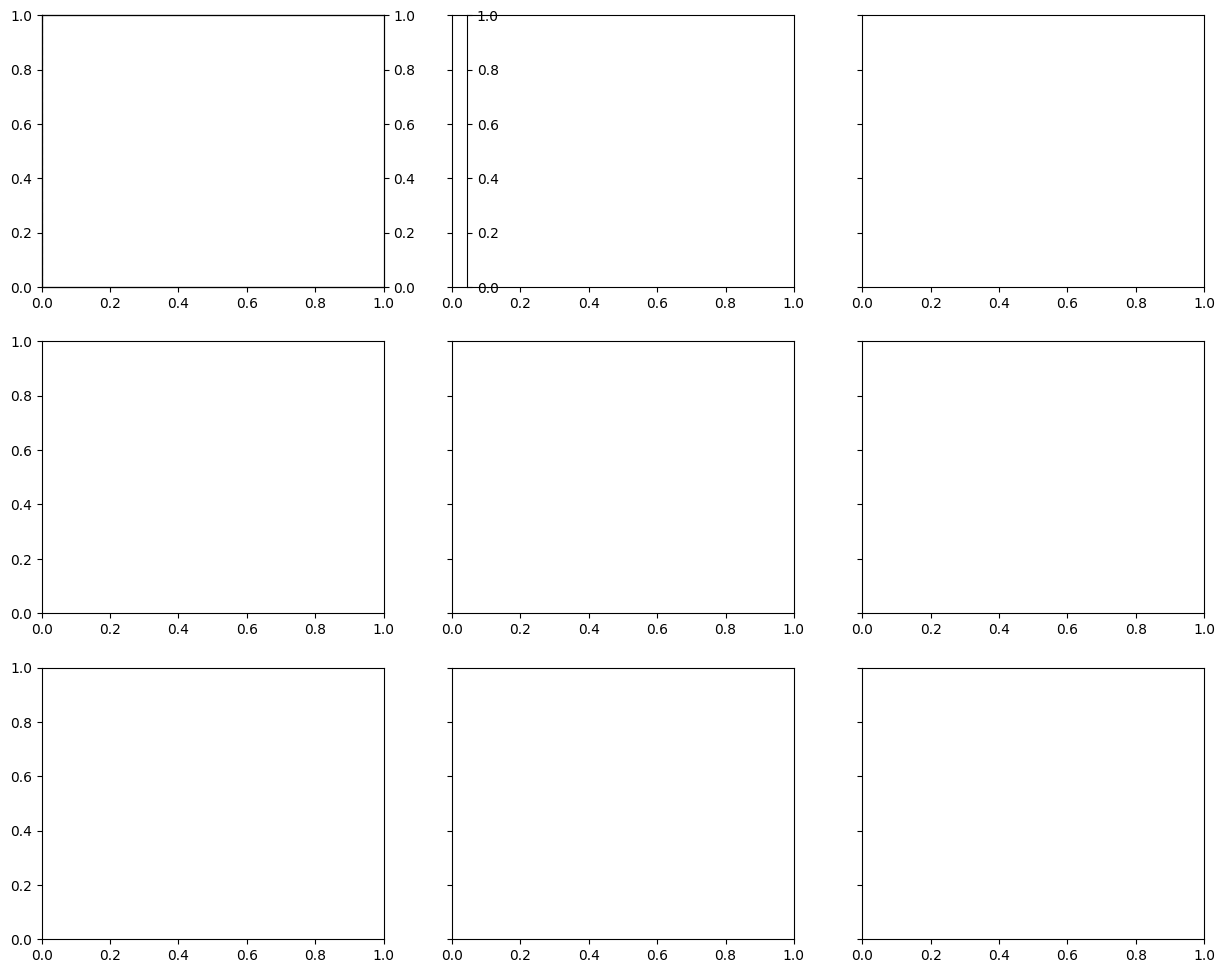

In [ ]:
# this is looking at a single file
phases = ["Phase1", "Phase2", "Phase3"]
delays = ["delay0", "delay5", "delay10"]
envs = ["Env1", "Env2", "Env3"]

run = 0

for batch_index, batch in enumerate(batches):
    fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):
        for delay_index, delay in enumerate(delays):

            ax = axes[env_index, delay_index]

            # fig, ax = plt.subplots(figsize=(16,10))
            ax2 = ax.twinx()
            ax3 = ax.twinx()          # Third y-axis

            # Move third axis further right
            ax3.spines["right"].set_position(("outward", 60))

            # Prevent frame overlap
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)
  
            combined = []

            offset = 0
            for stage in phases:
                # get the agents movements
                phase_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env}_{delay}_{stage}.dat"
                agent = read_ith_line(0, phase_dir)


                ax.axvline(offset, linestyle="--", label=f"{stage}", color="grey")

                

                
                

                # combined_signaller.extend(signaller)
                combined.extend(receiver)

                offset += stage_length


            # make the fitness plot
            fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{stage}_{run}.dat"
            fitness = read_ith_line(trial*env, fitness_file)
            stage_length = len(combined)
            fitness_length = len(fitness)
            fitness_start = offset + (stage_length - fitness_length)
            fitness_end = offset + stage_length
            fitness_x = range(fitness_start, fitness_end)

            ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")



            x = list(range(0, len(combined)))

            # plot the signaller and receiver
            ax.plot(x, combined, label=f"Receiver (Env {env} Trial {trial})", color="red")
            # ax.plot(x, combined_signaller, label=f"Signaller (Env {env} Trial {trial})", color="blue")
            # ax.plot(x, distance, label="Distance", linestyle=":", color="black")

            landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage1_{run}.dat"
            landmark = read_ith_line(trial*env, landmark_file)

            # plot the line marking the landmark position

            food = landmark[3]
            landmarks = [0,1,2]
            for i in landmarks:
                if (landmark[i] != food):
                    ax.axhline(y=landmark[i], linestyle="--", label="food position", color="grey")


            ax.axhline(y=food, linestyle="--", label="food position", color="green")



            # get the neural states
            neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/neuron1_stage1_0.dat"
            neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/neuron2_stage1_0.dat"
            neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/neuron3_stage1_0.dat"
            
            neuron1 = read_ith_line(trial*env, neural_state_1_file)
            neuron2 = read_ith_line(trial*env, neural_state_2_file)
            neuron3 = read_ith_line(trial*env, neural_state_3_file)

            motor = []

            for p in range(len(neuron1)):
                motor.append(neuron2[p]-neuron1[p])


            ax.set_xlabel("Time")
            ax.set_ylabel("Distance from origin")
            ax.set_ylim(bottom=-5, top=50)
            ax2.set_ylim(bottom=0, top=1)
            ax2.set_ylabel("Fitness")

            ax3.set_ylabel("Neuron Values")

            ax.set_title(f"(Batch {batch} Env {env} Trial {trial})")
            ax.grid(True)
            
            fig.tight_layout()
            fig.legend()
            fig.show()